In [1]:
# 1. packages
import os
import json
import time
import numpy as np
import pandas as pd
from openai import OpenAI
from tqdm.notebook import tqdm

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    raise RuntimeError("OPENAI_API_KEY not found. Restart terminal after running setx.")

client = OpenAI(api_key=OPENAI_API_KEY)

RuntimeError: OPENAI_API_KEY not found. Restart terminal after running setx.

In [3]:
# 2. load data
PATH = r"/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/ema_personality_plus_surveys_merged.csv"
df = pd.read_csv(PATH)
df.head()

,start_date,end_date,time_scheduled,duration_seconds,day_of_survey,occasion_within_day,finished,expiwell_id,participant_label,ema_text,...,"weeklyAM__[ start_point_label = 'Less than one day', middle_point_label = 'About one day', end_point_label = 'Several days', ]","weeklyAM__[ start_point_label = 'Not bad', middle_point_label = 'Somewhat bad', end_point_label = 'Very bad', ].1","weeklyAM__[ start_point_label = 'Less than one day', middle_point_label = 'About one day', end_point_label = 'Several days', ].1",weeklyAM__[ 1 = 'Yes' 2 = 'No' 3 = 'NA- first week completing survey' ],weeklyAM__[ 1 = '1 day ago' 2 = '2 days ago' 3 = '3 days ago' 4 = '4 days ago' 5 = '5 days ago' 6 = '6 days ago' 7 = '7 days ago' ],weeklyAM__[ 1 = 'Yes' 2 = 'No' 3 = 'NA- first week completing survey' ].1,weeklyAM__[ 1 = '1 day ago' 2 = '2 days ago' 3 = '3 days ago' 4 = '4 days ago' 5 = '5 days ago' 6 = '6 days ago' 7 = '7 days ago' ].1,weeklyAM__Unnamed: 66,weeklyAM_dt,weeklyAM_date
0,08/07/2024 07:17PM,08/07/2024 07:19PM,08/07/2024 09:00AM - 08/07/2024 11:59PM,121.809,2,1,Finished,64f18f0c9f8496d6156d6624,Participant 138,NONE,...,20.0,72.0,73.0,3.0,NaN,3.0,NaN,NaN,2024-08-07 09:00:00,2024-08-07
1,08/08/2024 06:58PM,08/08/2024 07:14PM,08/08/2024 06:00PM - 08/08/2024 08:59PM,995.235,3,1,Finished,64f18f0c9f8496d6156d6624,Participant 138,I have been feeling so down that nothing could...,...,20.0,72.0,73.0,3.0,NaN,3.0,NaN,NaN,2024-08-07 09:00:00,2024-08-07
2,08/09/2024 06:26PM,08/09/2024 06:36PM,08/09/2024 06:00PM - 08/09/2024 08:59PM,591.661,4,1,Finished,64f18f0c9f8496d6156d6624,Participant 138,I don’t have-any feelings at all,...,20.0,72.0,73.0,3.0,NaN,3.0,NaN,NaN,2024-08-07 09:00:00,2024-08-07
3,08/10/2024 06:25PM,08/10/2024 06:27PM,08/10/2024 06:00PM - 08/10/2024 08:59PM,114.919,5,1,Finished,64f18f0c9f8496d6156d6624,Participant 138,My emotions are everywhere and it is frustrating,...,20.0,72.0,73.0,3.0,NaN,3.0,NaN,NaN,2024-08-07 09:00:00,2024-08-07
4,08/11/2024 07:15PM,08/11/2024 07:18PM,08/11/2024 06:00PM - 08/11/2024 08:59PM,185.797,6,1,Finished,64f18f0c9f8496d6156d6624,Participant 138,Well today has been a little positive and I ha...,...,20.0,72.0,73.0,3.0,NaN,3.0,NaN,NaN,2024-08-07 09:00:00,2024-08-07


In [7]:
import os
import re
import json
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [9]:
# 0) CONFIG
# ----------------------------
DATA_PATH = r"/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/ema_personality_plus_surveys_merged.csv"

OUT_DIR = os.path.join(os.path.dirname(DATA_PATH), "outputs_nlp_crisis")
os.makedirs(OUT_DIR, exist_ok=True)

# Text embedding model
# If you don't have it:
#   pip install -U sentence-transformers
EMBED_MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"  # strong default
EMBED_CACHE_PATH = os.path.join(OUT_DIR, "day_text_embeddings.npy")
DAY_LEVEL_PATH = os.path.join(OUT_DIR, "day_level_dataset.parquet")

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

In [11]:
# 1) LOAD + BASIC CLEANING
# ----------------------------
df = pd.read_csv(DATA_PATH)

# Required columns (these exist in your merged file)
PID_COL = "expiwell_id_clean" if "expiwell_id_clean" in df.columns else "expiwell_id"
TEXT_COL = "ema_text"
DT_COL = "ema_dt" if "ema_dt" in df.columns else "start_date"
DATE_COL = "ema_date" if "ema_date" in df.columns else None

# Parse datetime + date
df[DT_COL] = pd.to_datetime(df[DT_COL], errors="coerce")
if DATE_COL is None:
    df["ema_date"] = df[DT_COL].dt.date
    DATE_COL = "ema_date"
else:
    # ensure it's date (not string)
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce").dt.date

# Basic QC
assert PID_COL in df.columns, f"Missing {PID_COL}"
assert TEXT_COL in df.columns, f"Missing {TEXT_COL}"

print("Loaded:", df.shape)
print("Participants:", df[PID_COL].nunique(dropna=True))
print("Non-missing text rows:", df[TEXT_COL].notna().mean().round(3))

Loaded: (2742, 200)
Participants: 123
Non-missing text rows: 1.0


In [13]:
# 2) AUTO-IDENTIFY "CRISIS 5 ITEMS" IN DAILY AM/PM
#    (the 5 0–4 items that best correlate with Total Score from 5 Questions)
# ----------------------------
def find_crisis_item_cols(df, prefix: str, total_col: str, top_k: int = 5):
    """
    Finds candidate item columns under prefix that:
      - are numeric
      - mostly integer-like
      - have min>=0 and max<=4
      - have 5 unique values (0..4 usually)
    then ranks by |corr(item, total)| and returns top_k.
    """
    cols = [c for c in df.columns if c.startswith(prefix) and pd.api.types.is_numeric_dtype(df[c])]
    candidates = []
    for c in cols:
        if c == total_col:
            continue
        s = df[c].dropna()
        if len(s) < 50:
            continue
        mn, mx = s.min(), s.max()
        if mn >= 0 and mx <= 4:
            frac_nonint = np.mean(np.abs(s - np.round(s)) > 1e-6)
            if frac_nonint < 0.01 and s.nunique() == 5:
                # compute correlation with total (pairwise)
                tmp = df[[c, total_col]].dropna()
                if len(tmp) < 100:
                    continue
                corr = tmp.corr().iloc[0, 1]
                candidates.append((c, float(corr), int(len(tmp))))
    candidates = sorted(candidates, key=lambda x: -abs(x[1]))
    return candidates[:top_k]

AM_TOTAL = "dailyAM__Total Score from 5 Questions"
PM_TOTAL = "dailyPM__Total Score from 5 Questions"

am_items = find_crisis_item_cols(df, "dailyAM__", AM_TOTAL, top_k=5)
pm_items = find_crisis_item_cols(df, "dailyPM__", PM_TOTAL, top_k=5)

print("\nIdentified AM crisis items (top 5 by corr with AM total):")
for c, corr, n in am_items:
    print(f"  corr={corr:.3f}  n={n:4d}  col={c[:95]}{'...' if len(c)>95 else ''}")

print("\nIdentified PM crisis items (top 5 by corr with PM total):")
for c, corr, n in pm_items:
    print(f"  corr={corr:.3f}  n={n:4d}  col={c[:95]}{'...' if len(c)>95 else ''}")

CRISIS_AM_COLS = [c for c,_,_ in am_items]
CRISIS_PM_COLS = [c for c,_,_ in pm_items]

# Create computed totals (sanity check against provided totals)
df["crisis_AM_sum_from_items"] = df[CRISIS_AM_COLS].sum(axis=1, min_count=1)
df["crisis_PM_sum_from_items"] = df[CRISIS_PM_COLS].sum(axis=1, min_count=1)

# Compare with provided totals (they should match almost perfectly)
am_match = (df[[AM_TOTAL, "crisis_AM_sum_from_items"]].dropna()
            .assign(diff=lambda x: x[AM_TOTAL] - x["crisis_AM_sum_from_items"])["diff"])
pm_match = (df[[PM_TOTAL, "crisis_PM_sum_from_items"]].dropna()
            .assign(diff=lambda x: x[PM_TOTAL] - x["crisis_PM_sum_from_items"])["diff"])

print("\nSanity check: Provided total vs sum(items)")
print("  AM: mean diff =", am_match.mean().round(4), "| %exact match =", (am_match==0).mean().round(4))
print("  PM: mean diff =", pm_match.mean().round(4), "| %exact match =", (pm_match==0).mean().round(4))

# We'll use the provided totals as primary outcomes (simple + matches instrument scoring)
df["crisis_AM"] = df[AM_TOTAL]
df["crisis_PM"] = df[PM_TOTAL]



Identified AM crisis items (top 5 by corr with AM total):
  corr=0.938  n=2081  col=dailyAM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely'0 = 'Not...
  corr=0.936  n=2081  col=dailyAM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely'0 = 'Not...
  corr=0.931  n=2081  col=dailyAM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely' ]
  corr=0.930  n=2081  col=dailyAM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely'0 = 'Not...
  corr=0.912  n=2080  col=dailyAM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely'0 = 'Not...

Identified PM crisis items (top 5 by corr with PM total):
  corr=0.938  n=2737  col=dailyPM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely'0 = 'Not...
  corr=0.938  n=2738  col=dailyPM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely' ]
  corr=0.931  n=2738  col

In [15]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

# ---------- CONFIG ----------
PATH = r"/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/ema_personality_plus_surveys_merged.csv"
OUT_DIR = os.path.join(os.path.dirname(PATH), "outputs_step3_incremental")
os.makedirs(OUT_DIR, exist_ok=True)

EMBED_MODEL = "sentence-transformers/all-mpnet-base-v2"  # strong default
EMBED_CACHE = os.path.join(OUT_DIR, "day_text_embeddings.npy")

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

# ---------- LOAD ----------
df = pd.read_csv(PATH)

PID_COL  = "expiwell_id_clean" if "expiwell_id_clean" in df.columns else "expiwell_id"
TEXT_COL = "ema_text"
DT_COL   = "ema_dt" if "ema_dt" in df.columns else "start_date"

AM_TOTAL = "dailyAM__Total Score from 5 Questions"
PM_TOTAL = "dailyPM__Total Score from 5 Questions"

# Parse datetime + date
df[DT_COL] = pd.to_datetime(df[DT_COL], errors="coerce")
df["ema_date"] = df[DT_COL].dt.date

# Crisis totals (5-item total already computed by Expiwell export)
df["crisis_AM"] = df[AM_TOTAL]
df["crisis_PM"] = df[PM_TOTAL]

def first_nonnull(x):
    x = x.dropna()
    return x.iloc[0] if len(x) else np.nan

# ---------- BUILD PERSON-DAY TABLE ----------
day = (df.sort_values([PID_COL, DT_COL])
         .groupby([PID_COL, "ema_date"], as_index=False)
         .agg(
             day_text=(TEXT_COL, lambda s: " ".join([str(t) for t in s.dropna()])),
             n_text_prompts=(TEXT_COL, lambda s: int(s.notna().sum())),
             crisis_AM=("crisis_AM", first_nonnull),
             crisis_PM=("crisis_PM", first_nonnull),
         ))

day["has_text"] = day["day_text"].astype(str).str.strip().ne("")
day = day.loc[day["has_text"]].reset_index(drop=True)

# Sort for lagging
day = day.sort_values([PID_COL, "ema_date"]).reset_index(drop=True)
day["crisis_PM_next"] = day.groupby(PID_COL)["crisis_PM"].shift(-1)

# Keep rows with outcome and baseline available
mask = day["crisis_PM"].notna() & day["crisis_PM_next"].notna()
day_m = day.loc[mask].reset_index(drop=True)

y = day_m["crisis_PM_next"].values.astype(float)                 # outcome: next-day PM crisis
x_base = day_m["crisis_PM"].values.astype(float).reshape(-1, 1)  # baseline: current-day PM crisis
groups = day_m[PID_COL].astype(str).values

print("Day rows (with text):", len(day))
print("Usable lag rows:", len(day_m))
print("Participants:", day_m[PID_COL].nunique(dropna=True))

# ---------- EMBEDDINGS ----------
# pip install -U sentence-transformers  (if needed)
if os.path.exists(EMBED_CACHE):
    X_text_all = np.load(EMBED_CACHE)
    # Safety check: cache must match current day rows
    if X_text_all.shape[0] != len(day):
        raise ValueError(
            f"Embedding cache rows ({X_text_all.shape[0]}) != day rows ({len(day)}). "
            f"Delete cache file: {EMBED_CACHE} and rerun."
        )
else:
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(EMBED_MODEL)
    X_text_all = model.encode(
        day["day_text"].tolist(),
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True
    )
    np.save(EMBED_CACHE, X_text_all)

# Align embeddings to the lagged subset
X_text = X_text_all[mask.values, :]

# ---------- CV HELPERS ----------
def grouped_cv_regression(X, y, groups, model, n_splits=5, label=""):
    gkf = GroupKFold(n_splits=n_splits)
    maes, rmses, r2s = [], [], []
    for fold, (tr, te) in enumerate(gkf.split(X, y, groups=groups), start=1):
        model.fit(X[tr], y[tr])
        yhat = model.predict(X[te])
        maes.append(mean_absolute_error(y[te], yhat))
        rmses.append(mean_squared_error(y[te], yhat, squared=False))
        r2s.append(r2_score(y[te], yhat))
        print(f"{label} fold {fold}: MAE={maes[-1]:.3f} RMSE={rmses[-1]:.3f} R2={r2s[-1]:.3f}")
    return {
        "MAE_mean": float(np.mean(maes)),
        "RMSE_mean": float(np.mean(rmses)),
        "R2_mean": float(np.mean(r2s)),
        "MAE_sd": float(np.std(maes)),
        "RMSE_sd": float(np.std(rmses)),
        "R2_sd": float(np.std(r2s)),
    }

class TextPlusNumericRidge:
    """PCA on text embeddings + ridge on [numeric_baseline, text_PCs]."""
    def __init__(self, n_pcs=20, alpha=10.0):
        self.pca = PCA(n_components=n_pcs, random_state=RANDOM_SEED)
        self.scaler = StandardScaler()
        self.ridge = Ridge(alpha=alpha, random_state=RANDOM_SEED)

    def fit(self, X_text, X_num, y):
        Z = self.pca.fit_transform(X_text)
        X = np.hstack([X_num, Z])
        Xs = self.scaler.fit_transform(X)
        self.ridge.fit(Xs, y)
        return self

    def predict(self, X_text, X_num):
        Z = self.pca.transform(X_text)
        X = np.hstack([X_num, Z])
        Xs = self.scaler.transform(X)
        return self.ridge.predict(Xs)

def grouped_cv_text_plus_numeric(X_text, X_num, y, groups, n_splits=5, label=""):
    gkf = GroupKFold(n_splits=n_splits)
    maes, rmses, r2s = [], [], []
    for fold, (tr, te) in enumerate(gkf.split(X_text, y, groups=groups), start=1):
        model = TextPlusNumericRidge(n_pcs=20, alpha=10.0)
        model.fit(X_text[tr], X_num[tr], y[tr])
        yhat = model.predict(X_text[te], X_num[te])
        maes.append(mean_absolute_error(y[te], yhat))
        rmses.append(mean_squared_error(y[te], yhat, squared=False))
        r2s.append(r2_score(y[te], yhat))
        print(f"{label} fold {fold}: MAE={maes[-1]:.3f} RMSE={rmses[-1]:.3f} R2={r2s[-1]:.3f}")
    return {
        "MAE_mean": float(np.mean(maes)),
        "RMSE_mean": float(np.mean(rmses)),
        "R2_mean": float(np.mean(r2s)),
        "MAE_sd": float(np.std(maes)),
        "RMSE_sd": float(np.std(rmses)),
        "R2_sd": float(np.std(r2s)),
    }

# ---------- MODELS ----------
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0, random_state=RANDOM_SEED))
])

print("\n=== #3A Incremental (PM -> next PM) ===")
res_base = grouped_cv_regression(x_base, y, groups, baseline_model, n_splits=5, label="Baseline: crisis_PM_t")
res_full = grouped_cv_text_plus_numeric(X_text, x_base, y, groups, n_splits=5, label="+Text: crisis_PM_t + embedding")

delta = {
    "Delta_MAE": res_base["MAE_mean"] - res_full["MAE_mean"],
    "Delta_RMSE": res_base["RMSE_mean"] - res_full["RMSE_mean"],
    "Delta_R2": res_full["R2_mean"] - res_base["R2_mean"],
}

print("\nBaseline summary:", res_base)
print("Full(+text) summary:", res_full)
print("Incremental gain (+text over baseline):", delta)

# Save outputs
pd.DataFrame([{"model":"baseline", **res_base}, {"model":"full_text", **res_full}, {"model":"delta", **delta}]).to_csv(
    os.path.join(OUT_DIR, "step3_incremental_results.csv"), index=False
)
day_m.to_csv(os.path.join(OUT_DIR, "step3_day_level_lagged_data.csv"), index=False)
print("\nSaved results to:", OUT_DIR)


Day rows (with text): 2734
Usable lag rows: 2603
Participants: 123


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/43 [00:00<?, ?it/s]


=== #3A Incremental (PM -> next PM) ===
Baseline: crisis_PM_t fold 1: MAE=3.227 RMSE=4.462 R2=0.479
Baseline: crisis_PM_t fold 2: MAE=3.132 RMSE=4.216 R2=0.588
Baseline: crisis_PM_t fold 3: MAE=3.127 RMSE=4.695 R2=0.318
Baseline: crisis_PM_t fold 4: MAE=3.104 RMSE=4.364 R2=0.429
Baseline: crisis_PM_t fold 5: MAE=3.509 RMSE=5.218 R2=0.329
+Text: crisis_PM_t + embedding fold 1: MAE=3.287 RMSE=4.474 R2=0.476


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use 

+Text: crisis_PM_t + embedding fold 2: MAE=3.263 RMSE=4.305 R2=0.571
+Text: crisis_PM_t + embedding fold 3: MAE=3.143 RMSE=4.708 R2=0.315
+Text: crisis_PM_t + embedding fold 4: MAE=3.203 RMSE=4.429 R2=0.412
+Text: crisis_PM_t + embedding fold 5: MAE=3.513 RMSE=5.221 R2=0.328

Baseline summary: {'MAE_mean': 3.219670991135588, 'RMSE_mean': 4.591078056814615, 'R2_mean': 0.428793557831607, 'MAE_sd': 0.15051146730951614, 'RMSE_sd': 0.35015815395424, 'R2_sd': 0.10012840553378985}
Full(+text) summary: {'MAE_mean': 3.281791962082541, 'RMSE_mean': 4.627457834933874, 'R2_mean': 0.42039166094778624, 'MAE_sd': 0.1257664169255387, 'RMSE_sd': 0.3242657513862337, 'R2_sd': 0.09535380855035282}
Incremental gain (+text over baseline): {'Delta_MAE': -0.06212097094695279, 'Delta_RMSE': -0.036379778119258965, 'Delta_R2': -0.008401896883820759}

Saved results to: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_step3_incremental


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [17]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

PATH = r"/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/ema_personality_plus_surveys_merged.csv"
OUT_DIR = os.path.join(os.path.dirname(PATH), "outputs_step3B_AM_to_PM_incremental")
os.makedirs(OUT_DIR, exist_ok=True)

EMBED_MODEL = "sentence-transformers/all-mpnet-base-v2"
EMBED_CACHE = os.path.join(OUT_DIR, "day_text_embeddings.npy")
RANDOM_SEED = 7

df = pd.read_csv(PATH)

PID_COL  = "expiwell_id_clean" if "expiwell_id_clean" in df.columns else "expiwell_id"
TEXT_COL = "ema_text"
DT_COL   = "ema_dt" if "ema_dt" in df.columns else "start_date"

AM_TOTAL = "dailyAM__Total Score from 5 Questions"
PM_TOTAL = "dailyPM__Total Score from 5 Questions"

df[DT_COL] = pd.to_datetime(df[DT_COL], errors="coerce")
df["ema_date"] = df[DT_COL].dt.date
df["crisis_AM"] = df[AM_TOTAL]
df["crisis_PM"] = df[PM_TOTAL]

def first_nonnull(x):
    x = x.dropna()
    return x.iloc[0] if len(x) else np.nan

day = (df.sort_values([PID_COL, DT_COL])
         .groupby([PID_COL, "ema_date"], as_index=False)
         .agg(
             day_text=(TEXT_COL, lambda s: " ".join([str(t) for t in s.dropna()])),
             n_text_prompts=(TEXT_COL, lambda s: int(s.notna().sum())),
             crisis_AM=("crisis_AM", first_nonnull),
             crisis_PM=("crisis_PM", first_nonnull),
         ))

day["has_text"] = day["day_text"].astype(str).str.strip().ne("")
day = day.loc[day["has_text"]].reset_index(drop=True)

# Keep days with both AM and PM
mask = day["crisis_AM"].notna() & day["crisis_PM"].notna()
day_m = day.loc[mask].reset_index(drop=True)

y = day_m["crisis_PM"].values.astype(float)                  # outcome: PM same-day crisis
x_base = day_m["crisis_AM"].values.astype(float).reshape(-1,1)  # baseline: AM crisis
groups = day_m[PID_COL].astype(str).values

print("Usable same-day rows:", len(day_m))
print("Participants:", day_m[PID_COL].nunique(dropna=True))

# Embeddings (cache)
if os.path.exists(EMBED_CACHE):
    X_text_all = np.load(EMBED_CACHE)
    if X_text_all.shape[0] != len(day):
        raise ValueError(f"Cache mismatch. Delete {EMBED_CACHE} and rerun.")
else:
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(EMBED_MODEL)
    X_text_all = model.encode(
        day["day_text"].tolist(),
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True
    )
    np.save(EMBED_CACHE, X_text_all)

X_text = X_text_all[mask.values, :]

def grouped_cv_regression(X, y, groups, model, n_splits=5, label=""):
    gkf = GroupKFold(n_splits=n_splits)
    maes, rmses, r2s = [], [], []
    for fold, (tr, te) in enumerate(gkf.split(X, y, groups=groups), start=1):
        model.fit(X[tr], y[tr])
        yhat = model.predict(X[te])
        maes.append(mean_absolute_error(y[te], yhat))
        rmses.append(mean_squared_error(y[te], yhat, squared=False))
        r2s.append(r2_score(y[te], yhat))
        print(f"{label} fold {fold}: MAE={maes[-1]:.3f} RMSE={rmses[-1]:.3f} R2={r2s[-1]:.3f}")
    return {
        "MAE_mean": float(np.mean(maes)),
        "RMSE_mean": float(np.mean(rmses)),
        "R2_mean": float(np.mean(r2s)),
        "MAE_sd": float(np.std(maes)),
        "RMSE_sd": float(np.std(rmses)),
        "R2_sd": float(np.std(r2s)),
    }

class TextPlusNumericRidge:
    def __init__(self, n_pcs=20, alpha=10.0):
        self.pca = PCA(n_components=n_pcs, random_state=RANDOM_SEED)
        self.scaler = StandardScaler()
        self.ridge = Ridge(alpha=alpha, random_state=RANDOM_SEED)
    def fit(self, X_text, X_num, y):
        Z = self.pca.fit_transform(X_text)
        X = np.hstack([X_num, Z])
        Xs = self.scaler.fit_transform(X)
        self.ridge.fit(Xs, y)
        return self
    def predict(self, X_text, X_num):
        Z = self.pca.transform(X_text)
        X = np.hstack([X_num, Z])
        Xs = self.scaler.transform(X)
        return self.ridge.predict(Xs)

def grouped_cv_text_plus_numeric(X_text, X_num, y, groups, n_splits=5, label=""):
    gkf = GroupKFold(n_splits=n_splits)
    maes, rmses, r2s = [], [], []
    for fold, (tr, te) in enumerate(gkf.split(X_text, y, groups=groups), start=1):
        model = TextPlusNumericRidge(n_pcs=20, alpha=10.0)
        model.fit(X_text[tr], X_num[tr], y[tr])
        yhat = model.predict(X_text[te], X_num[te])
        maes.append(mean_absolute_error(y[te], yhat))
        rmses.append(mean_squared_error(y[te], yhat, squared=False))
        r2s.append(r2_score(y[te], yhat))
        print(f"{label} fold {fold}: MAE={maes[-1]:.3f} RMSE={rmses[-1]:.3f} R2={r2s[-1]:.3f}")
    return {
        "MAE_mean": float(np.mean(maes)),
        "RMSE_mean": float(np.mean(rmses)),
        "R2_mean": float(np.mean(r2s)),
        "MAE_sd": float(np.std(maes)),
        "RMSE_sd": float(np.std(rmses)),
        "R2_sd": float(np.std(r2s)),
    }

baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0, random_state=RANDOM_SEED))
])

print("\n=== #3B Incremental (AM -> PM same day) ===")
res_base = grouped_cv_regression(x_base, y, groups, baseline_model, n_splits=5, label="Baseline: crisis_AM")
res_full = grouped_cv_text_plus_numeric(X_text, x_base, y, groups, n_splits=5, label="+Text")

delta = {
    "Delta_MAE": res_base["MAE_mean"] - res_full["MAE_mean"],
    "Delta_RMSE": res_base["RMSE_mean"] - res_full["RMSE_mean"],
    "Delta_R2": res_full["R2_mean"] - res_base["R2_mean"],
}

print("\nBaseline summary:", res_base)
print("Full(+text) summary:", res_full)
print("Incremental gain (+text over baseline):", delta)


Usable same-day rows: 2073
Participants: 122


Batches:   0%|          | 0/43 [00:00<?, ?it/s]


=== #3B Incremental (AM -> PM same day) ===
Baseline: crisis_AM fold 1: MAE=3.163 RMSE=4.722 R2=0.413
Baseline: crisis_AM fold 2: MAE=3.142 RMSE=4.453 R2=0.562
Baseline: crisis_AM fold 3: MAE=2.945 RMSE=4.244 R2=0.518
Baseline: crisis_AM fold 4: MAE=3.088 RMSE=4.456 R2=0.437
Baseline: crisis_AM fold 5: MAE=3.301 RMSE=4.823 R2=0.324
+Text fold 1: MAE=3.270 RMSE=4.310 R2=0.511
+Text fold 2: MAE=2.704 RMSE=3.876 R2=0.668
+Text fold 3: MAE=2.797 RMSE=3.888 R2=0.595


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use 

+Text fold 4: MAE=2.948 RMSE=4.018 R2=0.542
+Text fold 5: MAE=3.005 RMSE=4.334 R2=0.454

Baseline summary: {'MAE_mean': 3.1278827037420056, 'RMSE_mean': 4.539614090036695, 'R2_mean': 0.45062656443877447, 'MAE_sd': 0.11535520926547185, 'RMSE_sd': 0.20727291744622545, 'R2_sd': 0.08304532891021646}
Full(+text) summary: {'MAE_mean': 2.9448316276676993, 'RMSE_mean': 4.08506881938478, 'R2_mean': 0.5540710878183182, 'MAE_sd': 0.19421873744589646, 'RMSE_sd': 0.2001139211643811, 'R2_sd': 0.07312324966610365}
Incremental gain (+text over baseline): {'Delta_MAE': 0.18305107607430626, 'Delta_RMSE': 0.45454527065191463, 'Delta_R2': 0.10344452337954368}


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [21]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

# ---------- CONFIG ----------
PATH = r"/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/ema_personality_plus_surveys_merged.csv"
OUT_DIR = os.path.join(os.path.dirname(PATH), "outputs_step3C_AM_to_PM_other_ratings")
os.makedirs(OUT_DIR, exist_ok=True)

EMBED_MODEL = "sentence-transformers/all-mpnet-base-v2"
EMBED_CACHE = os.path.join(OUT_DIR, "day_text_embeddings.npy")
RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

# ---------- LOAD ----------
df = pd.read_csv(PATH)

PID_COL  = "expiwell_id_clean" if "expiwell_id_clean" in df.columns else "expiwell_id"
TEXT_COL = "ema_text"
DT_COL   = "ema_dt" if "ema_dt" in df.columns else "start_date"

AM_TOTAL = "dailyAM__Total Score from 5 Questions"
PM_TOTAL = "dailyPM__Total Score from 5 Questions"

df[DT_COL] = pd.to_datetime(df[DT_COL], errors="coerce")
df["ema_date"] = df[DT_COL].dt.date

df["crisis_AM"] = df[AM_TOTAL]
df["crisis_PM"] = df[PM_TOTAL]

def first_nonnull(x):
    x = x.dropna()
    return x.iloc[0] if len(x) else np.nan

# ---------- IDENTIFY THE 5 CRISIS ITEMS (TO EXCLUDE) ----------
def find_crisis_item_cols(df, prefix: str, total_col: str, top_k: int = 5):
    cols = [c for c in df.columns if c.startswith(prefix) and pd.api.types.is_numeric_dtype(df[c])]
    candidates = []
    for c in cols:
        if c == total_col:
            continue
        s = df[c].dropna()
        if len(s) < 50:
            continue
        mn, mx = s.min(), s.max()
        if mn >= 0 and mx <= 4:
            frac_nonint = np.mean(np.abs(s - np.round(s)) > 1e-6)
            if frac_nonint < 0.01 and s.nunique() == 5:
                tmp = df[[c, total_col]].dropna()
                if len(tmp) < 100:
                    continue
                corr = tmp.corr().iloc[0, 1]
                candidates.append((c, float(corr), int(len(tmp))))
    candidates = sorted(candidates, key=lambda x: -abs(x[1]))
    return [c for c,_,_ in candidates[:top_k]]

CRISIS_AM_COLS = find_crisis_item_cols(df, "dailyAM__", AM_TOTAL, top_k=5)

print("\nCrisis AM item columns being excluded from 'other ratings':")
for c in CRISIS_AM_COLS:
    print("  ", c[:120] + ("..." if len(c) > 120 else ""))

# ---------- BUILD LIST OF "OTHER AM RATINGS" ----------
dailyAM_numeric = [
    c for c in df.columns
    if c.startswith("dailyAM__")
    and pd.api.types.is_numeric_dtype(df[c])
]

EXCLUDE = set([AM_TOTAL] + CRISIS_AM_COLS)
OTHER_AM_COLS = [c for c in dailyAM_numeric if c not in EXCLUDE]
print("\nOther AM numeric covariates included:", len(OTHER_AM_COLS))

# ---------- BUILD PERSON-DAY TABLE (FIXED agg SYNTAX) ----------
agg_dict = {
    "day_text": (TEXT_COL, lambda s: " ".join([str(t) for t in s.dropna()])),
    "n_text_prompts": (TEXT_COL, lambda s: int(s.notna().sum())),
    "crisis_AM": ("crisis_AM", first_nonnull),
    "crisis_PM": ("crisis_PM", first_nonnull),
}
# add other AM covariates in the *named-agg* format
for c in OTHER_AM_COLS:
    agg_dict[c] = (c, first_nonnull)

day = (df.sort_values([PID_COL, DT_COL])
         .groupby([PID_COL, "ema_date"], as_index=False)
         .agg(**agg_dict))

day["has_text"] = day["day_text"].astype(str).str.strip().ne("")
day = day.loc[day["has_text"]].reset_index(drop=True)

# Keep days with AM + PM available
mask = day["crisis_AM"].notna() & day["crisis_PM"].notna()
day_m = day.loc[mask].reset_index(drop=True)

print("\nUsable same-day rows:", len(day_m))
print("Participants:", day_m[PID_COL].nunique(dropna=True))

# ---------- BUILD BASELINE X (crisis_AM + other AM ratings) ----------
X_num = day_m[["crisis_AM"] + OTHER_AM_COLS].copy()
X_num = X_num.dropna(axis=1, how="all")
X_num = X_num.fillna(X_num.mean(numeric_only=True))
X_num = X_num.values.astype(float)

y = day_m["crisis_PM"].values.astype(float)
groups = day_m[PID_COL].astype(str).values
print("Numeric baseline covariates used:", X_num.shape[1])

# ---------- EMBEDDINGS (CACHE) ----------
# embeddings align to day rows (before masking)
if os.path.exists(EMBED_CACHE):
    X_text_all = np.load(EMBED_CACHE)
    if X_text_all.shape[0] != len(day):
        raise ValueError(
            f"Embedding cache rows ({X_text_all.shape[0]}) != day rows ({len(day)}). "
            f"Delete cache file and rerun: {EMBED_CACHE}"
        )
else:
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(EMBED_MODEL)
    X_text_all = model.encode(
        day["day_text"].tolist(),
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True
    )
    np.save(EMBED_CACHE, X_text_all)

# subset embeddings to analytic rows
X_text = X_text_all[mask.values, :]

# ---------- CV HELPERS ----------
def grouped_cv_regression(X, y, groups, model, n_splits=5, label=""):
    gkf = GroupKFold(n_splits=n_splits)
    maes, rmses, r2s = [], [], []
    for fold, (tr, te) in enumerate(gkf.split(X, y, groups=groups), start=1):
        model.fit(X[tr], y[tr])
        yhat = model.predict(X[te])
        maes.append(mean_absolute_error(y[te], yhat))
        rmses.append(mean_squared_error(y[te], yhat, squared=False))
        r2s.append(r2_score(y[te], yhat))
        print(f"{label} fold {fold}: MAE={maes[-1]:.3f} RMSE={rmses[-1]:.3f} R2={r2s[-1]:.3f}")
    return {
        "MAE_mean": float(np.mean(maes)),
        "RMSE_mean": float(np.mean(rmses)),
        "R2_mean": float(np.mean(r2s)),
        "MAE_sd": float(np.std(maes)),
        "RMSE_sd": float(np.std(rmses)),
        "R2_sd": float(np.std(r2s)),
    }

class TextPlusNumericRidge:
    def __init__(self, n_pcs=20, alpha=10.0):
        self.pca = PCA(n_components=n_pcs, random_state=RANDOM_SEED)
        self.scaler = StandardScaler()
        self.ridge = Ridge(alpha=alpha, random_state=RANDOM_SEED)
    def fit(self, X_text, X_num, y):
        Z = self.pca.fit_transform(X_text)
        X = np.hstack([X_num, Z])
        Xs = self.scaler.fit_transform(X)
        self.ridge.fit(Xs, y)
        return self
    def predict(self, X_text, X_num):
        Z = self.pca.transform(X_text)
        X = np.hstack([X_num, Z])
        Xs = self.scaler.transform(X)
        return self.ridge.predict(Xs)

def grouped_cv_text_plus_numeric(X_text, X_num, y, groups, n_splits=5, label=""):
    gkf = GroupKFold(n_splits=n_splits)
    maes, rmses, r2s = [], [], []
    for fold, (tr, te) in enumerate(gkf.split(X_text, y, groups=groups), start=1):
        model = TextPlusNumericRidge(n_pcs=20, alpha=10.0)
        model.fit(X_text[tr], X_num[tr], y[tr])
        yhat = model.predict(X_text[te], X_num[te])
        maes.append(mean_absolute_error(y[te], yhat))
        rmses.append(mean_squared_error(y[te], yhat, squared=False))
        r2s.append(r2_score(y[te], yhat))
        print(f"{label} fold {fold}: MAE={maes[-1]:.3f} RMSE={rmses[-1]:.3f} R2={r2s[-1]:.3f}")
    return {
        "MAE_mean": float(np.mean(maes)),
        "RMSE_mean": float(np.mean(rmses)),
        "R2_mean": float(np.mean(r2s)),
        "MAE_sd": float(np.std(maes)),
        "RMSE_sd": float(np.std(rmses)),
        "R2_sd": float(np.std(r2s)),
    }

# ---------- RUN #3C ----------
print("\n=== #3C Incremental: (AM crisis + other AM ratings) -> PM crisis, then +Text ===")

baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0, random_state=RANDOM_SEED))
])

res_base = grouped_cv_regression(X_num, y, groups, baseline_model, n_splits=5,
                                 label="Baseline: AM crisis + other AM ratings")
res_full = grouped_cv_text_plus_numeric(X_text, X_num, y, groups, n_splits=5, label="+Text")

delta = {
    "Delta_MAE": res_base["MAE_mean"] - res_full["MAE_mean"],
    "Delta_RMSE": res_base["RMSE_mean"] - res_full["RMSE_mean"],
    "Delta_R2": res_full["R2_mean"] - res_base["R2_mean"],
}

print("\nBaseline summary:", res_base)
print("Full(+text) summary:", res_full)
print("Incremental gain (+text over baseline):", delta)

pd.DataFrame([{"model":"baseline", **res_base},
              {"model":"full_text", **res_full},
              {"model":"delta", **delta}]).to_csv(os.path.join(OUT_DIR, "step3C_results.csv"), index=False)

day_m.to_csv(os.path.join(OUT_DIR, "step3C_day_level_data.csv"), index=False)
print("\nSaved outputs to:", OUT_DIR)



Crisis AM item columns being excluded from 'other ratings':
   dailyAM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely'0 = 'Not at all'1 = 'A little'2 =...
   dailyAM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely'0 = 'Not at all'1 = 'A little'2 =...
   dailyAM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely' ]
   dailyAM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely'0 = 'Not at all'1 = 'A little'2 =...
   dailyAM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely'0 = 'Not at all'1 = 'A little'2 =...

Other AM numeric covariates included: 32

Usable same-day rows: 2073
Participants: 122
Numeric baseline covariates used: 30


Batches:   0%|          | 0/43 [00:00<?, ?it/s]


=== #3C Incremental: (AM crisis + other AM ratings) -> PM crisis, then +Text ===
Baseline: AM crisis + other AM ratings fold 1: MAE=3.157 RMSE=4.737 R2=0.409
Baseline: AM crisis + other AM ratings fold 2: MAE=3.194 RMSE=4.504 R2=0.552
Baseline: AM crisis + other AM ratings fold 3: MAE=2.929 RMSE=4.173 R2=0.534
Baseline: AM crisis + other AM ratings fold 4: MAE=3.264 RMSE=4.629 R2=0.393
Baseline: AM crisis + other AM ratings fold 5: MAE=3.416 RMSE=4.872 R2=0.310
+Text fold 1: MAE=3.243 RMSE=4.327 R2=0.507
+Text fold 2: MAE=2.749 RMSE=3.898 R2=0.664
+Text fold 3: MAE=2.830 RMSE=3.867 R2=0.600


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use 

+Text fold 4: MAE=3.061 RMSE=4.174 R2=0.506
+Text fold 5: MAE=2.974 RMSE=4.306 R2=0.461

Baseline summary: {'MAE_mean': 3.192047137211879, 'RMSE_mean': 4.582725208430287, 'R2_mean': 0.43944937182791904, 'MAE_sd': 0.15842433633405456, 'RMSE_sd': 0.2382837580793201, 'R2_sd': 0.09094369131697227}
Full(+text) summary: {'MAE_mean': 2.971385695688439, 'RMSE_mean': 4.114409397792057, 'R2_mean': 0.5475502131493662, 'MAE_sd': 0.17402592475097642, 'RMSE_sd': 0.1968550324165793, 'R2_sd': 0.07372315837480889}
Incremental gain (+text over baseline): {'Delta_MAE': 0.2206614415234398, 'Delta_RMSE': 0.4683158106382299, 'Delta_R2': 0.1081008413214472}

Saved outputs to: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_step3C_AM_to_PM_other_ratings


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [23]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

# ---------- CONFIG ----------
PATH = r"/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/ema_personality_plus_surveys_merged.csv"
OUT_DIR = os.path.join(os.path.dirname(PATH), "outputs_PM_to_nextAM_other_ratings")
os.makedirs(OUT_DIR, exist_ok=True)

EMBED_MODEL = "sentence-transformers/all-mpnet-base-v2"
EMBED_CACHE = os.path.join(OUT_DIR, "day_text_embeddings.npy")
RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

# ---------- LOAD ----------
df = pd.read_csv(PATH)

PID_COL  = "expiwell_id_clean" if "expiwell_id_clean" in df.columns else "expiwell_id"
TEXT_COL = "ema_text"
DT_COL   = "ema_dt" if "ema_dt" in df.columns else "start_date"

AM_TOTAL = "dailyAM__Total Score from 5 Questions"
PM_TOTAL = "dailyPM__Total Score from 5 Questions"

df[DT_COL] = pd.to_datetime(df[DT_COL], errors="coerce")
df["ema_date"] = df[DT_COL].dt.date

df["crisis_AM"] = df[AM_TOTAL]
df["crisis_PM"] = df[PM_TOTAL]

def first_nonnull(x):
    x = x.dropna()
    return x.iloc[0] if len(x) else np.nan

# ---------- IDENTIFY THE 5 PM CRISIS ITEMS (TO EXCLUDE) ----------
def find_crisis_item_cols(df, prefix: str, total_col: str, top_k: int = 5):
    cols = [c for c in df.columns if c.startswith(prefix) and pd.api.types.is_numeric_dtype(df[c])]
    candidates = []
    for c in cols:
        if c == total_col:
            continue
        s = df[c].dropna()
        if len(s) < 50:
            continue
        mn, mx = s.min(), s.max()
        if mn >= 0 and mx <= 4:
            frac_nonint = np.mean(np.abs(s - np.round(s)) > 1e-6)
            if frac_nonint < 0.01 and s.nunique() == 5:
                tmp = df[[c, total_col]].dropna()
                if len(tmp) < 100:
                    continue
                corr = tmp.corr().iloc[0, 1]
                candidates.append((c, float(corr), int(len(tmp))))
    candidates = sorted(candidates, key=lambda x: -abs(x[1]))
    return [c for c,_,_ in candidates[:top_k]]

CRISIS_PM_COLS = find_crisis_item_cols(df, "dailyPM__", PM_TOTAL, top_k=5)

print("\nCrisis PM item columns being excluded from 'other ratings':")
for c in CRISIS_PM_COLS:
    print("  ", c[:120] + ("..." if len(c) > 120 else ""))

# ---------- BUILD LIST OF "OTHER PM RATINGS" ----------
dailyPM_numeric = [
    c for c in df.columns
    if c.startswith("dailyPM__")
    and pd.api.types.is_numeric_dtype(df[c])
]

EXCLUDE = set([PM_TOTAL] + CRISIS_PM_COLS)
OTHER_PM_COLS = [c for c in dailyPM_numeric if c not in EXCLUDE]
print("\nOther PM numeric covariates included:", len(OTHER_PM_COLS))

# ---------- BUILD PERSON-DAY TABLE ----------
agg_dict = {
    "day_text": (TEXT_COL, lambda s: " ".join([str(t) for t in s.dropna()])),
    "n_text_prompts": (TEXT_COL, lambda s: int(s.notna().sum())),
    "crisis_AM": ("crisis_AM", first_nonnull),
    "crisis_PM": ("crisis_PM", first_nonnull),
}
for c in OTHER_PM_COLS:
    agg_dict[c] = (c, first_nonnull)

day = (df.sort_values([PID_COL, DT_COL])
         .groupby([PID_COL, "ema_date"], as_index=False)
         .agg(**agg_dict))

day["has_text"] = day["day_text"].astype(str).str.strip().ne("")
day = day.loc[day["has_text"]].reset_index(drop=True)

# Sort + create next-day AM outcome
day = day.sort_values([PID_COL, "ema_date"]).reset_index(drop=True)
day["crisis_AM_next"] = day.groupby(PID_COL)["crisis_AM"].shift(-1)

# Keep rows with predictors + outcome
mask = day["crisis_PM"].notna() & day["crisis_AM_next"].notna()
day_m = day.loc[mask].reset_index(drop=True)

print("\nUsable PM->next AM rows:", len(day_m))
print("Participants:", day_m[PID_COL].nunique(dropna=True))

# ---------- NUMERIC BASELINE (crisis_PM + other PM ratings) ----------
X_num = day_m[["crisis_PM"] + OTHER_PM_COLS].copy()
X_num = X_num.dropna(axis=1, how="all")
X_num = X_num.fillna(X_num.mean(numeric_only=True))
X_num = X_num.values.astype(float)

y = day_m["crisis_AM_next"].values.astype(float)
groups = day_m[PID_COL].astype(str).values
print("Numeric baseline covariates used:", X_num.shape[1])

# ---------- EMBEDDINGS ----------
if os.path.exists(EMBED_CACHE):
    X_text_all = np.load(EMBED_CACHE)
    if X_text_all.shape[0] != len(day):
        raise ValueError(
            f"Embedding cache rows ({X_text_all.shape[0]}) != day rows ({len(day)}). "
            f"Delete cache file and rerun: {EMBED_CACHE}"
        )
else:
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(EMBED_MODEL)
    X_text_all = model.encode(
        day["day_text"].tolist(),
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True
    )
    np.save(EMBED_CACHE, X_text_all)

X_text = X_text_all[mask.values, :]

# ---------- CV HELPERS ----------
def grouped_cv_regression(X, y, groups, model, n_splits=5, label=""):
    gkf = GroupKFold(n_splits=n_splits)
    maes, rmses, r2s = [], [], []
    for fold, (tr, te) in enumerate(gkf.split(X, y, groups=groups), start=1):
        model.fit(X[tr], y[tr])
        yhat = model.predict(X[te])
        maes.append(mean_absolute_error(y[te], yhat))
        rmses.append(mean_squared_error(y[te], yhat, squared=False))
        r2s.append(r2_score(y[te], yhat))
        print(f"{label} fold {fold}: MAE={maes[-1]:.3f} RMSE={rmses[-1]:.3f} R2={r2s[-1]:.3f}")
    return {
        "MAE_mean": float(np.mean(maes)),
        "RMSE_mean": float(np.mean(rmses)),
        "R2_mean": float(np.mean(r2s)),
        "MAE_sd": float(np.std(maes)),
        "RMSE_sd": float(np.std(rmses)),
        "R2_sd": float(np.std(r2s)),
    }

class TextPlusNumericRidge:
    def __init__(self, n_pcs=20, alpha=10.0):
        self.pca = PCA(n_components=n_pcs, random_state=RANDOM_SEED)
        self.scaler = StandardScaler()
        self.ridge = Ridge(alpha=alpha, random_state=RANDOM_SEED)
    def fit(self, X_text, X_num, y):
        Z = self.pca.fit_transform(X_text)
        X = np.hstack([X_num, Z])
        Xs = self.scaler.fit_transform(X)
        self.ridge.fit(Xs, y)
        return self
    def predict(self, X_text, X_num):
        Z = self.pca.transform(X_text)
        X = np.hstack([X_num, Z])
        Xs = self.scaler.transform(X)
        return self.ridge.predict(Xs)

def grouped_cv_text_plus_numeric(X_text, X_num, y, groups, n_splits=5, label=""):
    gkf = GroupKFold(n_splits=n_splits)
    maes, rmses, r2s = [], [], []
    for fold, (tr, te) in enumerate(gkf.split(X_text, y, groups=groups), start=1):
        model = TextPlusNumericRidge(n_pcs=20, alpha=10.0)
        model.fit(X_text[tr], X_num[tr], y[tr])
        yhat = model.predict(X_text[te], X_num[te])
        maes.append(mean_absolute_error(y[te], yhat))
        rmses.append(mean_squared_error(y[te], yhat, squared=False))
        r2s.append(r2_score(y[te], yhat))
        print(f"{label} fold {fold}: MAE={maes[-1]:.3f} RMSE={rmses[-1]:.3f} R2={r2s[-1]:.3f}")
    return {
        "MAE_mean": float(np.mean(maes)),
        "RMSE_mean": float(np.mean(rmses)),
        "R2_mean": float(np.mean(r2s)),
        "MAE_sd": float(np.std(maes)),
        "RMSE_sd": float(np.std(rmses)),
        "R2_sd": float(np.std(r2s)),
    }

# ---------- RUN PM -> next AM ----------
print("\n=== PM -> next AM incremental (baseline numeric, then +text) ===")

baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0, random_state=RANDOM_SEED))
])

res_base = grouped_cv_regression(X_num, y, groups, baseline_model, n_splits=5, label="Baseline: PM numeric")
res_full = grouped_cv_text_plus_numeric(X_text, X_num, y, groups, n_splits=5, label="+Text")

delta = {
    "Delta_MAE": res_base["MAE_mean"] - res_full["MAE_mean"],
    "Delta_RMSE": res_base["RMSE_mean"] - res_full["RMSE_mean"],
    "Delta_R2": res_full["R2_mean"] - res_base["R2_mean"],
}

print("\nBaseline summary:", res_base)
print("Full(+text) summary:", res_full)
print("Incremental gain (+text over baseline):", delta)

pd.DataFrame([{"model":"baseline", **res_base},
              {"model":"full_text", **res_full},
              {"model":"delta", **delta}]).to_csv(os.path.join(OUT_DIR, "pm_to_nextam_results.csv"), index=False)

day_m.to_csv(os.path.join(OUT_DIR, "pm_to_nextam_day_level_data.csv"), index=False)
print("\nSaved outputs to:", OUT_DIR)



Crisis PM item columns being excluded from 'other ratings':
   dailyPM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely'0 = 'Not at all'1 = 'A little'2 =...
   dailyPM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely' ]
   dailyPM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely'0 = 'Not at all'1 = 'A little'2 =...
   dailyPM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely'0 = 'Not at all'1 = 'A little'2 =...
   dailyPM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely'0 = 'Not at all'1 = 'A little'2 =...

Other PM numeric covariates included: 20

Usable PM->next AM rows: 2060
Participants: 122
Numeric baseline covariates used: 19


Batches:   0%|          | 0/43 [00:00<?, ?it/s]


=== PM -> next AM incremental (baseline numeric, then +text) ===
Baseline: PM numeric fold 1: MAE=3.005 RMSE=4.267 R2=0.425
Baseline: PM numeric fold 2: MAE=3.570 RMSE=5.003 R2=0.433
Baseline: PM numeric fold 3: MAE=3.648 RMSE=5.372 R2=0.305
Baseline: PM numeric fold 4: MAE=2.843 RMSE=3.914 R2=0.513
Baseline: PM numeric fold 5: MAE=3.160 RMSE=4.284 R2=0.478
+Text fold 1: MAE=3.113 RMSE=4.320 R2=0.411
+Text fold 2: MAE=3.569 RMSE=4.985 R2=0.438
+Text fold 3: MAE=3.726 RMSE=5.383 R2=0.302
+Text fold 4: MAE=3.102 RMSE=4.082 R2=0.470


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use 

+Text fold 5: MAE=3.142 RMSE=4.263 R2=0.483

Baseline summary: {'MAE_mean': 3.2451359734559007, 'RMSE_mean': 4.56812710089573, 'R2_mean': 0.43077828052350664, 'MAE_sd': 0.31462828290071976, 'RMSE_sd': 0.5354424454220345, 'R2_sd': 0.07044641221432746}
Full(+text) summary: {'MAE_mean': 3.330167082414853, 'RMSE_mean': 4.60655321240678, 'R2_mean': 0.42066798460871785, 'MAE_sd': 0.2639756843738292, 'RMSE_sd': 0.4944245381848585, 'R2_sd': 0.0645426928069453}
Incremental gain (+text over baseline): {'Delta_MAE': -0.08503110895895238, 'Delta_RMSE': -0.038426111511050465, 'Delta_R2': -0.010110295914788792}

Saved outputs to: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_PM_to_nextAM_other_ratings


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [29]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

# ---------- CONFIG ----------
PATH = r"/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/ema_personality_plus_surveys_merged.csv"
OUT_DIR = os.path.join(os.path.dirname(PATH), "outputs_PM_to_nextAM_PMtext_only")
os.makedirs(OUT_DIR, exist_ok=True)

EMBED_MODEL = "sentence-transformers/all-mpnet-base-v2"
EMBED_CACHE = os.path.join(OUT_DIR, "pm_text_embeddings.npy")

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

# What counts as "PM window" text (sensitivity: try 12, 15, 18)
PM_HOUR_START = 15  # 3pm

# ---------- LOAD ----------
df = pd.read_csv(PATH)

PID_COL  = "expiwell_id_clean" if "expiwell_id_clean" in df.columns else "expiwell_id"
TEXT_COL = "ema_text"
DT_COL   = "ema_dt" if "ema_dt" in df.columns else "start_date"

AM_TOTAL = "dailyAM__Total Score from 5 Questions"
PM_TOTAL = "dailyPM__Total Score from 5 Questions"

df[DT_COL] = pd.to_datetime(df[DT_COL], errors="coerce")
df["ema_date"] = df[DT_COL].dt.date
df["hour"] = df[DT_COL].dt.hour

df["crisis_AM"] = df[AM_TOTAL]
df["crisis_PM"] = df[PM_TOTAL]

def first_nonnull(x):
    x = x.dropna()
    return x.iloc[0] if len(x) else np.nan

# ---------- identify + exclude the 5 PM crisis items from "other PM ratings" ----------
def find_crisis_item_cols(df, prefix: str, total_col: str, top_k: int = 5):
    cols = [c for c in df.columns if c.startswith(prefix) and pd.api.types.is_numeric_dtype(df[c])]
    candidates = []
    for c in cols:
        if c == total_col:
            continue
        s = df[c].dropna()
        if len(s) < 50:
            continue
        mn, mx = s.min(), s.max()
        if mn >= 0 and mx <= 4:
            frac_nonint = np.mean(np.abs(s - np.round(s)) > 1e-6)
            if frac_nonint < 0.01 and s.nunique() == 5:
                tmp = df[[c, total_col]].dropna()
                if len(tmp) < 100:
                    continue
                corr = tmp.corr().iloc[0, 1]
                candidates.append((c, float(corr), int(len(tmp))))
    candidates = sorted(candidates, key=lambda x: -abs(x[1]))
    return [c for c,_,_ in candidates[:top_k]]

CRISIS_PM_COLS = find_crisis_item_cols(df, "dailyPM__", PM_TOTAL, top_k=5)

dailyPM_numeric = [
    c for c in df.columns
    if c.startswith("dailyPM__")
    and pd.api.types.is_numeric_dtype(df[c])
]
EXCLUDE = set([PM_TOTAL] + CRISIS_PM_COLS)
OTHER_PM_COLS = [c for c in dailyPM_numeric if c not in EXCLUDE]
print("Other PM numeric covariates included:", len(OTHER_PM_COLS))

# ---------- BUILD PERSON-DAY TABLE ----------
# Build pm_text using only rows in the PM window
pm_text_df = df.loc[df["hour"].notna() & (df["hour"] >= PM_HOUR_START)].copy()

pm_text_day = (pm_text_df.sort_values([PID_COL, DT_COL])
                  .groupby([PID_COL, "ema_date"], as_index=False)
                  .agg(pm_text=(TEXT_COL, lambda s: " ".join([str(t) for t in s.dropna()])),
                       n_pm_text_prompts=(TEXT_COL, lambda s: int(s.notna().sum()))))

# Build day-level predictors/outcomes
agg_dict = {
    "crisis_AM": ("crisis_AM", first_nonnull),
    "crisis_PM": ("crisis_PM", first_nonnull),
}
for c in OTHER_PM_COLS:
    agg_dict[c] = (c, first_nonnull)

day = (df.sort_values([PID_COL, DT_COL])
         .groupby([PID_COL, "ema_date"], as_index=False)
         .agg(**agg_dict))

# Merge in PM-window text
day = day.merge(pm_text_day, on=[PID_COL, "ema_date"], how="left")

# Sort + next-day AM target
day = day.sort_values([PID_COL, "ema_date"]).reset_index(drop=True)
day["crisis_AM_next"] = day.groupby(PID_COL)["crisis_AM"].shift(-1)

# Keep rows with predictors + outcome
mask = day["crisis_PM"].notna() & day["crisis_AM_next"].notna()
day_m = day.loc[mask].reset_index(drop=True)

# IMPORTANT: ensure pm_text is non-empty strings (and keep everything aligned)
day_m["pm_text"] = day_m["pm_text"].fillna("").astype(str)
keep = day_m["pm_text"].str.strip().ne("")
day_m = day_m.loc[keep].reset_index(drop=True)

print(f"Usable PM->next AM rows (PM-text-only, hour>={PM_HOUR_START}):", len(day_m))
print("Participants:", day_m[PID_COL].nunique(dropna=True))

# ---------- NUMERIC BASELINE ----------
X_num = day_m[["crisis_PM"] + OTHER_PM_COLS].copy()
X_num = X_num.dropna(axis=1, how="all")
X_num = X_num.fillna(X_num.mean(numeric_only=True))
X_num = X_num.values.astype(float)

y = day_m["crisis_AM_next"].values.astype(float)
groups = day_m[PID_COL].astype(str).values
print("Numeric baseline covariates used:", X_num.shape[1])

# ---------- EMBEDDINGS on pm_text (always aligned to day_m) ----------
# If cache exists but rowcount differs, regenerate
if os.path.exists(EMBED_CACHE):
    X_text = np.load(EMBED_CACHE)
    if X_text.shape[0] != len(day_m):
        os.remove(EMBED_CACHE)

if not os.path.exists(EMBED_CACHE):
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(EMBED_MODEL)
    X_text = model.encode(
        day_m["pm_text"].tolist(),
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True
    )
    np.save(EMBED_CACHE, X_text)
else:
    X_text = np.load(EMBED_CACHE)

print("X_text shape:", X_text.shape, "| X_num shape:", X_num.shape, "| y shape:", y.shape)

# ---------- CV HELPERS ----------
def grouped_cv_regression(X, y, groups, model, n_splits=5, label=""):
    gkf = GroupKFold(n_splits=n_splits)
    maes, rmses, r2s = [], [], []
    for fold, (tr, te) in enumerate(gkf.split(X, y, groups=groups), start=1):
        model.fit(X[tr], y[tr])
        yhat = model.predict(X[te])
        maes.append(mean_absolute_error(y[te], yhat))
        rmses.append(mean_squared_error(y[te], yhat, squared=False))
        r2s.append(r2_score(y[te], yhat))
        print(f"{label} fold {fold}: MAE={maes[-1]:.3f} RMSE={rmses[-1]:.3f} R2={r2s[-1]:.3f}")
    return {
        "MAE_mean": float(np.mean(maes)),
        "RMSE_mean": float(np.mean(rmses)),
        "R2_mean": float(np.mean(r2s)),
        "MAE_sd": float(np.std(maes)),
        "RMSE_sd": float(np.std(rmses)),
        "R2_sd": float(np.std(r2s)),
    }

class TextPlusNumericRidge:
    def __init__(self, n_pcs=20, alpha=10.0):
        self.pca = PCA(n_components=n_pcs, random_state=RANDOM_SEED)
        self.scaler = StandardScaler()
        self.ridge = Ridge(alpha=alpha, random_state=RANDOM_SEED)
    def fit(self, X_text, X_num, y):
        Z = self.pca.fit_transform(X_text)
        X = np.hstack([X_num, Z])
        Xs = self.scaler.fit_transform(X)
        self.ridge.fit(Xs, y)
        return self
    def predict(self, X_text, X_num):
        Z = self.pca.transform(X_text)
        X = np.hstack([X_num, Z])
        Xs = self.scaler.transform(X)
        return self.ridge.predict(Xs)

def grouped_cv_text_plus_numeric(X_text, X_num, y, groups, n_splits=5, label=""):
    gkf = GroupKFold(n_splits=n_splits)
    maes, rmses, r2s = [], [], []
    for fold, (tr, te) in enumerate(gkf.split(X_text, y, groups=groups), start=1):
        model = TextPlusNumericRidge(n_pcs=20, alpha=10.0)
        model.fit(X_text[tr], X_num[tr], y[tr])
        yhat = model.predict(X_text[te], X_num[te])
        maes.append(mean_absolute_error(y[te], yhat))
        rmses.append(mean_squared_error(y[te], yhat, squared=False))
        r2s.append(r2_score(y[te], yhat))
        print(f"{label} fold {fold}: MAE={maes[-1]:.3f} RMSE={rmses[-1]:.3f} R2={r2s[-1]:.3f}")
    return {
        "MAE_mean": float(np.mean(maes)),
        "RMSE_mean": float(np.mean(rmses)),
        "R2_mean": float(np.mean(r2s)),
        "MAE_sd": float(np.std(maes)),
        "RMSE_sd": float(np.std(rmses)),
        "R2_sd": float(np.std(r2s)),
    }

# ---------- RUN ----------
print(f"\n=== PM -> next AM using PM-window text only (hour >= {PM_HOUR_START}) ===")

baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0, random_state=RANDOM_SEED))
])

res_base = grouped_cv_regression(X_num, y, groups, baseline_model, n_splits=5, label="Baseline: PM numeric")
res_full = grouped_cv_text_plus_numeric(X_text, X_num, y, groups, n_splits=5, label="+Text (PM-window)")

delta = {
    "Delta_MAE": res_base["MAE_mean"] - res_full["MAE_mean"],
    "Delta_RMSE": res_base["RMSE_mean"] - res_full["RMSE_mean"],
    "Delta_R2": res_full["R2_mean"] - res_base["R2_mean"],
}

print("\nBaseline summary:", res_base)
print("Full(+text) summary:", res_full)
print("Incremental gain (+text over baseline):", delta)

pd.DataFrame([
    {"model": "baseline", **res_base},
    {"model": "full_text", **res_full},
    {"model": "delta", **delta},
]).to_csv(os.path.join(OUT_DIR, "pm_to_nextam_pmtext_only_results.csv"), index=False)

day_m.to_csv(os.path.join(OUT_DIR, "pm_to_nextam_pmtext_only_day_level_data.csv"), index=False)
print("\nSaved outputs to:", OUT_DIR)


Other PM numeric covariates included: 20
Usable PM->next AM rows (PM-text-only, hour>=15): 1866
Participants: 122
Numeric baseline covariates used: 19
X_text shape: (1866, 768) | X_num shape: (1866, 19) | y shape: (1866,)

=== PM -> next AM using PM-window text only (hour >= 15) ===
Baseline: PM numeric fold 1: MAE=2.916 RMSE=4.145 R2=0.518
Baseline: PM numeric fold 2: MAE=3.632 RMSE=5.169 R2=0.223
Baseline: PM numeric fold 3: MAE=3.100 RMSE=4.179 R2=0.384
Baseline: PM numeric fold 4: MAE=4.376 RMSE=6.224 R2=0.220
Baseline: PM numeric fold 5: MAE=2.938 RMSE=3.688 R2=0.631
+Text (PM-window) fold 1: MAE=2.983 RMSE=4.233 R2=0.498
+Text (PM-window) fold 2: MAE=3.644 RMSE=5.128 R2=0.235
+Text (PM-window) fold 3: MAE=3.094 RMSE=4.177 R2=0.385


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use 

+Text (PM-window) fold 4: MAE=4.437 RMSE=6.240 R2=0.217
+Text (PM-window) fold 5: MAE=3.060 RMSE=3.777 R2=0.613

Baseline summary: {'MAE_mean': 3.3923252180830468, 'RMSE_mean': 4.681095953721041, 'R2_mean': 0.3953194209639797, 'MAE_sd': 0.5555836840746229, 'RMSE_sd': 0.9104893383328347, 'R2_sd': 0.16198837036800018}
Full(+text) summary: {'MAE_mean': 3.443516747568226, 'RMSE_mean': 4.710819706206815, 'R2_mean': 0.3894151109275129, 'MAE_sd': 0.549469814359481, 'RMSE_sd': 0.8829057717609156, 'R2_sd': 0.15201600392781278}
Incremental gain (+text over baseline): {'Delta_MAE': -0.05119152948517902, 'Delta_RMSE': -0.029723752485773858, 'Delta_R2': -0.005904310036466798}

Saved outputs to: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_PM_to_nextAM_PMtext_only


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [33]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------- CONFIG ----------------
PATH = r"/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/ema_personality_plus_surveys_merged.csv"

EMBED_MODEL = "sentence-transformers/all-mpnet-base-v2"
OUT_DIR = os.path.join(os.path.dirname(PATH), "outputs_text_only_concurrent_correlations")
os.makedirs(OUT_DIR, exist_ok=True)

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

# ---------------- LOAD ----------------
df = pd.read_csv(PATH)

PID_COL  = "expiwell_id_clean" if "expiwell_id_clean" in df.columns else "expiwell_id"
TEXT_COL = "ema_text"
DT_COL   = "ema_dt" if "ema_dt" in df.columns else "start_date"

AM_TOTAL = "dailyAM__Total Score from 5 Questions"
PM_TOTAL = "dailyPM__Total Score from 5 Questions"

df[DT_COL] = pd.to_datetime(df[DT_COL], errors="coerce")
df["ema_date"] = df[DT_COL].dt.date

df["crisis_AM"] = df[AM_TOTAL]
df["crisis_PM"] = df[PM_TOTAL]

def first_nonnull(x):
    x = x.dropna()
    return x.iloc[0] if len(x) else np.nan

# ---------------- BUILD DAY TABLE (ALL TEXT PER DAY + AM/PM crisis) ----------------
day = (df.sort_values([PID_COL, DT_COL])
         .groupby([PID_COL, "ema_date"], as_index=False)
         .agg(
             day_text=(TEXT_COL, lambda s: " ".join([str(t) for t in s.dropna()])),
             n_text=(TEXT_COL, lambda s: int(s.notna().sum())),
             crisis_AM=("crisis_AM", first_nonnull),
             crisis_PM=("crisis_PM", first_nonnull),
         ))

day["day_text"] = day["day_text"].fillna("").astype(str)

print("Day rows:", len(day), "| Participants:", day[PID_COL].nunique())

# ---------------- EMBEDDINGS (CACHE) ----------------
from sentence_transformers import SentenceTransformer
model = SentenceTransformer(EMBED_MODEL)

def get_embeddings(texts, cache_path):
    if os.path.exists(cache_path):
        X = np.load(cache_path)
        if X.shape[0] == len(texts):
            return X
        else:
            os.remove(cache_path)
    X = model.encode(
        texts,
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True
    )
    np.save(cache_path, X)
    return X

# ---------------- TEXT-ONLY CV (PCA + Ridge) ----------------
def text_only_cv(day_sub, text_col, y_col, label, n_splits=5, n_pcs=20, alpha=10.0):
    day_sub = day_sub.copy()

    # Filter to non-empty text + non-missing outcome
    day_sub = day_sub.loc[day_sub[text_col].str.strip().ne("") & day_sub[y_col].notna()].reset_index(drop=True)

    if len(day_sub) == 0:
        raise ValueError(f"{label}: after filtering, n_rows=0. Your text_col='{text_col}' may be empty.")

    texts = day_sub[text_col].tolist()
    y = day_sub[y_col].values.astype(float)
    groups = day_sub[PID_COL].astype(str).values

    cache = os.path.join(OUT_DIR, f"emb_{label}.npy")
    X = get_embeddings(texts, cache)

    # If too few rows for 5 folds, shrink folds safely
    n_splits_eff = min(n_splits, len(day_sub), day_sub[PID_COL].nunique())
    if n_splits_eff < 2:
        raise ValueError(f"{label}: not enough data for grouped CV (need >=2 participants/rows).")

    gkf = GroupKFold(n_splits=n_splits_eff)
    yhat_oof = np.zeros_like(y, dtype=float)

    for fold, (tr, te) in enumerate(gkf.split(X, y, groups=groups), start=1):
        pca = PCA(n_components=min(n_pcs, X.shape[1], max(2, X.shape[0]-1)), random_state=RANDOM_SEED)
        Xtr = pca.fit_transform(X[tr])
        Xte = pca.transform(X[te])

        scaler = StandardScaler()
        Xtr = scaler.fit_transform(Xtr)
        Xte = scaler.transform(Xte)

        reg = Ridge(alpha=alpha, random_state=RANDOM_SEED)
        reg.fit(Xtr, y[tr])
        yhat_oof[te] = reg.predict(Xte)

    pearson_r = float(np.corrcoef(y, yhat_oof)[0, 1])
    mae = float(mean_absolute_error(y, yhat_oof))
    rmse = float(mean_squared_error(y, yhat_oof, squared=False))
    r2 = float(r2_score(y, yhat_oof))

    print(f"\n=== {label} (text-only; out-of-fold) ===")
    print("n_rows:", len(day_sub), "| participants:", day_sub[PID_COL].nunique())
    print(f"Pearson r(y, yhat) = {pearson_r:.3f}")
    print(f"R2 = {r2:.3f} | MAE = {mae:.3f} | RMSE = {rmse:.3f}")

    # Save OOF preds
    out = day_sub[[PID_COL, "ema_date"]].copy()
    out["y"] = y
    out["yhat_oof"] = yhat_oof
    out.to_csv(os.path.join(OUT_DIR, f"oof_{label}.csv"), index=False)

    return {"label": label, "n": len(day_sub), "participants": int(day_sub[PID_COL].nunique()),
            "pearson_r": pearson_r, "r2": r2, "mae": mae, "rmse": rmse}

# ---------------- RUN WHAT YOU ASKED (CONCURRENT) ----------------
results = []

# 1) "AM text to AM crisis" -> in your data, safest is "day_text on AM-present days"
results.append(text_only_cv(day, "day_text", "crisis_AM", label="Text_to_AMcrisis_same_day"))

# 2) "PM text to PM crisis" -> "day_text on PM-present days"
results.append(text_only_cv(day, "day_text", "crisis_PM", label="Text_to_PMcrisis_same_day"))

# 3) "PM text to AM crisis symptoms" (same instance) -> use same day_text but outcome AM
# (If you truly need PM-only window, we can do that once we confirm hour distribution)
results.append(text_only_cv(day, "day_text", "crisis_AM", label="Text_to_AMcrisis_same_day_repeat_for_reporting"))

pd.DataFrame(results).to_csv(os.path.join(OUT_DIR, "summary_text_only_concurrent.csv"), index=False)
print("\nSaved summary to:", os.path.join(OUT_DIR, "summary_text_only_concurrent.csv"))
print("Saved outputs to:", OUT_DIR)


Day rows: 2734 | Participants: 123


Batches:   0%|          | 0/33 [00:00<?, ?it/s]


=== Text_to_AMcrisis_same_day (text-only; out-of-fold) ===
n_rows: 2076 | participants: 122
Pearson r(y, yhat) = 0.323
R2 = 0.096 | MAE = 4.825 | RMSE = 5.825


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Batches:   0%|          | 0/43 [00:00<?, ?it/s]


=== Text_to_PMcrisis_same_day (text-only; out-of-fold) ===
n_rows: 2730 | participants: 123
Pearson r(y, yhat) = 0.501
R2 = 0.246 | MAE = 4.325 | RMSE = 5.384


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Batches:   0%|          | 0/33 [00:00<?, ?it/s]


=== Text_to_AMcrisis_same_day_repeat_for_reporting (text-only; out-of-fold) ===
n_rows: 2076 | participants: 122
Pearson r(y, yhat) = 0.323
R2 = 0.096 | MAE = 4.825 | RMSE = 5.825

Saved summary to: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_text_only_concurrent_correlations/summary_text_only_concurrent.csv
Saved outputs to: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_text_only_concurrent_correlations


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [35]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------- CONFIG ----------------
PATH = r"/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/ema_personality_plus_surveys_merged.csv"
OUT_DIR = os.path.join(os.path.dirname(PATH), "outputs_text_only_item_level")
os.makedirs(OUT_DIR, exist_ok=True)

EMBED_MODEL = "sentence-transformers/all-mpnet-base-v2"
EMBED_CACHE = os.path.join(OUT_DIR, "day_text_embeddings.npy")

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

# ---------------- LOAD ----------------
df = pd.read_csv(PATH)

PID_COL  = "expiwell_id_clean" if "expiwell_id_clean" in df.columns else "expiwell_id"
TEXT_COL = "ema_text"
DT_COL   = "ema_dt" if "ema_dt" in df.columns else "start_date"

AM_TOTAL = "dailyAM__Total Score from 5 Questions"
PM_TOTAL = "dailyPM__Total Score from 5 Questions"

df[DT_COL] = pd.to_datetime(df[DT_COL], errors="coerce")
df["ema_date"] = df[DT_COL].dt.date

def first_nonnull(x):
    x = x.dropna()
    return x.iloc[0] if len(x) else np.nan

# ---------------- DAY-LEVEL TABLE ----------------
day = (df.sort_values([PID_COL, DT_COL])
         .groupby([PID_COL, "ema_date"], as_index=False)
         .agg(
             day_text=(TEXT_COL, lambda s: " ".join([str(t) for t in s.dropna()])),
             n_text=(TEXT_COL, lambda s: int(s.notna().sum())),
             crisis_AM=(AM_TOTAL, first_nonnull),
             crisis_PM=(PM_TOTAL, first_nonnull),
         ))

day["day_text"] = day["day_text"].fillna("").astype(str)
day["has_text"] = day["day_text"].str.strip().ne("")
day_text = day.loc[day["has_text"]].reset_index(drop=True)

print("Day rows:", len(day), "| with text:", len(day_text), "| participants:", day[PID_COL].nunique())

# ---------------- FIND TOP-5 ITEM COLS (AM & PM) ----------------
def find_crisis_item_cols(df_wide, prefix: str, total_col: str, top_k: int = 5):
    """
    Heuristic: numeric, 0-4, 5 unique levels, near-integer, and correlated with total.
    """
    cols = [c for c in df_wide.columns if c.startswith(prefix) and pd.api.types.is_numeric_dtype(df_wide[c])]
    candidates = []
    for c in cols:
        if c == total_col:
            continue
        s = df_wide[c].dropna()
        if len(s) < 50:
            continue
        mn, mx = s.min(), s.max()
        if mn >= 0 and mx <= 4:
            frac_nonint = np.mean(np.abs(s - np.round(s)) > 1e-6)
            if frac_nonint < 0.01 and s.nunique() == 5:
                tmp = df_wide[[c, total_col]].dropna()
                if len(tmp) < 200:
                    continue
                corr = tmp.corr().iloc[0, 1]
                candidates.append((c, float(corr), int(len(tmp))))
    candidates = sorted(candidates, key=lambda x: -abs(x[1]))
    return candidates[:top_k]

AM_items = find_crisis_item_cols(df, "dailyAM__", AM_TOTAL, top_k=5)
PM_items = find_crisis_item_cols(df, "dailyPM__", PM_TOTAL, top_k=5)

print("\nTop 5 AM items:")
for c, r, n in AM_items:
    print(f"  r(total)={r:.3f} n={n} col={c[:90]}{'...' if len(c)>90 else ''}")

print("\nTop 5 PM items:")
for c, r, n in PM_items:
    print(f"  r(total)={r:.3f} n={n} col={c[:90]}{'...' if len(c)>90 else ''}")

AM_ITEM_COLS = [c for c,_,_ in AM_items]
PM_ITEM_COLS = [c for c,_,_ in PM_items]

# ---------------- MERGE ITEM VALUES INTO DAY TABLE ----------------
# Pull item values at the row level, then aggregate to day-level like totals.
need_cols = [PID_COL, DT_COL, "ema_date"] + AM_ITEM_COLS + PM_ITEM_COLS
tmp = df[need_cols].copy()

day_items = (tmp.sort_values([PID_COL, DT_COL])
               .groupby([PID_COL, "ema_date"], as_index=False)
               .agg(**{c: (c, first_nonnull) for c in AM_ITEM_COLS + PM_ITEM_COLS}))

day_text = day_text.merge(day_items, on=[PID_COL, "ema_date"], how="left")

# ---------------- EMBEDDINGS (ONCE) ----------------
from sentence_transformers import SentenceTransformer
model = SentenceTransformer(EMBED_MODEL)

if os.path.exists(EMBED_CACHE):
    X_all = np.load(EMBED_CACHE)
    if X_all.shape[0] != len(day_text):
        os.remove(EMBED_CACHE)
        X_all = None
else:
    X_all = None

if X_all is None:
    X_all = model.encode(
        day_text["day_text"].tolist(),
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True
    )
    np.save(EMBED_CACHE, X_all)

print("\nEmbeddings:", X_all.shape)

# ---------------- TEXT-ONLY OOF FOR ONE OUTCOME ----------------
def text_only_oof_stats(X, y, groups, n_splits=5, n_pcs=20, alpha=10.0):
    # effective splits: cannot exceed number of groups
    n_groups = len(np.unique(groups))
    n_splits_eff = min(n_splits, n_groups)
    if n_splits_eff < 2:
        raise ValueError(f"Not enough participants for GroupKFold (groups={n_groups}).")

    gkf = GroupKFold(n_splits=n_splits_eff)
    yhat = np.zeros_like(y, dtype=float)

    for tr, te in gkf.split(X, y, groups=groups):
        p = min(n_pcs, X.shape[1], max(2, X.shape[0]-1))
        pca = PCA(n_components=p, random_state=RANDOM_SEED)
        Xtr = pca.fit_transform(X[tr])
        Xte = pca.transform(X[te])

        sc = StandardScaler()
        Xtr = sc.fit_transform(Xtr)
        Xte = sc.transform(Xte)

        reg = Ridge(alpha=alpha, random_state=RANDOM_SEED)
        reg.fit(Xtr, y[tr])
        yhat[te] = reg.predict(Xte)

    pearson_r = float(np.corrcoef(y, yhat)[0, 1])
    mae = float(mean_absolute_error(y, yhat))
    rmse = float(mean_squared_error(y, yhat, squared=False))
    r2 = float(r2_score(y, yhat))
    return pearson_r, r2, mae, rmse

# ---------------- RUN ITEM-LEVEL ----------------
results = []

def run_block(item_cols, block_name):
    for j, col in enumerate(item_cols, start=1):
        mask = day_text[col].notna()
        y = day_text.loc[mask, col].values.astype(float)
        X = X_all[mask.values, :]
        groups = day_text.loc[mask, PID_COL].astype(str).values

        if len(y) < 50 or len(np.unique(groups)) < 5:
            print(f"Skipping {block_name} item {j}: too few rows/groups (rows={len(y)}, groups={len(np.unique(groups))})")
            continue

        r, r2, mae, rmse = text_only_oof_stats(X, y, groups, n_splits=5, n_pcs=20, alpha=10.0)

        print(f"{block_name} item {j}: r={r:.3f} R2={r2:.3f} MAE={mae:.3f} RMSE={rmse:.3f} | n={len(y)} | col={col[:70]}{'...' if len(col)>70 else ''}")

        results.append({
            "block": block_name,
            "item_num": j,
            "item_col": col,
            "n_rows": int(len(y)),
            "n_participants": int(len(np.unique(groups))),
            "pearson_r_oof": r,
            "r2_oof": r2,
            "mae_oof": mae,
            "rmse_oof": rmse,
        })

print("\n=== AM items: day_text -> AM item (same-day) ===")
run_block(AM_ITEM_COLS, "AM")

print("\n=== PM items: day_text -> PM item (same-day) ===")
run_block(PM_ITEM_COLS, "PM")

res_df = pd.DataFrame(results)
res_path = os.path.join(OUT_DIR, "text_only_item_level_summary.csv")
res_df.to_csv(res_path, index=False)

# Also save a short-name mapping for convenience
map_df = res_df[["block","item_num","item_col"]].copy()
map_df["item_col_trunc"] = map_df["item_col"].str.slice(0, 120)
map_df.to_csv(os.path.join(OUT_DIR, "item_name_mapping.csv"), index=False)

print("\nSaved:", res_path)
print("Saved outputs to:", OUT_DIR)


Day rows: 2734 | with text: 2734 | participants: 123

Top 5 AM items:
  r(total)=0.938 n=2081 col=dailyAM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely'0 =...
  r(total)=0.936 n=2081 col=dailyAM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely'0 =...
  r(total)=0.931 n=2081 col=dailyAM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely' ]
  r(total)=0.930 n=2081 col=dailyAM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely'0 =...
  r(total)=0.912 n=2080 col=dailyAM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely'0 =...

Top 5 PM items:
  r(total)=0.938 n=2737 col=dailyPM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely'0 =...
  r(total)=0.938 n=2738 col=dailyPM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely' ]
  r(total)=0.931 n=2738 col=dailyPM__[ 0 = 'Not at all'1 = 'A littl

Batches:   0%|          | 0/43 [00:00<?, ?it/s]


Embeddings: (2734, 768)

=== AM items: day_text -> AM item (same-day) ===


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


AM item 1: r=0.312 R2=0.090 MAE=1.046 RMSE=1.258 | n=2076 | col=dailyAM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bi...


...

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


PM item 3: r=0.476 R2=0.223 MAE=0.908 RMSE=1.125 | n=2730 | col=dailyPM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bi...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


PM item 4: r=0.448 R2=0.194 MAE=0.961 RMSE=1.193 | n=2730 | col=dailyPM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bi...
PM item 5: r=0.460 R2=0.206 MAE=0.994 RMSE=1.227 | n=2730 | col=dailyPM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bi...

Saved: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_text_only_item_level/text_only_item_level_summary.csv
Saved outputs to: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_text_only_item_level


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [37]:
import os
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# CONFIG
# =========================
PATH = r"/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/ema_personality_plus_surveys_merged.csv"
OUT_DIR = os.path.join(os.path.dirname(PATH), "outputs_risk_models")
os.makedirs(OUT_DIR, exist_ok=True)

EMBED_MODEL = "sentence-transformers/all-mpnet-base-v2"
RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

# For PM-text-only models (since open text is PM)
PM_HOUR_START = 15  # try 12/15/18 as sensitivity checks

# =========================
# LOAD + BASIC FIELDS
# =========================
df = pd.read_csv(PATH)

PID_COL  = "expiwell_id_clean" if "expiwell_id_clean" in df.columns else "expiwell_id"
TEXT_COL = "ema_text"
DT_COL   = "ema_dt" if "ema_dt" in df.columns else "start_date"

df[DT_COL] = pd.to_datetime(df[DT_COL], errors="coerce")
df["ema_date"] = df[DT_COL].dt.date
df["hour"] = df[DT_COL].dt.hour

def first_nonnull(x):
    x = x.dropna()
    return x.iloc[0] if len(x) else np.nan

# =========================
# 1) AUTO-FIND DSI-SS ITEMS (A–D) IN COLUMN NAMES
# =========================
def find_dsi_cols_by_prefix(df, prefix):
    """
    Returns a dict: {"A": colname, "B": colname, "C": colname, "D": colname}
    for the given prefix (dailyPM__, dailyAM__, weeklyAM__).
    Uses phrase matching from the DSI-SS items.
    """
    cols = [c for c in df.columns if c.startswith(prefix)]
    def pick(patterns):
        pats = [re.compile(p, re.IGNORECASE) for p in patterns]
        hits = []
        for c in cols:
            if any(p.search(c) for p in pats):
                hits.append(c)
        # Prefer the shortest hit if there are multiple messy variants
        hits = sorted(hits, key=len)
        return hits[0] if hits else None

    A = pick([r"thoughts of killing myself", r"killing myself"])
    B = pick([r"formulated a definite plan", r"definite plan", r"plan"])
    C = pick([r"control over these thoughts", r"control over", r"under my control", r"control"])
    D = pick([r"impulses to kill myself", r"impulses"])

    return {"A": A, "B": B, "C": C, "D": D}

DSI_PM = find_dsi_cols_by_prefix(df, "dailyPM__")
DSI_AM = find_dsi_cols_by_prefix(df, "dailyAM__")
DSI_WK = find_dsi_cols_by_prefix(df, "weeklyAM__")

print("\nDetected DSI-SS columns:")
print("  dailyPM__", DSI_PM)
print("  dailyAM__", DSI_AM)
print("  weeklyAM__", DSI_WK)

# Make sure PM items exist (needed for prediction baseline + outcomes)
if any(v is None for v in DSI_PM.values()):
    raise ValueError("Could not detect all 4 dailyPM__ DSI-SS items. Print df.columns and adjust patterns.")

# =========================
# 2) BUILD DSI TOTALS (0–12) FOR AM/PM/WEEKLY
# =========================
for label, dsi in [("PM", DSI_PM), ("AM", DSI_AM), ("WK", DSI_WK)]:
    cols = [dsi[k] for k in ["A","B","C","D"] if dsi.get(k) is not None]
    if len(cols) == 4:
        df[f"dsi_{label}_total"] = df[cols].sum(axis=1, min_count=4)
    else:
        df[f"dsi_{label}_total"] = np.nan

# =========================
# 3) BUILD DAY-LEVEL TABLE WITH PM TEXT + PM RISK + CRISIS + OTHER PM RATINGS
# =========================
# --- Detect 5-item crisis totals you used previously (already in your dataset) ---
AM_CRISIS_TOTAL = "dailyAM__Total Score from 5 Questions"
PM_CRISIS_TOTAL = "dailyPM__Total Score from 5 Questions"
df["crisis_AM"] = df[AM_CRISIS_TOTAL] if AM_CRISIS_TOTAL in df.columns else np.nan
df["crisis_PM"] = df[PM_CRISIS_TOTAL] if PM_CRISIS_TOTAL in df.columns else np.nan

# --- Identify which dailyPM__ numeric columns to include as "other PM ratings" (exclude crisis items and totals) ---
def find_crisis_item_cols(df, prefix: str, total_col: str, top_k: int = 5):
    cols = [c for c in df.columns if c.startswith(prefix) and pd.api.types.is_numeric_dtype(df[c])]
    candidates = []
    for c in cols:
        if c == total_col:
            continue
        s = df[c].dropna()
        if len(s) < 50:
            continue
        mn, mx = s.min(), s.max()
        if mn >= 0 and mx <= 4:
            frac_nonint = np.mean(np.abs(s - np.round(s)) > 1e-6)
            if frac_nonint < 0.01 and s.nunique() == 5:
                tmp = df[[c, total_col]].dropna()
                if len(tmp) < 200:
                    continue
                corr = tmp.corr().iloc[0, 1]
                candidates.append((c, float(corr)))
    candidates = sorted(candidates, key=lambda x: -abs(x[1]))
    return [c for c,_ in candidates[:top_k]]

CRISIS_PM_ITEM_COLS = find_crisis_item_cols(df, "dailyPM__", PM_CRISIS_TOTAL, top_k=5)

dailyPM_numeric = [
    c for c in df.columns
    if c.startswith("dailyPM__") and pd.api.types.is_numeric_dtype(df[c])
]
EXCLUDE = set([PM_CRISIS_TOTAL] + CRISIS_PM_ITEM_COLS + list(DSI_PM.values()))
OTHER_PM_COLS = [c for c in dailyPM_numeric if c not in EXCLUDE]

print("\nOther PM numeric covariates included (excluding crisis + DSI items):", len(OTHER_PM_COLS))

# --- PM-window text per day (since open-ended is PM) ---
pm_text_df = df.loc[df["hour"].notna() & (df["hour"] >= PM_HOUR_START)].copy()
pm_text_day = (pm_text_df.sort_values([PID_COL, DT_COL])
                  .groupby([PID_COL, "ema_date"], as_index=False)
                  .agg(pm_text=(TEXT_COL, lambda s: " ".join([str(t) for t in s.dropna()])),
                       n_pm_text=(TEXT_COL, lambda s: int(s.notna().sum()))))

# --- Day-level outcomes/predictors ---
agg_dict = {
    "crisis_AM": ("crisis_AM", first_nonnull),
    "crisis_PM": ("crisis_PM", first_nonnull),
    "dsi_PM_total": ("dsi_PM_total", first_nonnull),
    "dsi_AM_total": ("dsi_AM_total", first_nonnull),
}
for c in OTHER_PM_COLS:
    agg_dict[c] = (c, first_nonnull)

day = (df.sort_values([PID_COL, DT_COL])
         .groupby([PID_COL, "ema_date"], as_index=False)
         .agg(**agg_dict))

day = day.merge(pm_text_day, on=[PID_COL, "ema_date"], how="left")
day["pm_text"] = day["pm_text"].fillna("").astype(str)

# Next-day AM risk outcome
day = day.sort_values([PID_COL, "ema_date"]).reset_index(drop=True)
day["dsi_AM_next"] = day.groupby(PID_COL)["dsi_AM_total"].shift(-1)

# =========================
# 4) EMBEDDINGS FOR PM TEXT (CACHE)
# =========================
from sentence_transformers import SentenceTransformer
st_model = SentenceTransformer(EMBED_MODEL)

def embed_texts(texts, cache_path):
    if os.path.exists(cache_path):
        X = np.load(cache_path)
        if X.shape[0] == len(texts):
            return X
        else:
            os.remove(cache_path)
    X = st_model.encode(
        texts,
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True
    )
    np.save(cache_path, X)
    return X

# =========================
# 5) CV FUNCTIONS (GROUPED)
# =========================
def grouped_cv_ridge(X, y, groups, alpha=10.0, n_splits=5, label=""):
    g = np.array(groups).astype(str)
    n_groups = len(np.unique(g))
    n_splits_eff = min(n_splits, n_groups)
    if n_splits_eff < 2:
        raise ValueError("Not enough participants for GroupKFold.")

    gkf = GroupKFold(n_splits=n_splits_eff)
    maes, rmses, r2s = [], [], []
    for fold, (tr, te) in enumerate(gkf.split(X, y, groups=g), start=1):
        scaler = StandardScaler()
        Xtr = scaler.fit_transform(X[tr])
        Xte = scaler.transform(X[te])
        reg = Ridge(alpha=alpha, random_state=RANDOM_SEED)
        reg.fit(Xtr, y[tr])
        yhat = reg.predict(Xte)

        maes.append(mean_absolute_error(y[te], yhat))
        rmses.append(mean_squared_error(y[te], yhat, squared=False))
        r2s.append(r2_score(y[te], yhat))
        print(f"{label} fold {fold}: MAE={maes[-1]:.3f} RMSE={rmses[-1]:.3f} R2={r2s[-1]:.3f}")

    return {"MAE_mean": float(np.mean(maes)), "RMSE_mean": float(np.mean(rmses)), "R2_mean": float(np.mean(r2s))}

def grouped_cv_text_plus_numeric(X_text, X_num, y, groups, n_pcs=20, alpha=10.0, n_splits=5, label=""):
    g = np.array(groups).astype(str)
    n_groups = len(np.unique(g))
    n_splits_eff = min(n_splits, n_groups)
    if n_splits_eff < 2:
        raise ValueError("Not enough participants for GroupKFold.")

    gkf = GroupKFold(n_splits=n_splits_eff)
    maes, rmses, r2s = [], [], []
    for fold, (tr, te) in enumerate(gkf.split(X_text, y, groups=g), start=1):
        p = min(n_pcs, X_text.shape[1], max(2, len(tr)-1))
        pca = PCA(n_components=p, random_state=RANDOM_SEED)
        Ztr = pca.fit_transform(X_text[tr])
        Zte = pca.transform(X_text[te])

        Xtr = np.hstack([X_num[tr], Ztr])
        Xte = np.hstack([X_num[te], Zte])

        scaler = StandardScaler()
        Xtr = scaler.fit_transform(Xtr)
        Xte = scaler.transform(Xte)

        reg = Ridge(alpha=alpha, random_state=RANDOM_SEED)
        reg.fit(Xtr, y[tr])
        yhat = reg.predict(Xte)

        maes.append(mean_absolute_error(y[te], yhat))
        rmses.append(mean_squared_error(y[te], yhat, squared=False))
        r2s.append(r2_score(y[te], yhat))
        print(f"{label} fold {fold}: MAE={maes[-1]:.3f} RMSE={rmses[-1]:.3f} R2={r2s[-1]:.3f}")

    return {"MAE_mean": float(np.mean(maes)), "RMSE_mean": float(np.mean(rmses)), "R2_mean": float(np.mean(r2s))}

# =========================
# 6) RUN "PREDICTING RISK" MODELS
# =========================

# ---------- 6A) CONCURRENT (PM text -> PM DSI risk), incremental over PM symptoms/ratings ----------
print("\n=== 6A Concurrent: predict PM DSI (0–12) ===")
mA = day["dsi_PM_total"].notna() & day["crisis_PM"].notna() & day["pm_text"].str.strip().ne("")
dayA = day.loc[mA].reset_index(drop=True)

# Numeric baseline includes: PM crisis + other PM ratings
X_num_A = dayA[["crisis_PM"] + OTHER_PM_COLS].copy()
X_num_A = X_num_A.dropna(axis=1, how="all")
X_num_A = X_num_A.fillna(X_num_A.mean(numeric_only=True)).values.astype(float)

y_A = dayA["dsi_PM_total"].values.astype(float)
groups_A = dayA[PID_COL].astype(str).values

X_text_A = embed_texts(dayA["pm_text"].tolist(), os.path.join(OUT_DIR, "emb_pmtext_for_PM_DSI.npy"))

resA_base = grouped_cv_ridge(X_num_A, y_A, groups_A, label="Baseline: PM numeric -> PM DSI")
resA_full = grouped_cv_text_plus_numeric(X_text_A, X_num_A, y_A, groups_A, label="+Text: PM numeric + pm_text -> PM DSI")

deltaA = {
    "Delta_MAE": resA_base["MAE_mean"] - resA_full["MAE_mean"],
    "Delta_RMSE": resA_base["RMSE_mean"] - resA_full["RMSE_mean"],
    "Delta_R2": resA_full["R2_mean"] - resA_base["R2_mean"],
}
print("\nBaseline:", resA_base)
print("Full:", resA_full)
print("Incremental (+text):", deltaA)

# ---------- 6B) PROSPECTIVE (PM text -> NEXT AM DSI risk), incremental over PM symptoms/ratings ----------
print("\n=== 6B Prospective: predict NEXT AM DSI (0–12) ===")
mB = day["dsi_AM_next"].notna() & day["crisis_PM"].notna() & day["pm_text"].str.strip().ne("")
dayB = day.loc[mB].reset_index(drop=True)

X_num_B = dayB[["crisis_PM"] + OTHER_PM_COLS].copy()
X_num_B = X_num_B.dropna(axis=1, how="all")
X_num_B = X_num_B.fillna(X_num_B.mean(numeric_only=True)).values.astype(float)

y_B = dayB["dsi_AM_next"].values.astype(float)
groups_B = dayB[PID_COL].astype(str).values

X_text_B = embed_texts(dayB["pm_text"].tolist(), os.path.join(OUT_DIR, "emb_pmtext_for_nextAM_DSI.npy"))

resB_base = grouped_cv_ridge(X_num_B, y_B, groups_B, label="Baseline: PM numeric -> next AM DSI")
resB_full = grouped_cv_text_plus_numeric(X_text_B, X_num_B, y_B, groups_B, label="+Text: PM numeric + pm_text -> next AM DSI")

deltaB = {
    "Delta_MAE": resB_base["MAE_mean"] - resB_full["MAE_mean"],
    "Delta_RMSE": resB_base["RMSE_mean"] - resB_full["RMSE_mean"],
    "Delta_R2": resB_full["R2_mean"] - resB_base["R2_mean"],
}
print("\nBaseline:", resB_base)
print("Full:", resB_full)
print("Incremental (+text):", deltaB)

# =========================
# SAVE SUMMARY
# =========================
summary = pd.DataFrame([
    {"model": "6A_baseline_PM_DSI", **resA_base},
    {"model": "6A_full_PM_DSI", **resA_full},
    {"model": "6A_delta", **deltaA},

    {"model": "6B_baseline_nextAM_DSI", **resB_base},
    {"model": "6B_full_nextAM_DSI", **resB_full},
    {"model": "6B_delta", **deltaB},
])

summary_path = os.path.join(OUT_DIR, "risk_model_summary.csv")
summary.to_csv(summary_path, index=False)
print("\nSaved:", summary_path)
print("Outputs dir:", OUT_DIR)



Detected DSI-SS columns:
  dailyPM__ {'A': "dailyPM__[ 0 = 'I am not having thoughts of killing myself. ' 1 = 'Sometimes I have had thoughts of killing myself.' 2 = 'Most of the time I have had thoughts of killing myself. ' 3 = 'I am always having thoughts of killing myself.'  ]", 'B': "dailyPM__[ 0 = 'I have not had any thoughts about suicide. ' 1 = 'I have had thoughts about suicide but not formulated any plans. ' 2 = 'I have been having thoughts of suicide and have considered possible ways of doing it. ' 3 = 'I am having thoughts about suicide and have formulated a definite plan.'  ]", 'C': "dailyPM__[ 0 = 'I have not had thoughts about suicide. ' 1 = 'I have been having thoughts about suicide but have these thoughts completely under my control. ' 2 = 'I have been having thoughts about suicide but have these thoughts somewhat under my control. ' 3 = 'I have been having thoughts about suicide but have little or no control over these thoughts. '  ]", 'D': "dailyPM__[ 0 = 'I have not 

Batches:   0%|          | 0/40 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use 

Baseline: PM numeric -> PM DSI fold 1: MAE=1.345 RMSE=1.977 R2=0.439
Baseline: PM numeric -> PM DSI fold 2: MAE=1.616 RMSE=2.254 R2=0.392
Baseline: PM numeric -> PM DSI fold 3: MAE=1.267 RMSE=1.797 R2=0.354
Baseline: PM numeric -> PM DSI fold 4: MAE=1.435 RMSE=1.843 R2=0.352
Baseline: PM numeric -> PM DSI fold 5: MAE=1.481 RMSE=1.964 R2=0.407
+Text: PM numeric + pm_text -> PM DSI fold 1: MAE=1.396 RMSE=1.955 R2=0.451


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


...

Baseline: PM numeric -> next AM DSI fold 1: MAE=1.826 RMSE=2.486 R2=0.238
Baseline: PM numeric -> next AM DSI fold 2: MAE=1.937 RMSE=2.411 R2=-0.047
Baseline: PM numeric -> next AM DSI fold 3: MAE=1.723 RMSE=2.235 R2=0.180
Baseline: PM numeric -> next AM DSI fold 4: MAE=1.665 RMSE=2.134 R2=0.093
Baseline: PM numeric -> next AM DSI fold 5: MAE=1.654 RMSE=2.220 R2=0.257
+Text: PM numeric + pm_text -> next AM DSI fold 1: MAE=1.828 RMSE=2.475 R2=0.245


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


+Text: PM numeric + pm_text -> next AM DSI fold 2: MAE=1.922 RMSE=2.343 R2=0.011
+Text: PM numeric + pm_text -> next AM DSI fold 3: MAE=1.778 RMSE=2.311 R2=0.124
+Text: PM numeric + pm_text -> next AM DSI fold 4: MAE=1.664 RMSE=2.152 R2=0.078


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


+Text: PM numeric + pm_text -> next AM DSI fold 5: MAE=1.704 RMSE=2.213 R2=0.261

Baseline: {'MAE_mean': 1.7610360185603753, 'RMSE_mean': 2.2971470870451753, 'R2_mean': 0.1442885053212029}
Full: {'MAE_mean': 1.7792547375393029, 'RMSE_mean': 2.298936010734209, 'R2_mean': 0.14365354810230116}
Incremental (+text): {'Delta_MAE': -0.018218718978927573, 'Delta_RMSE': -0.0017889236890336058, 'Delta_R2': -0.0006349572189017494}

Saved: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_risk_models/risk_model_summary.csv
Outputs dir: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_risk_models


In [39]:
import os
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

from sentence_transformers import SentenceTransformer

# =========================
# CONFIG
# =========================
PATH = r"/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/ema_personality_plus_surveys_merged.csv"
OUT_DIR = os.path.join(os.path.dirname(PATH), "outputs_dsi_binary_cutoffs")
os.makedirs(OUT_DIR, exist_ok=True)

PID_COL  = "expiwell_id_clean"   # change if needed
DT_COL   = "ema_dt"              # change if needed
TEXT_COL = "ema_text"            # change if needed

PM_START_HOUR = 15               # PM open-text window
EMBED_MODEL = "sentence-transformers/all-mpnet-base-v2"
N_PCS = 20
C_LOGIT = 1.0
N_SPLITS = 5
RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

# Crisis totals (you already have these columns)
PM_CRISIS_TOTAL = "dailyPM__Total Score from 5 Questions"

# =========================
# LOAD + TIME FIELDS
# =========================
df = pd.read_csv(PATH)

# fallback if expiwell_id_clean isn't present
if PID_COL not in df.columns:
    PID_COL = "expiwell_id"

if DT_COL not in df.columns:
    DT_COL = "start_date"

df[DT_COL] = pd.to_datetime(df[DT_COL], errors="coerce")
df["ema_date"] = df[DT_COL].dt.date
df["hour"] = df[DT_COL].dt.hour

def first_nonnull(x):
    x = x.dropna()
    return x.iloc[0] if len(x) else np.nan

# =========================
# FIND DSI-SS ITEMS (dailyPM__)
# =========================
def find_dsi_cols_by_prefix(df, prefix):
    cols = [c for c in df.columns if c.startswith(prefix)]
    def pick(patterns):
        pats = [re.compile(p, re.IGNORECASE) for p in patterns]
        hits = [c for c in cols if any(p.search(c) for p in pats)]
        hits = sorted(hits, key=len)
        return hits[0] if hits else None

    A = pick([r"thoughts of killing myself", r"killing myself"])
    B = pick([r"definite plan", r"formulated.*plan", r"plan"])
    C = pick([r"control over", r"under my control", r"control"])
    D = pick([r"impulses to kill myself", r"impulses"])

    return {"A": A, "B": B, "C": C, "D": D}

DSI_PM = find_dsi_cols_by_prefix(df, "dailyPM__")
print("Detected dailyPM DSI columns:", DSI_PM)

if any(v is None for v in DSI_PM.values()):
    raise ValueError("Could not detect all 4 dailyPM__ DSI items. Adjust patterns.")

dsi_cols = [DSI_PM[k] for k in ["A","B","C","D"]]

# =========================
# BUILD PM DSI TOTAL (0–12) + MAX ITEM (0–3)
# =========================
df["dsi_PM_total"] = df[dsi_cols].sum(axis=1, min_count=4)
df["dsi_PM_max"] = df[dsi_cols].max(axis=1)

# =========================
# BUILD PM-WINDOW TEXT PER DAY
# =========================
pm_text_df = df.loc[df["hour"].notna() & (df["hour"] >= PM_START_HOUR)].copy()

pm_text_day = (pm_text_df.sort_values([PID_COL, DT_COL])
                 .groupby([PID_COL, "ema_date"], as_index=False)
                 .agg(pm_text=(TEXT_COL, lambda s: " ".join([str(t) for t in s.dropna()])),
                      n_pm_text=(TEXT_COL, lambda s: int(s.notna().sum()))))

# Day-level outcomes (PM DSI) and PM crisis baseline
day = (df.sort_values([PID_COL, DT_COL])
         .groupby([PID_COL, "ema_date"], as_index=False)
         .agg(
             dsi_PM_total=("dsi_PM_total", first_nonnull),
             dsi_PM_max=("dsi_PM_max", first_nonnull),
             crisis_PM=(PM_CRISIS_TOTAL, first_nonnull) if PM_CRISIS_TOTAL in df.columns else ("dsi_PM_total", lambda s: np.nan)
         ))

day = day.merge(pm_text_day, on=[PID_COL, "ema_date"], how="left")
day["pm_text"] = day["pm_text"].fillna("").astype(str)

# keep only days with PM text + DSI + crisis
m = day["pm_text"].str.strip().ne("") & day["dsi_PM_total"].notna() & day["crisis_PM"].notna()
day = day.loc[m].reset_index(drop=True)

print("Usable rows:", len(day), "| participants:", day[PID_COL].nunique())

# =========================
# EMBEDDINGS (CACHE)
# =========================
cache_path = os.path.join(OUT_DIR, "emb_pm_text.npy")
st_model = SentenceTransformer(EMBED_MODEL)

if os.path.exists(cache_path):
    X_text = np.load(cache_path)
    if X_text.shape[0] != len(day):
        os.remove(cache_path)
        X_text = None
else:
    X_text = None

if X_text is None:
    X_text = st_model.encode(
        day["pm_text"].tolist(),
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True
    )
    np.save(cache_path, X_text)

X_num = day[["crisis_PM"]].values.astype(float)  # baseline numeric (expand later if you want)
groups = day[PID_COL].astype(str).values

# =========================
# GROUPED OOF CLASSIFICATION
# =========================
def grouped_oof_logit(X_text, X_num, y, groups, n_splits=5, n_pcs=20, C=1.0):
    """
    Baseline: logistic regression on numeric
    Full: logistic regression on [numeric + PCA(text)]
    Returns OOF probs + AUROC/AUPRC.
    """
    g = np.asarray(groups).astype(str)
    y = np.asarray(y).astype(int)

    n_groups = len(np.unique(g))
    n_splits_eff = min(n_splits, n_groups)
    if n_splits_eff < 2:
        raise ValueError("Not enough participants for GroupKFold.")

    gkf = GroupKFold(n_splits=n_splits_eff)

    p_base = np.zeros_like(y, dtype=float)
    p_full = np.zeros_like(y, dtype=float)

    for tr, te in gkf.split(X_num, y, groups=g):
        # baseline numeric
        base = Pipeline([
            ("scaler", StandardScaler()),
            ("logit", LogisticRegression(C=C, max_iter=5000)),
        ])
        base.fit(X_num[tr], y[tr])
        p_base[te] = base.predict_proba(X_num[te])[:, 1]

        # PCA on text -> concat with numeric
        p = min(n_pcs, X_text.shape[1])
        pca = PCA(n_components=p, random_state=RANDOM_SEED)
        Ttr = pca.fit_transform(X_text[tr])
        Tte = pca.transform(X_text[te])

        Xtr_full = np.hstack([X_num[tr], Ttr])
        Xte_full = np.hstack([X_num[te], Tte])

        full = Pipeline([
            ("scaler", StandardScaler()),
            ("logit", LogisticRegression(C=C, max_iter=5000)),
        ])
        full.fit(Xtr_full, y[tr])
        p_full[te] = full.predict_proba(Xte_full)[:, 1]

    # metrics
    out = {}
    out["AUROC_base"] = float(roc_auc_score(y, p_base))
    out["AUPRC_base"] = float(average_precision_score(y, p_base))
    out["AUROC_full"] = float(roc_auc_score(y, p_full))
    out["AUPRC_full"] = float(average_precision_score(y, p_full))
    out["Delta_AUROC"] = out["AUROC_full"] - out["AUROC_base"]
    out["Delta_AUPRC"] = out["AUPRC_full"] - out["AUPRC_base"]
    out["pos_rate"] = float(y.mean())
    return out, p_base, p_full

# =========================
# RUN THREE CUTPOINTS
# =========================
cut_defs = [
    ("any_risk_total_gt0", (day["dsi_PM_total"] > 0).astype(int)),
    ("moderate_total_ge2", (day["dsi_PM_total"] >= 2).astype(int)),
    ("high_any_item_eq3", (day["dsi_PM_max"] >= 3).astype(int)),
]

rows = []
for name, y in cut_defs:
    if y.sum() < 20:
        print(f"\nSkipping {name}: too few positives (pos={int(y.sum())})")
        continue

    print(f"\n=== {name} ===")
    metrics, p_base, p_full = grouped_oof_logit(X_text, X_num, y, groups, n_splits=N_SPLITS, n_pcs=N_PCS, C=C_LOGIT)
    print("pos_rate:", metrics["pos_rate"])
    print("Baseline AUROC/AUPRC:", metrics["AUROC_base"], metrics["AUPRC_base"])
    print("Full     AUROC/AUPRC:", metrics["AUROC_full"], metrics["AUPRC_full"])
    print("Delta    AUROC/AUPRC:", metrics["Delta_AUROC"], metrics["Delta_AUPRC"])

    # save OOF preds
    out = day[[PID_COL, "ema_date", "dsi_PM_total", "dsi_PM_max", "crisis_PM"]].copy()
    out["y"] = y.values
    out["p_base"] = p_base
    out["p_full"] = p_full
    out.to_csv(os.path.join(OUT_DIR, f"oof_{name}.csv"), index=False)

    rows.append({"cut": name, **metrics, "n": int(len(y)), "positives": int(y.sum())})

summary = pd.DataFrame(rows)
summary_path = os.path.join(OUT_DIR, "binary_cutoff_summary.csv")
summary.to_csv(summary_path, index=False)
print("\nSaved:", summary_path)
print("Outputs:", OUT_DIR)


Detected dailyPM DSI columns: {'A': "dailyPM__[ 0 = 'I am not having thoughts of killing myself. ' 1 = 'Sometimes I have had thoughts of killing myself.' 2 = 'Most of the time I have had thoughts of killing myself. ' 3 = 'I am always having thoughts of killing myself.'  ]", 'B': "dailyPM__[ 0 = 'I have not had any thoughts about suicide. ' 1 = 'I have had thoughts about suicide but not formulated any plans. ' 2 = 'I have been having thoughts of suicide and have considered possible ways of doing it. ' 3 = 'I am having thoughts about suicide and have formulated a definite plan.'  ]", 'C': "dailyPM__[ 0 = 'I have not had thoughts about suicide. ' 1 = 'I have been having thoughts about suicide but have these thoughts completely under my control. ' 2 = 'I have been having thoughts about suicide but have these thoughts somewhat under my control. ' 3 = 'I have been having thoughts about suicide but have little or no control over these thoughts. '  ]", 'D': "dailyPM__[ 0 = 'I have not been hav

Batches:   0%|          | 0/40 [00:00<?, ?it/s]


=== any_risk_total_gt0 ===
pos_rate: 0.374352847471127
Baseline AUROC/AUPRC: 0.7977477416471417 0.6974247412196409
Full     AUROC/AUPRC: 0.8095534758996167 0.708869114128915
Delta    AUROC/AUPRC: 0.011805734252474998 0.011444372909274025

=== moderate_total_ge2 ===
pos_rate: 0.34926324173636003
Baseline AUROC/AUPRC: 0.8074040242341686 0.691219248352489
Full     AUROC/AUPRC: 0.8153962476395968 0.6961612718343203
Delta    AUROC/AUPRC: 0.007992223405428267 0.004942023481831259

=== high_any_item_eq3 ===
pos_rate: 0.03942652329749104
Baseline AUROC/AUPRC: 0.6277137042062415 0.06368273133338449
Full     AUROC/AUPRC: 0.7317369382045998 0.23671223234704666
Delta    AUROC/AUPRC: 0.10402323399835833 0.17302950101366216

Saved: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_dsi_binary_cutoffs/binary_cutoff_summary.csv
Outputs: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA

In [1]:
import os
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

from sentence_transformers import SentenceTransformer

# =========================
# CONFIG
# =========================
PATH = r"/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/ema_personality_plus_surveys_merged.csv"
OUT_DIR = os.path.join(os.path.dirname(PATH), "outputs_dsi_binary_cutoffs_fullbaseline")
os.makedirs(OUT_DIR, exist_ok=True)

PID_COL  = "expiwell_id_clean"   # change if needed
DT_COL   = "ema_dt"              # change if needed
TEXT_COL = "ema_text"            # change if needed

PM_START_HOUR = 15
EMBED_MODEL = "sentence-transformers/all-mpnet-base-v2"
N_PCS = 20
C_LOGIT = 1.0
N_SPLITS = 5
RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

PM_CRISIS_TOTAL = "dailyPM__Total Score from 5 Questions"

# =========================
# LOAD
# =========================
df = pd.read_csv(PATH)
if PID_COL not in df.columns:
    PID_COL = "expiwell_id"
if DT_COL not in df.columns:
    DT_COL = "start_date"

df[DT_COL] = pd.to_datetime(df[DT_COL], errors="coerce")
df["ema_date"] = df[DT_COL].dt.date
df["hour"] = df[DT_COL].dt.hour

def first_nonnull(x):
    x = x.dropna()
    return x.iloc[0] if len(x) else np.nan

# =========================
# FIND DSI-SS (dailyPM__)
# =========================
def find_dsi_cols_by_prefix(df, prefix):
    cols = [c for c in df.columns if c.startswith(prefix)]
    def pick(patterns):
        pats = [re.compile(p, re.IGNORECASE) for p in patterns]
        hits = [c for c in cols if any(p.search(c) for p in pats)]
        hits = sorted(hits, key=len)
        return hits[0] if hits else None

    A = pick([r"thoughts of killing myself", r"killing myself"])
    B = pick([r"definite plan", r"formulated.*plan", r"considered possible ways", r"\bplan\b"])
    C = pick([r"little or no control", r"control over", r"under my control", r"\bcontrol\b"])
    D = pick([r"impulses to kill myself", r"\bimpulses\b"])
    return {"A": A, "B": B, "C": C, "D": D}

DSI_PM = find_dsi_cols_by_prefix(df, "dailyPM__")
print("Detected dailyPM DSI columns:", DSI_PM)
if any(v is None for v in DSI_PM.values()):
    raise ValueError("Could not detect all 4 dailyPM__ DSI items. Adjust patterns.")
dsi_cols = [DSI_PM[k] for k in ["A","B","C","D"]]

df["dsi_PM_total"] = df[dsi_cols].sum(axis=1, min_count=4)
df["dsi_PM_max"] = df[dsi_cols].max(axis=1)

# =========================
# IDENTIFY 5 CRISIS ITEM COLS (to exclude from other ratings)
# =========================
def find_crisis_item_cols(df, prefix: str, total_col: str, top_k: int = 5):
    cols = [c for c in df.columns if c.startswith(prefix) and pd.api.types.is_numeric_dtype(df[c])]
    candidates = []
    for c in cols:
        if c == total_col:
            continue
        s = df[c].dropna()
        if len(s) < 50:
            continue
        mn, mx = s.min(), s.max()
        if mn >= 0 and mx <= 4:
            frac_nonint = np.mean(np.abs(s - np.round(s)) > 1e-6)
            if frac_nonint < 0.01 and s.nunique() == 5:
                tmp = df[[c, total_col]].dropna()
                if len(tmp) < 200:
                    continue
                corr = tmp.corr().iloc[0, 1]
                candidates.append((c, float(corr)))
    candidates = sorted(candidates, key=lambda x: -abs(x[1]))
    return [c for c,_ in candidates[:top_k]]

CRISIS_PM_ITEM_COLS = find_crisis_item_cols(df, "dailyPM__", PM_CRISIS_TOTAL, top_k=5)
print("\nCrisis PM item columns excluded:")
for c in CRISIS_PM_ITEM_COLS:
    print("  ", c)

# =========================
# BUILD "OTHER PM RATINGS" = all numeric dailyPM__ excluding crisis total, crisis items, and DSI items
# =========================
dailyPM_numeric = [
    c for c in df.columns
    if c.startswith("dailyPM__") and pd.api.types.is_numeric_dtype(df[c])
]

EXCLUDE = set([PM_CRISIS_TOTAL] + CRISIS_PM_ITEM_COLS + dsi_cols)
OTHER_PM_COLS = [c for c in dailyPM_numeric if c not in EXCLUDE]

print("\nOther PM numeric covariates included:", len(OTHER_PM_COLS))

# =========================
# PM WINDOW TEXT PER DAY
# =========================
pm_text_df = df.loc[df["hour"].notna() & (df["hour"] >= PM_START_HOUR)].copy()

pm_text_day = (pm_text_df.sort_values([PID_COL, DT_COL])
                 .groupby([PID_COL, "ema_date"], as_index=False)
                 .agg(pm_text=(TEXT_COL, lambda s: " ".join([str(t) for t in s.dropna()])),
                      n_pm_text=(TEXT_COL, lambda s: int(s.notna().sum()))))

# =========================
# DAY-LEVEL TABLE (DSI + CRISIS + OTHER PM RATINGS)
# =========================
agg_dict = {
    "dsi_PM_total": ("dsi_PM_total", first_nonnull),
    "dsi_PM_max": ("dsi_PM_max", first_nonnull),
    "crisis_PM": (PM_CRISIS_TOTAL, first_nonnull),
}
for c in OTHER_PM_COLS:
    agg_dict[c] = (c, first_nonnull)

day = (df.sort_values([PID_COL, DT_COL])
         .groupby([PID_COL, "ema_date"], as_index=False)
         .agg(**agg_dict))

day = day.merge(pm_text_day, on=[PID_COL, "ema_date"], how="left")
day["pm_text"] = day["pm_text"].fillna("").astype(str)

# Keep usable rows
m = day["pm_text"].str.strip().ne("") & day["dsi_PM_total"].notna() & day["crisis_PM"].notna()
day = day.loc[m].reset_index(drop=True)

print("\nUsable rows:", len(day), "| participants:", day[PID_COL].nunique())

# =========================
# EMBEDDINGS (CACHE)
# =========================
cache_path = os.path.join(OUT_DIR, "emb_pm_text.npy")
st_model = SentenceTransformer(EMBED_MODEL)

if os.path.exists(cache_path):
    X_text = np.load(cache_path)
    if X_text.shape[0] != len(day):
        os.remove(cache_path)
        X_text = None
else:
    X_text = None

if X_text is None:
    X_text = st_model.encode(
        day["pm_text"].tolist(),
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True
    )
    np.save(cache_path, X_text)

# Numeric baseline: crisis + other ratings
X_num_df = day[["crisis_PM"] + OTHER_PM_COLS].copy()
# drop columns that are all missing and mean-impute remaining
X_num_df = X_num_df.dropna(axis=1, how="all")
X_num = X_num_df.fillna(X_num_df.mean(numeric_only=True)).values.astype(float)

groups = day[PID_COL].astype(str).values

print("X_text:", X_text.shape, "| X_num:", X_num.shape)

# =========================
# GROUPED OOF LOGISTIC (baseline vs +text)
# =========================
def grouped_oof_logit_incremental(X_text, X_num, y, groups, n_splits=5, n_pcs=20, C=1.0):
    g = np.asarray(groups).astype(str)
    y = np.asarray(y).astype(int)

    n_groups = len(np.unique(g))
    n_splits_eff = min(n_splits, n_groups)
    if n_splits_eff < 2:
        raise ValueError("Not enough participants for GroupKFold.")
    gkf = GroupKFold(n_splits=n_splits_eff)

    p_base = np.zeros_like(y, dtype=float)
    p_full = np.zeros_like(y, dtype=float)

    for tr, te in gkf.split(X_num, y, groups=g):
        base = Pipeline([
            ("scaler", StandardScaler()),
            ("logit", LogisticRegression(C=C, max_iter=8000)),
        ])
        base.fit(X_num[tr], y[tr])
        p_base[te] = base.predict_proba(X_num[te])[:, 1]

        pca = PCA(n_components=min(n_pcs, X_text.shape[1]), random_state=RANDOM_SEED)
        Ttr = pca.fit_transform(X_text[tr])
        Tte = pca.transform(X_text[te])

        Xtr_full = np.hstack([X_num[tr], Ttr])
        Xte_full = np.hstack([X_num[te], Tte])

        full = Pipeline([
            ("scaler", StandardScaler()),
            ("logit", LogisticRegression(C=C, max_iter=8000)),
        ])
        full.fit(Xtr_full, y[tr])
        p_full[te] = full.predict_proba(Xte_full)[:, 1]

    metrics = {
        "pos_rate": float(y.mean()),
        "AUROC_base": float(roc_auc_score(y, p_base)),
        "AUPRC_base": float(average_precision_score(y, p_base)),
        "AUROC_full": float(roc_auc_score(y, p_full)),
        "AUPRC_full": float(average_precision_score(y, p_full)),
    }
    metrics["Delta_AUROC"] = metrics["AUROC_full"] - metrics["AUROC_base"]
    metrics["Delta_AUPRC"] = metrics["AUPRC_full"] - metrics["AUPRC_base"]
    return metrics, p_base, p_full

# =========================
# RUN THREE CUTPOINTS
# =========================
cut_defs = [
    ("any_risk_total_gt0", (day["dsi_PM_total"] > 0).astype(int)),
    ("moderate_total_ge2", (day["dsi_PM_total"] >= 2).astype(int)),
    ("high_any_item_eq3", (day["dsi_PM_max"] >= 3).astype(int)),
]

rows = []
for name, y in cut_defs:
    pos = int(y.sum())
    if pos < 20:
        print(f"\nSkipping {name}: too few positives (pos={pos})")
        continue

    print(f"\n=== {name} (FULL BASELINE) ===")
    metrics, p_base, p_full = grouped_oof_logit_incremental(
        X_text, X_num, y, groups, n_splits=N_SPLITS, n_pcs=N_PCS, C=C_LOGIT
    )
    print("pos_rate:", metrics["pos_rate"])
    print("Baseline AUROC/AUPRC:", metrics["AUROC_base"], metrics["AUPRC_base"])
    print("Full     AUROC/AUPRC:", metrics["AUROC_full"], metrics["AUPRC_full"])
    print("Delta    AUROC/AUPRC:", metrics["Delta_AUROC"], metrics["Delta_AUPRC"])

    out = day[[PID_COL, "ema_date", "dsi_PM_total", "dsi_PM_max", "crisis_PM"]].copy()
    out["y"] = y.values
    out["p_base"] = p_base
    out["p_full"] = p_full
    out.to_csv(os.path.join(OUT_DIR, f"oof_{name}_fullbaseline.csv"), index=False)

    rows.append({"cut": name, **metrics, "n": int(len(y)), "positives": pos})

summary = pd.DataFrame(rows)
summary_path = os.path.join(OUT_DIR, "binary_cutoff_summary_fullbaseline.csv")
summary.to_csv(summary_path, index=False)

print("\nSaved:", summary_path)
print("Outputs:", OUT_DIR)


Detected dailyPM DSI columns: {'A': "dailyPM__[ 0 = 'I am not having thoughts of killing myself. ' 1 = 'Sometimes I have had thoughts of killing myself.' 2 = 'Most of the time I have had thoughts of killing myself. ' 3 = 'I am always having thoughts of killing myself.'  ]", 'B': "dailyPM__[ 0 = 'I have not had any thoughts about suicide. ' 1 = 'I have had thoughts about suicide but not formulated any plans. ' 2 = 'I have been having thoughts of suicide and have considered possible ways of doing it. ' 3 = 'I am having thoughts about suicide and have formulated a definite plan.'  ]", 'C': "dailyPM__[ 0 = 'I have not had thoughts about suicide. ' 1 = 'I have been having thoughts about suicide but have these thoughts completely under my control. ' 2 = 'I have been having thoughts about suicide but have these thoughts somewhat under my control. ' 3 = 'I have been having thoughts about suicide but have little or no control over these thoughts. '  ]", 'D': "dailyPM__[ 0 = 'I have not been hav

In [3]:
"""
DSI-SS + PM text incremental prediction pipeline (FULL BASELINE + NEXT STEPS)

What this script does, end-to-end:
1) Loads merged EMA file
2) Detects DSI-SS (dailyPM__) items A–D and computes:
   - dsi_PM_total (0–12)
   - dsi_PM_max (0–3)
3) Builds PM-window text per person-day (hour >= 15) and day-level table
4) Builds a FULL numeric baseline:
   - crisis_PM total
   - + other numeric dailyPM__ ratings
   - excludes: crisis items, crisis total, and DSI items
5) Computes / caches sentence-transformer embeddings of PM-window text
6) Runs grouped (by participant) out-of-fold models:
   - Baseline numeric only
   - Full = numeric + PCA(text)
   - For 3 cutoffs:
        a) any risk: dsi_PM_total > 0
        b) moderate+: dsi_PM_total >= 2
        c) high acuity: dsi_PM_max >= 3
   - For each cutoff: runs BOTH
        - standard logistic regression
        - class-weighted (balanced) logistic regression
7) Saves:
   - OOF prediction files (baseline + full) for each cutoff + model type
   - Summary table of AUROC/AUPRC and deltas
8) NEXT STEPS evaluation (per saved OOF):
   - Precision@K and Recall@K for top 1%, 2%, 5%, 10%
   - PR curve points (CSV)
   - Calibration curve points (CSV) + Brier score
"""

import os
import re
import json
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve

from sentence_transformers import SentenceTransformer


# =========================
# CONFIG
# =========================
PATH = r"/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/ema_personality_plus_surveys_merged.csv"

OUT_DIR = os.path.join(
    os.path.dirname(PATH),
    "outputs_dsi_fullbaseline_with_evals"
)
os.makedirs(OUT_DIR, exist_ok=True)

# Column names (adjust if needed)
PID_COL  = "expiwell_id_clean"
DT_COL   = "ema_dt"
TEXT_COL = "ema_text"

# PM open-text window start hour
PM_START_HOUR = 15

# Embedding model + cache
EMBED_MODEL = "sentence-transformers/all-mpnet-base-v2"
EMBED_CACHE = os.path.join(OUT_DIR, "emb_pm_text_mpnet.npy")

# Model/CV params
N_SPLITS = 5
N_PCS = 20
C_LOGIT = 1.0
RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

# Crisis total (you already have this)
PM_CRISIS_TOTAL = "dailyPM__Total Score from 5 Questions"

# Top-K evaluation fractions
K_FRACS = [0.01, 0.02, 0.05, 0.10]


# =========================
# HELPERS
# =========================
def first_nonnull(x: pd.Series):
    x = x.dropna()
    return x.iloc[0] if len(x) else np.nan


def find_dsi_cols_by_prefix(df: pd.DataFrame, prefix: str):
    """Find DSI-SS items A–D from column names containing item stems/options."""
    cols = [c for c in df.columns if c.startswith(prefix)]

    def pick(patterns):
        pats = [re.compile(p, re.IGNORECASE) for p in patterns]
        hits = [c for c in cols if any(p.search(c) for p in pats)]
        hits = sorted(hits, key=len)
        return hits[0] if hits else None

    A = pick([r"thoughts of killing myself", r"\bkilling myself\b"])
    B = pick([r"definite plan", r"formulated.*plan", r"considered possible ways", r"\bplans?\b"])
    C = pick([r"little or no control", r"control over", r"under my control", r"\bcontrol\b"])
    D = pick([r"impulses to kill myself", r"\bimpulses\b"])

    return {"A": A, "B": B, "C": C, "D": D}


def find_crisis_item_cols(df: pd.DataFrame, prefix: str, total_col: str, top_k: int = 5):
    """
    Heuristic: find the 5 item columns that most strongly correlate with the total.
    Restricts to numeric 0..4 with 5 unique values.
    """
    cols = [
        c for c in df.columns
        if c.startswith(prefix) and pd.api.types.is_numeric_dtype(df[c])
    ]
    candidates = []
    for c in cols:
        if c == total_col:
            continue
        s = df[c].dropna()
        if len(s) < 100:
            continue
        mn, mx = s.min(), s.max()
        if mn >= 0 and mx <= 4 and s.nunique() == 5:
            tmp = df[[c, total_col]].dropna()
            if len(tmp) < 200:
                continue
            corr = tmp.corr().iloc[0, 1]
            candidates.append((c, float(corr)))

    candidates = sorted(candidates, key=lambda x: -abs(x[1]))
    return [c for c, _ in candidates[:top_k]]


def precision_recall_at_topk(y: np.ndarray, p: np.ndarray, k_frac: float):
    """Precision/recall when flagging top k_frac of days by predicted risk."""
    n = len(y)
    k = max(1, int(np.ceil(k_frac * n)))
    idx = np.argsort(-p)[:k]
    tp = int(y[idx].sum())
    precision = tp / k
    recall = tp / max(1, int(y.sum()))
    return precision, recall, k


def grouped_oof_logit_incremental(
    X_text: np.ndarray,
    X_num: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    n_splits: int = 5,
    n_pcs: int = 20,
    C: float = 1.0,
    class_weight=None,
):
    """
    Grouped (participant) OOF:
      baseline: numeric only
      full: numeric + PCA(text)

    Returns:
      metrics dict + p_base + p_full
    """
    g = np.asarray(groups).astype(str)
    y = np.asarray(y).astype(int)

    n_groups = len(np.unique(g))
    n_splits_eff = min(n_splits, n_groups)
    if n_splits_eff < 2:
        raise ValueError("Not enough participants for GroupKFold.")
    gkf = GroupKFold(n_splits=n_splits_eff)

    p_base = np.zeros_like(y, dtype=float)
    p_full = np.zeros_like(y, dtype=float)

    for tr, te in gkf.split(X_num, y, groups=g):
        # Baseline numeric
        base = Pipeline([
            ("scaler", StandardScaler()),
            ("logit", LogisticRegression(
                C=C,
                max_iter=8000,
                class_weight=class_weight,
                solver="lbfgs",
            )),
        ])
        base.fit(X_num[tr], y[tr])
        p_base[te] = base.predict_proba(X_num[te])[:, 1]

        # PCA on text, then concat
        pca = PCA(n_components=min(n_pcs, X_text.shape[1]), random_state=RANDOM_SEED)
        Ttr = pca.fit_transform(X_text[tr])
        Tte = pca.transform(X_text[te])

        Xtr_full = np.hstack([X_num[tr], Ttr])
        Xte_full = np.hstack([X_num[te], Tte])

        full = Pipeline([
            ("scaler", StandardScaler()),
            ("logit", LogisticRegression(
                C=C,
                max_iter=8000,
                class_weight=class_weight,
                solver="lbfgs",
            )),
        ])
        full.fit(Xtr_full, y[tr])
        p_full[te] = full.predict_proba(Xte_full)[:, 1]

    metrics = {
        "pos_rate": float(y.mean()),
        "AUROC_base": float(roc_auc_score(y, p_base)),
        "AUPRC_base": float(average_precision_score(y, p_base)),
        "AUROC_full": float(roc_auc_score(y, p_full)),
        "AUPRC_full": float(average_precision_score(y, p_full)),
    }
    metrics["Delta_AUROC"] = metrics["AUROC_full"] - metrics["AUROC_base"]
    metrics["Delta_AUPRC"] = metrics["AUPRC_full"] - metrics["AUPRC_base"]
    return metrics, p_base, p_full


def eval_oof_predictions(df_oof: pd.DataFrame, label: str, outdir: str):
    """
    NEXT STEPS: Evaluate OOF predictions with:
      - Precision@K / Recall@K
      - PR curve points
      - Calibration curve points + Brier
    Saves CSVs.
    """
    y = df_oof["y"].astype(int).values
    p_base = df_oof["p_base"].values
    p_full = df_oof["p_full"].values

    # --- Top-K table ---
    rows = []
    for kf in K_FRACS:
        pb, rb, k = precision_recall_at_topk(y, p_base, kf)
        pf, rf, _ = precision_recall_at_topk(y, p_full, kf)
        rows.append({
            "label": label,
            "top_frac": kf,
            "k_days": k,
            "baseline_precision": pb,
            "baseline_recall": rb,
            "full_precision": pf,
            "full_recall": rf,
            "delta_precision": pf - pb,
            "delta_recall": rf - rb,
        })
    topk = pd.DataFrame(rows)
    topk_path = os.path.join(outdir, f"eval_topk_{label}.csv")
    topk.to_csv(topk_path, index=False)

    # --- PR curve points ---
    prec_b, rec_b, _ = precision_recall_curve(y, p_base)
    prec_f, rec_f, _ = precision_recall_curve(y, p_full)
    pr_base = pd.DataFrame({"precision": prec_b, "recall": rec_b})
    pr_full = pd.DataFrame({"precision": prec_f, "recall": rec_f})
    pr_base.to_csv(os.path.join(outdir, f"prcurve_baseline_{label}.csv"), index=False)
    pr_full.to_csv(os.path.join(outdir, f"prcurve_full_{label}.csv"), index=False)

    # --- Calibration curve + Brier score ---
    # Use 10 bins by default; works fine for most cases.
    frac_pos_b, mean_pred_b = calibration_curve(y, p_base, n_bins=10, strategy="quantile")
    frac_pos_f, mean_pred_f = calibration_curve(y, p_full, n_bins=10, strategy="quantile")

    cal_base = pd.DataFrame({"mean_pred": mean_pred_b, "frac_pos": frac_pos_b})
    cal_full = pd.DataFrame({"mean_pred": mean_pred_f, "frac_pos": frac_pos_f})

    cal_base.to_csv(os.path.join(outdir, f"calibration_baseline_{label}.csv"), index=False)
    cal_full.to_csv(os.path.join(outdir, f"calibration_full_{label}.csv"), index=False)

    brier_base = float(brier_score_loss(y, p_base))
    brier_full = float(brier_score_loss(y, p_full))

    summary = {
        "label": label,
        "n": int(len(y)),
        "positives": int(y.sum()),
        "pos_rate": float(y.mean()),
        "AUPRC_base": float(average_precision_score(y, p_base)),
        "AUPRC_full": float(average_precision_score(y, p_full)),
        "AUROC_base": float(roc_auc_score(y, p_base)),
        "AUROC_full": float(roc_auc_score(y, p_full)),
        "brier_base": brier_base,
        "brier_full": brier_full,
        "delta_brier": brier_full - brier_base,  # negative is improvement
    }
    with open(os.path.join(outdir, f"eval_summary_{label}.json"), "w") as f:
        json.dump(summary, f, indent=2)

    return summary


# =========================
# LOAD DATA + BASIC FIELDS
# =========================
df = pd.read_csv(PATH)

# fallbacks if your file uses slightly different names
if PID_COL not in df.columns:
    PID_COL = "expiwell_id"
if DT_COL not in df.columns:
    DT_COL = "start_date"

df[DT_COL] = pd.to_datetime(df[DT_COL], errors="coerce")
df["ema_date"] = df[DT_COL].dt.date
df["hour"] = df[DT_COL].dt.hour

print("Loaded rows:", len(df), "| participants:", df[PID_COL].nunique())


# =========================
# DSI (dailyPM__)
# =========================
DSI_PM = find_dsi_cols_by_prefix(df, "dailyPM__")
print("\nDetected dailyPM DSI columns:", DSI_PM)

if any(v is None for v in DSI_PM.values()):
    raise ValueError("Could not detect all 4 dailyPM__ DSI items. Adjust patterns.")

dsi_cols = [DSI_PM[k] for k in ["A", "B", "C", "D"]]
df["dsi_PM_total"] = df[dsi_cols].sum(axis=1, min_count=4)
df["dsi_PM_max"] = df[dsi_cols].max(axis=1)


# =========================
# Identify crisis item cols to exclude from OTHER ratings
# =========================
if PM_CRISIS_TOTAL not in df.columns:
    raise ValueError(f"Missing PM crisis total column: {PM_CRISIS_TOTAL}")

CRISIS_PM_ITEM_COLS = find_crisis_item_cols(df, "dailyPM__", PM_CRISIS_TOTAL, top_k=5)
print("\nCrisis PM item columns excluded:")
for c in CRISIS_PM_ITEM_COLS:
    print("  ", c)

# =========================
# Build OTHER PM numeric ratings
# =========================
dailyPM_numeric = [
    c for c in df.columns
    if c.startswith("dailyPM__") and pd.api.types.is_numeric_dtype(df[c])
]

EXCLUDE = set([PM_CRISIS_TOTAL] + CRISIS_PM_ITEM_COLS + dsi_cols)
OTHER_PM_COLS = [c for c in dailyPM_numeric if c not in EXCLUDE]

print("\nOther PM numeric covariates included:", len(OTHER_PM_COLS))


# =========================
# PM-WINDOW TEXT PER DAY (hour >= PM_START_HOUR)
# =========================
pm_text_df = df.loc[df["hour"].notna() & (df["hour"] >= PM_START_HOUR)].copy()

pm_text_day = (pm_text_df.sort_values([PID_COL, DT_COL])
                 .groupby([PID_COL, "ema_date"], as_index=False)
                 .agg(
                     pm_text=(TEXT_COL, lambda s: " ".join([str(t) for t in s.dropna()])),
                     n_pm_text=(TEXT_COL, lambda s: int(s.notna().sum()))
                 ))

# =========================
# DAY-LEVEL TABLE (PM outcomes + baseline covariates + pm_text)
# =========================
agg_dict = {
    "dsi_PM_total": ("dsi_PM_total", first_nonnull),
    "dsi_PM_max": ("dsi_PM_max", first_nonnull),
    "crisis_PM": (PM_CRISIS_TOTAL, first_nonnull),
}
for c in OTHER_PM_COLS:
    agg_dict[c] = (c, first_nonnull)

day = (df.sort_values([PID_COL, DT_COL])
         .groupby([PID_COL, "ema_date"], as_index=False)
         .agg(**agg_dict))

day = day.merge(pm_text_day, on=[PID_COL, "ema_date"], how="left")
day["pm_text"] = day["pm_text"].fillna("").astype(str)

# Keep usable rows: text + DSI + crisis
m = day["pm_text"].str.strip().ne("") & day["dsi_PM_total"].notna() & day["crisis_PM"].notna()
day = day.loc[m].reset_index(drop=True)

print("\nUsable rows:", len(day), "| participants:", day[PID_COL].nunique())


# =========================
# EMBEDDINGS (CACHE)
# =========================
if os.path.exists(EMBED_CACHE):
    X_text = np.load(EMBED_CACHE)
    if X_text.shape[0] != len(day):
        print("Embedding cache size mismatch; recomputing.")
        os.remove(EMBED_CACHE)
        X_text = None
else:
    X_text = None

if X_text is None:
    st_model = SentenceTransformer(EMBED_MODEL)
    X_text = st_model.encode(
        day["pm_text"].tolist(),
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True
    )
    np.save(EMBED_CACHE, X_text)

# Numeric baseline: crisis + other ratings
X_num_df = day[["crisis_PM"] + OTHER_PM_COLS].copy()
X_num_df = X_num_df.dropna(axis=1, how="all")

# mean-impute remaining
X_num_df = X_num_df.apply(pd.to_numeric, errors="coerce")
X_num = X_num_df.fillna(X_num_df.mean()).values.astype(float)

groups = day[PID_COL].astype(str).values

print("X_text:", X_text.shape, "| X_num:", X_num.shape)


# =========================
# CUTPOINTS
# =========================
cut_defs = [
    ("any_risk_total_gt0", (day["dsi_PM_total"] > 0).astype(int)),
    ("moderate_total_ge2", (day["dsi_PM_total"] >= 2).astype(int)),
    ("high_any_item_eq3", (day["dsi_PM_max"] >= 3).astype(int)),
]


# =========================
# RUN MODELS + SAVE OOF
# =========================
all_summary_rows = []
all_eval_rows = []

for cut_name, y in cut_defs:
    pos = int(y.sum())
    if pos < 20:
        print(f"\nSkipping {cut_name}: too few positives (pos={pos})")
        continue

    for model_tag, cw in [
        ("logit", None),
        ("logit_balanced", "balanced"),
    ]:
        label = f"{cut_name}__{model_tag}"
        print(f"\n=== {label} ===")
        metrics, p_base, p_full = grouped_oof_logit_incremental(
            X_text=X_text,
            X_num=X_num,
            y=y.values if isinstance(y, pd.Series) else y,
            groups=groups,
            n_splits=N_SPLITS,
            n_pcs=N_PCS,
            C=C_LOGIT,
            class_weight=cw,
        )

        print("pos_rate:", metrics["pos_rate"])
        print("Baseline AUROC/AUPRC:", metrics["AUROC_base"], metrics["AUPRC_base"])
        print("Full     AUROC/AUPRC:", metrics["AUROC_full"], metrics["AUPRC_full"])
        print("Delta    AUROC/AUPRC:", metrics["Delta_AUROC"], metrics["Delta_AUPRC"])

        # Save OOF file
        oof = day[[PID_COL, "ema_date", "dsi_PM_total", "dsi_PM_max", "crisis_PM"]].copy()
        oof["y"] = (y.values if isinstance(y, pd.Series) else y).astype(int)
        oof["p_base"] = p_base
        oof["p_full"] = p_full

        oof_path = os.path.join(OUT_DIR, f"oof_{label}.csv")
        oof.to_csv(oof_path, index=False)

        # Save summary row
        row = {
            "cut": cut_name,
            "model": model_tag,
            "n": int(len(oof)),
            "positives": int(oof["y"].sum()),
            **metrics,
            "oof_path": oof_path,
        }
        all_summary_rows.append(row)

        # NEXT STEPS evaluation on this OOF file
        eval_summary = eval_oof_predictions(oof, label=label, outdir=OUT_DIR)
        all_eval_rows.append(eval_summary)

# Write summary tables
summary_df = pd.DataFrame(all_summary_rows)
summary_path = os.path.join(OUT_DIR, "binary_cutoff_summary_all_models.csv")
summary_df.to_csv(summary_path, index=False)

eval_df = pd.DataFrame(all_eval_rows)
eval_path = os.path.join(OUT_DIR, "oof_eval_summaries.jsonl")
with open(eval_path, "w") as f:
    for r in all_eval_rows:
        f.write(json.dumps(r) + "\n")

print("\nSaved model summary:", summary_path)
print("Saved eval summaries:", eval_path)
print("All outputs in:", OUT_DIR)


Loaded rows: 2742 | participants: 123

Detected dailyPM DSI columns: {'A': "dailyPM__[ 0 = 'I am not having thoughts of killing myself. ' 1 = 'Sometimes I have had thoughts of killing myself.' 2 = 'Most of the time I have had thoughts of killing myself. ' 3 = 'I am always having thoughts of killing myself.'  ]", 'B': "dailyPM__[ 0 = 'I have not had any thoughts about suicide. ' 1 = 'I have had thoughts about suicide but not formulated any plans. ' 2 = 'I have been having thoughts of suicide and have considered possible ways of doing it. ' 3 = 'I am having thoughts about suicide and have formulated a definite plan.'  ]", 'C': "dailyPM__[ 0 = 'I have not had thoughts about suicide. ' 1 = 'I have been having thoughts about suicide but have these thoughts completely under my control. ' 2 = 'I have been having thoughts about suicide but have these thoughts somewhat under my control. ' 3 = 'I have been having thoughts about suicide but have little or no control over these thoughts. '  ]", 'D

Batches:   0%|          | 0/40 [00:00<?, ?it/s]

X_text: (2511, 768) | X_num: (2511, 15)

=== any_risk_total_gt0__logit ===
pos_rate: 0.374352847471127
Baseline AUROC/AUPRC: 0.8452947031975838 0.7662678250378059
Full     AUROC/AUPRC: 0.8462843831683302 0.7527724856282062
Delta    AUROC/AUPRC: 0.0009896799707463932 -0.013495339409599683

=== any_risk_total_gt0__logit_balanced ===
pos_rate: 0.374352847471127
Baseline AUROC/AUPRC: 0.853598805476929 0.7755890503107407
Full     AUROC/AUPRC: 0.8558012920351584 0.764162634353902
Delta    AUROC/AUPRC: 0.0022024865582294106 -0.011426415956838687

=== moderate_total_ge2__logit ===
pos_rate: 0.34926324173636003
Baseline AUROC/AUPRC: 0.8546187137914528 0.7578923936617947
Full     AUROC/AUPRC: 0.8522614510075939 0.737123905397766
Delta    AUROC/AUPRC: -0.002357262783858949 -0.020768488264028773

=== moderate_total_ge2__logit_balanced ===
pos_rate: 0.34926324173636003
Baseline AUROC/AUPRC: 0.8621175728427696 0.7668925212455271
Full     AUROC/AUPRC: 0.8622369014206381 0.7483228886835126
Delta    AU

In [5]:
import os
import pandas as pd

OODIR = r"/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_dsi_fullbaseline_with_evals"

targets = [
    "eval_topk_high_any_item_eq3__logit.csv",
    "eval_topk_high_any_item_eq3__logit_balanced.csv",
]

for f in targets:
    path = os.path.join(OODIR, f)
    print("\n==============================")
    print(f)
    print("==============================")
    df = pd.read_csv(path)
    # Keep just the most interpretable columns
    cols = [
        "top_frac","k_days",
        "baseline_precision","baseline_recall",
        "full_precision","full_recall",
        "delta_precision","delta_recall"
    ]
    print(df[cols].to_string(index=False))



eval_topk_high_any_item_eq3__logit.csv
 top_frac  k_days  baseline_precision  baseline_recall  full_precision  full_recall  delta_precision  delta_recall
     0.01      26            0.076923         0.020202        0.192308     0.050505         0.115385      0.030303
     0.02      51            0.039216         0.020202        0.235294     0.121212         0.196078      0.101010
     0.05     126            0.039683         0.050505        0.253968     0.323232         0.214286      0.272727
     0.10     252            0.039683         0.101010        0.178571     0.454545         0.138889      0.353535

eval_topk_high_any_item_eq3__logit_balanced.csv
 top_frac  k_days  baseline_precision  baseline_recall  full_precision  full_recall  delta_precision  delta_recall
     0.01      26            0.076923         0.020202        0.153846     0.040404         0.076923      0.020202
     0.02      51            0.039216         0.020202        0.176471     0.090909         0.137255      

In [7]:
import os
import numpy as np
import pandas as pd

OODIR = r"/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_dsi_fullbaseline_with_evals"

# choose the primary model
topk_path = os.path.join(OODIR, "eval_topk_high_any_item_eq3__logit.csv")

df = pd.read_csv(topk_path)

# infer approximate N positives from recall denominators (works because recall = TP / Pos)
# We'll compute TP counts directly as precision*k.
df["baseline_TP"] = (df["baseline_precision"] * df["k_days"]).round().astype(int)
df["full_TP"]     = (df["full_precision"]     * df["k_days"]).round().astype(int)

df["baseline_FP"] = df["k_days"] - df["baseline_TP"]
df["full_FP"]     = df["k_days"] - df["full_TP"]

out_cols = [
    "top_frac","k_days",
    "baseline_TP","baseline_FP","baseline_precision","baseline_recall",
    "full_TP","full_FP","full_precision","full_recall",
]

summary = df[out_cols].copy()
print(summary.to_string(index=False))

summary.to_csv(os.path.join(OODIR, "topk_counts_highacuity_logit.csv"), index=False)
print("\nSaved:", os.path.join(OODIR, "topk_counts_highacuity_logit.csv"))


 top_frac  k_days  baseline_TP  baseline_FP  baseline_precision  baseline_recall  full_TP  full_FP  full_precision  full_recall
     0.01      26            2           24            0.076923         0.020202        5       21        0.192308     0.050505
     0.02      51            2           49            0.039216         0.020202       12       39        0.235294     0.121212
     0.05     126            5          121            0.039683         0.050505       32       94        0.253968     0.323232
     0.10     252           10          242            0.039683         0.101010       45      207        0.178571     0.454545

Saved: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_dsi_fullbaseline_with_evals/topk_counts_highacuity_logit.csv


Loaded: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_dsi_fullbaseline_with_evals/oof_high_any_item_eq3__logit.csv
N = 2511 | positives = 99 | prevalence = 0.0394

Saved DCA CSV: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_dsi_fullbaseline_with_evals/dca_high_any_item_eq3__logit.csv

Max gain (Full - Baseline):
pt                           0.074573
Delta_full_minus_baseline    0.016671
NB_baseline                 -0.005264
NB_full                      0.011407
Name: 71, dtype: float64
Saved DCA plot: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_dsi_fullbaseline_with_evals/dca_high_any_item_eq3__logit.png


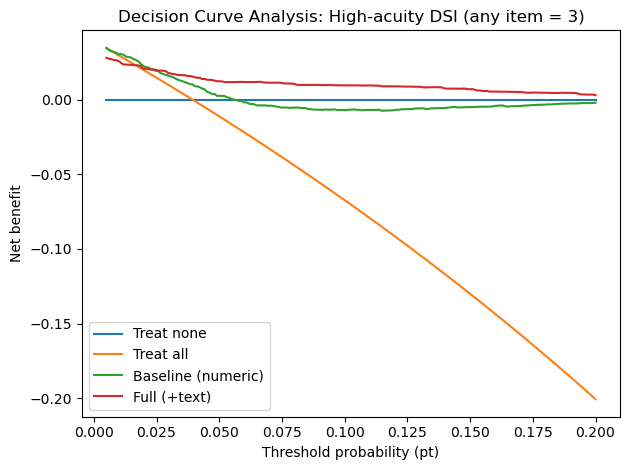

In [9]:
"""
Decision Curve Analysis (DCA) for high-acuity DSI (and any other cutoff you want)

This script:
1) Loads an OOF prediction CSV you already saved (contains y, p_base, p_full)
2) Computes net benefit across a grid of threshold probabilities
3) Computes reference strategies: Treat-all and Treat-none
4) Saves a CSV + prints a concise summary
5) (Optional) Plots the DCA curves (matplotlib only)

DCA notes:
- Net Benefit (NB) at threshold pt:
    NB = (TP/N) - (FP/N) * (pt / (1-pt))
- Treat-all NB:
    NB_all = prevalence - (1-prevalence) * (pt / (1-pt))
- Treat-none NB = 0
- Use OOF predictions for honest utility comparisons (you already have those).
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
OODIR = r"/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_dsi_fullbaseline_with_evals"

# Primary file (based on your results)
OOF_FILE = "oof_high_any_item_eq3__logit.csv"

# Threshold grid:
# For rare outcomes, focus on low thresholds (e.g., 0.5% to 20%)
PT_MIN = 0.005
PT_MAX = 0.20
N_PTS = 200

# If you want to restrict to a clinically plausible region (e.g., 1%-10%), set below:
# PT_MIN, PT_MAX = 0.01, 0.10

OUT_CSV = os.path.join(OODIR, "dca_high_any_item_eq3__logit.csv")
OUT_PNG = os.path.join(OODIR, "dca_high_any_item_eq3__logit.png")


# =========================
# FUNCTIONS
# =========================
def net_benefit(y, p, pt):
    """
    y: binary (0/1)
    p: predicted probabilities
    pt: threshold probability
    """
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)
    N = len(y)
    if N == 0:
        return np.nan

    pred_pos = (p >= pt).astype(int)
    TP = int(((pred_pos == 1) & (y == 1)).sum())
    FP = int(((pred_pos == 1) & (y == 0)).sum())

    w = pt / (1.0 - pt)  # harm/benefit tradeoff
    nb = (TP / N) - (FP / N) * w
    return nb


def treat_all_nb(y, pt):
    y = np.asarray(y).astype(int)
    N = len(y)
    prev = y.mean() if N else np.nan
    w = pt / (1.0 - pt)
    # Everyone positive: TP = positives, FP = negatives
    nb_all = prev - (1.0 - prev) * w
    return nb_all


# =========================
# LOAD OOF
# =========================
oof_path = os.path.join(OODIR, OOF_FILE)
df = pd.read_csv(oof_path)

# Required columns:
# y, p_base, p_full
y = df["y"].astype(int).values
p_base = df["p_base"].astype(float).values
p_full = df["p_full"].astype(float).values

print("Loaded:", oof_path)
print("N =", len(y), "| positives =", int(y.sum()), "| prevalence =", y.mean().round(4))

# =========================
# DCA GRID
# =========================
pts = np.linspace(PT_MIN, PT_MAX, N_PTS)

rows = []
for pt in pts:
    rows.append({
        "pt": pt,
        "NB_none": 0.0,
        "NB_all": treat_all_nb(y, pt),
        "NB_baseline": net_benefit(y, p_base, pt),
        "NB_full": net_benefit(y, p_full, pt),
        "Delta_full_minus_baseline": net_benefit(y, p_full, pt) - net_benefit(y, p_base, pt),
    })

dca = pd.DataFrame(rows)
dca.to_csv(OUT_CSV, index=False)
print("\nSaved DCA CSV:", OUT_CSV)

# Quick: where full beats baseline the most?
best = dca.loc[dca["Delta_full_minus_baseline"].idxmax()]
print("\nMax gain (Full - Baseline):")
print(best[["pt", "Delta_full_minus_baseline", "NB_baseline", "NB_full"]])

# =========================
# OPTIONAL PLOT
# =========================
plt.figure()
plt.plot(dca["pt"], dca["NB_none"], label="Treat none")
plt.plot(dca["pt"], dca["NB_all"], label="Treat all")
plt.plot(dca["pt"], dca["NB_baseline"], label="Baseline (numeric)")
plt.plot(dca["pt"], dca["NB_full"], label="Full (+text)")

plt.xlabel("Threshold probability (pt)")
plt.ylabel("Net benefit")
plt.title("Decision Curve Analysis: High-acuity DSI (any item = 3)")

plt.legend()
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300)
print("Saved DCA plot:", OUT_PNG)
plt.show()


In [15]:
"""
EMA NLP Crisis + DSI-SS risk: content + prediction pipeline (FULL SCRIPT)

What this script does (end-to-end):
1) Load merged dataset
2) Robustly detect:
   - participant id column (default: expiwell_id_clean)
   - date column (ema_date or inferred from any date-like column)
   - open text column (auto-detect; prefers 'ema_text')
   - DSI-SS daily PM items (4 items) using unique anchor text
3) Build ONE document per participant-day (pm_day_text)
4) Create DSI outcomes:
   - dsi_total
   - any_risk_total_gt0
   - moderate_total_ge2
   - high_any_item_eq3  (recommended “high risk” binary)
5) Compute embeddings (SentenceTransformers), cached to disk
6) Model: grouped (participant-level) CV
   - text-only concurrent prediction (AUROC/AUPRC)
   - baseline numeric-only (optional, if you have numeric covariates)
   - baseline + text (incremental value)
7) Content analysis options (recommended):
   A) SVD / PCA on embeddings + exemplar texts per component
   B) BERTopic topics + top docs
   C) (Optional) Lexicons: LIWC/empath (not included unless you add)

Notes:
- Your file does NOT have ema_datetime/ema_hour, so we treat all text as "PM open text" (consistent with your study design).
- This script is designed to run as-is. If you want to add “baseline numeric covariates”, set INCLUDE_NUMERIC_BASELINE=True
  and customize the column filters.

Requires:
pip install pandas numpy scikit-learn sentence-transformers umap-learn hdbscan bertopic

"""

import os
import re
import json
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA, TruncatedSVD

# ----------------------------
# USER SETTINGS
# ----------------------------
DATA_PATH = r"/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/ema_personality_plus_surveys_merged.csv"
OUTDIR = r"/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/content_analysis_outputs"
os.makedirs(OUTDIR, exist_ok=True)

PID_COL = "expiwell_id_clean"  # change if needed

# If you want to include numeric baseline covariates in the risk models:
INCLUDE_NUMERIC_BASELINE = True

# Embeddings
EMBED_MODEL = "sentence-transformers/all-mpnet-base-v2"
EMBED_CACHE = os.path.join(OUTDIR, "pm_day_embeddings_allmpnet.npy")

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

# ----------------------------
# 1) LOAD
# ----------------------------
df = pd.read_csv(DATA_PATH)
print(f"Loaded rows: {len(df)} | participants: {df[PID_COL].nunique()}")

# ----------------------------
# 2) FIND / CREATE ema_date (robust)
# ----------------------------
def pick_date_col(df):
    # Prefer exact ema_date
    if "ema_date" in df.columns:
        return "ema_date"
    # Common patterns
    candidates = []
    for c in df.columns:
        cl = c.lower()
        if cl in ["date", "day"] or "ema_date" in cl or cl.endswith("_date") or "date" == cl:
            candidates.append(c)
    if candidates:
        return candidates[0]
    # If no explicit date column, look for something date-like that parses
    for c in df.columns:
        if "date" in c.lower():
            return c
    return None

date_col = pick_date_col(df)
if date_col is None:
    raise ValueError("Could not find a date column. Please add/compute an ema_date field or set date_col manually.")

df["ema_date"] = pd.to_datetime(df[date_col], errors="coerce").dt.date.astype("string")
if df["ema_date"].isna().mean() > 0.25:
    # sometimes ema_date is already a string date; try coercion without dt.date
    df["ema_date"] = df[date_col].astype("string")

print("Using date column:", date_col, "-> ema_date created.")

# ----------------------------
# 3) AUTO-DETECT TEXT COLUMN
# ----------------------------
def score_text_col(s: pd.Series) -> float:
    s = s.dropna()
    if len(s) == 0:
        return 0.0
    s = s.sample(min(500, len(s)), random_state=RANDOM_SEED)
    s_str = s.astype(str)
    avg_len = s_str.str.len().mean()
    space_rate = (s_str.str.contains(r"\s", regex=True)).mean()
    short_rate = (s_str.str.len() < 5).mean()
    return float(avg_len * (0.5 + space_rate) * (1 - 0.7 * short_rate))

def pick_text_col(df):
    preferred_substrings = ["ema_text", "open", "text", "response", "free", "prompt", "comment", "journal", "entry"]
    candidate_cols = []
    for c in df.columns:
        if df[c].dtype == "object" or pd.api.types.is_string_dtype(df[c]):
            cl = c.lower()
            if any(sub in cl for sub in preferred_substrings):
                candidate_cols.append(c)
    if not candidate_cols:
        candidate_cols = [c for c in df.columns if (df[c].dtype == "object" or pd.api.types.is_string_dtype(df[c]))]

    scored = [(c, score_text_col(df[c])) for c in candidate_cols]
    scored = sorted(scored, key=lambda x: x[1], reverse=True)

    print("\nTop text-column candidates:")
    for c, sc in scored[:10]:
        print(f"  {c:40s} score={sc:.2f}")

    best = scored[0][0] if scored and scored[0][1] > 0 else None
    return best

TEXT_COL = pick_text_col(df)
if TEXT_COL is None:
    raise ValueError("Could not auto-detect a text column. Set TEXT_COL manually.")
print("\nUsing TEXT_COL =", TEXT_COL)

df[TEXT_COL] = df[TEXT_COL].astype("string")

# ----------------------------
# 4) HELPERS
# ----------------------------
def first_nonnull(s):
    s2 = s.dropna()
    return s2.iloc[0] if len(s2) else np.nan

# ----------------------------
# 5) DETECT DSI-SS DAILY PM ITEMS (unique)
# ----------------------------
def detect_dsi_columns_unique(df):
    anchors = {
        "A": ["thoughts of killing myself"],
        "B": ["formulated a definite plan"],
        "C": ["under my control"],
        "D": ["impulses to kill myself"],
    }
    candidates = {k: [] for k in anchors}
    for col in df.columns:
        if not col.startswith("dailyPM__"):
            continue
        col_l = col.lower()
        for k, subs in anchors.items():
            if all(sub in col_l for sub in subs):
                candidates[k].append(col)

    chosen, used = {}, set()
    for k in ["A", "B", "C", "D"]:
        cols = candidates[k]
        if not cols:
            continue
        cols_sorted = sorted(cols, key=len, reverse=True)
        for c in cols_sorted:
            if c not in used:
                chosen[k] = c
                used.add(c)
                break
    return chosen

DSI_COLS = detect_dsi_columns_unique(df)
print("\nDetected dailyPM DSI columns (unique):")
print(DSI_COLS)

dsi_item_cols = [DSI_COLS.get(k, None) for k in ["A", "B", "C", "D"]]
if any(c is None for c in dsi_item_cols):
    missing = [k for k, c in zip(["A", "B", "C", "D"], dsi_item_cols) if c is None]
    raise ValueError(f"Could not detect all 4 unique DSI items. Missing: {missing}")

# Cast to numeric
for c in dsi_item_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# ----------------------------
# 6) BUILD ONE DOCUMENT PER PARTICIPANT-DAY
# ----------------------------
pm_day = (
    df.sort_values([PID_COL, "ema_date"])
      .groupby([PID_COL, "ema_date"], as_index=False)
      .agg(
          pm_day_text=(TEXT_COL, lambda s: " ".join([t for t in s.dropna().astype(str) if t.strip() != ""])),
          n_text_prompts=(TEXT_COL, lambda s: int(s.notna().sum())),
          **{c: (c, first_nonnull) for c in dsi_item_cols}
      )
)

pm_day["has_text"] = pm_day["pm_day_text"].fillna("").str.strip().ne("")
pm_day = pm_day.loc[pm_day["has_text"]].reset_index(drop=True)

print("\nPM-day docs:", len(pm_day), "| participants:", pm_day[PID_COL].nunique())

# ----------------------------
# 7) CREATE DSI OUTCOMES
# ----------------------------
pm_day["dsi_total"] = pm_day[dsi_item_cols].sum(axis=1, min_count=1)
pm_day["any_risk_total_gt0"] = (pm_day["dsi_total"] > 0).astype(int)
pm_day["moderate_total_ge2"] = (pm_day["dsi_total"] >= 2).astype(int)
pm_day["high_any_item_eq3"] = (pm_day[dsi_item_cols].max(axis=1) == 3).astype(int)

usable = pm_day.dropna(subset=["dsi_total"]).copy()
print("Usable rows:", len(usable), "| participants:", usable[PID_COL].nunique())
print("Pos rates:",
      "any>", round(usable["any_risk_total_gt0"].mean(), 4),
      "mod>=2", round(usable["moderate_total_ge2"].mean(), 4),
      "high(any=3)", round(usable["high_any_item_eq3"].mean(), 4))

# Save checkpoint
chk_path = os.path.join(OUTDIR, "pm_day_checkpoint_for_content.csv")
usable.to_csv(chk_path, index=False)
print("Saved checkpoint:", chk_path)

# ----------------------------
# 8) EMBEDDINGS (CACHE)
# ----------------------------
X_text = None
if os.path.exists(EMBED_CACHE):
    X_text = np.load(EMBED_CACHE)
    if X_text.shape[0] != len(usable):
        print("Embedding cache exists but row count mismatched; recomputing.")
        X_text = None

if X_text is None:
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(EMBED_MODEL)
    X_text = model.encode(
        usable["pm_day_text"].tolist(),
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True
    )
    np.save(EMBED_CACHE, X_text)

print("X_text:", X_text.shape)

# ----------------------------
# 9) (OPTIONAL) NUMERIC BASELINE FEATURES
# ----------------------------
# We’ll include numeric columns EXCLUDING:
# - the DSI items/derived outcomes
# - text columns
# - IDs/dates
# You can tighten this further if needed.

def build_numeric_baseline(df_day):
    exclude = set([PID_COL, "ema_date", "pm_day_text", "has_text", "n_text_prompts"])
    exclude |= set(dsi_item_cols)
    exclude |= set(["dsi_total", "any_risk_total_gt0", "moderate_total_ge2", "high_any_item_eq3"])
    # exclude anything that looks like free text or IDs
    for c in df_day.columns:
        cl = c.lower()
        if "text" in cl or "response" in cl or "open" in cl:
            exclude.add(c)

    num_cols = [c for c in df_day.columns
                if c not in exclude and pd.api.types.is_numeric_dtype(df_day[c])]
    X = df_day[num_cols].copy()
    # Simple impute
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True))
    return X.to_numpy(), num_cols

if INCLUDE_NUMERIC_BASELINE:
    X_num, NUM_COLS = build_numeric_baseline(usable)
    print("X_num:", X_num.shape, "| numeric cols:", len(NUM_COLS))
else:
    X_num, NUM_COLS = None, []

# ----------------------------
# 10) GROUPED CV EVALUATION (AUROC/AUPRC)
# ----------------------------
def grouped_cv_probabilities(X, y, groups, model, n_splits=5, label=""):
    gkf = GroupKFold(n_splits=n_splits)
    y = np.asarray(y).astype(int)
    probs = np.zeros(len(y), dtype=float)

    for fold, (tr, te) in enumerate(gkf.split(X, y, groups=groups), start=1):
        model.fit(X[tr], y[tr])
        probs[te] = model.predict_proba(X[te])[:, 1]

    auroc = roc_auc_score(y, probs) if len(np.unique(y)) > 1 else np.nan
    auprc = average_precision_score(y, probs) if len(np.unique(y)) > 1 else np.nan
    print(f"{label} AUROC={auroc:.3f} AUPRC={auprc:.3f}")
    return probs, {"AUROC": auroc, "AUPRC": auprc}

def fit_eval_binary(y_name, use_balanced=False):
    y = usable[y_name].values
    groups = usable[PID_COL].values

    # Baseline model
    if INCLUDE_NUMERIC_BASELINE and X_num is not None and X_num.shape[1] > 0:
        base = Pipeline([
            ("scaler", StandardScaler()),
            ("logit", LogisticRegression(
                max_iter=2000,
                class_weight=("balanced" if use_balanced else None),
                random_state=RANDOM_SEED
            ))
        ])
        base_probs, base_metrics = grouped_cv_probabilities(
            X_num, y, groups, base, label=f"Baseline({y_name})"
        )
    else:
        base_probs, base_metrics = None, {"AUROC": np.nan, "AUPRC": np.nan}

    # Full model: Text -> PCA -> Logistic
    # Use PCA to reduce 768-d embeddings for stability
    pca_dim = 50
    full = Pipeline([
        ("pca", PCA(n_components=pca_dim, random_state=RANDOM_SEED)),
        ("logit", LogisticRegression(
            max_iter=2000,
            class_weight=("balanced" if use_balanced else None),
            random_state=RANDOM_SEED
        ))
    ])

    # If you have numeric baseline, concatenate text PCs + numeric
    if INCLUDE_NUMERIC_BASELINE and X_num is not None and X_num.shape[1] > 0:
        # we will do this manually in CV to avoid leakage
        gkf = GroupKFold(n_splits=5)
        probs_full = np.zeros(len(y), dtype=float)

        for fold, (tr, te) in enumerate(gkf.split(X_text, y, groups=groups), start=1):
            # fit PCA on train text
            pca = PCA(n_components=pca_dim, random_state=RANDOM_SEED)
            Ztr = pca.fit_transform(X_text[tr])
            Zte = pca.transform(X_text[te])

            # concat with numeric
            Xtr = np.hstack([Ztr, X_num[tr]])
            Xte = np.hstack([Zte, X_num[te]])

            mdl = Pipeline([
                ("scaler", StandardScaler()),
                ("logit", LogisticRegression(
                    max_iter=2000,
                    class_weight=("balanced" if use_balanced else None),
                    random_state=RANDOM_SEED
                ))
            ])
            mdl.fit(Xtr, y[tr])
            probs_full[te] = mdl.predict_proba(Xte)[:, 1]

        auroc = roc_auc_score(y, probs_full) if len(np.unique(y)) > 1 else np.nan
        auprc = average_precision_score(y, probs_full) if len(np.unique(y)) > 1 else np.nan
        full_metrics = {"AUROC": auroc, "AUPRC": auprc}
        print(f"Full+Num({y_name}) AUROC={auroc:.3f} AUPRC={auprc:.3f}")

    else:
        probs_full, full_metrics = grouped_cv_probabilities(
            X_text, y, groups, full, label=f"TextOnly({y_name})"
        )

    # Save OOF probabilities for DCA / top-K eval
    out_probs = pd.DataFrame({
        PID_COL: usable[PID_COL].values,
        "ema_date": usable["ema_date"].values,
        y_name: y,
        "prob_full": probs_full,
    })
    if base_probs is not None:
        out_probs["prob_baseline"] = base_probs

    out_path = os.path.join(OUTDIR, f"oof_probs_{y_name}{'_balanced' if use_balanced else ''}.csv")
    out_probs.to_csv(out_path, index=False)
    print("Saved:", out_path)

    # Summary
    return {
        "y_name": y_name,
        "balanced": use_balanced,
        "pos_rate": float(y.mean()),
        "baseline_AUROC": float(base_metrics["AUROC"]) if base_metrics["AUROC"]==base_metrics["AUROC"] else None,
        "baseline_AUPRC": float(base_metrics["AUPRC"]) if base_metrics["AUPRC"]==base_metrics["AUPRC"] else None,
        "full_AUROC": float(full_metrics["AUROC"]) if full_metrics["AUROC"]==full_metrics["AUROC"] else None,
        "full_AUPRC": float(full_metrics["AUPRC"]) if full_metrics["AUPRC"]==full_metrics["AUPRC"] else None,
    }

# Run the 3 risk cutoffs (both standard + balanced)
summaries = []
for y_name in ["any_risk_total_gt0", "moderate_total_ge2", "high_any_item_eq3"]:
    summaries.append(fit_eval_binary(y_name, use_balanced=False))
    summaries.append(fit_eval_binary(y_name, use_balanced=True))

sum_path = os.path.join(OUTDIR, "risk_model_summaries.json")
with open(sum_path, "w") as f:
    json.dump(summaries, f, indent=2)
print("Saved model summaries:", sum_path)

# ----------------------------
# 11) TOP-K / RESOURCE-ALLOCATION EVAL (from OOF probs)
# ----------------------------
def topk_eval(y, probs, top_fracs=(0.01, 0.02, 0.05, 0.10)):
    y = np.asarray(y).astype(int)
    order = np.argsort(-probs)
    out = []
    n = len(y)
    for frac in top_fracs:
        k = int(np.ceil(frac * n))
        idx = order[:k]
        tp = y[idx].sum()
        precision = tp / k if k > 0 else np.nan
        recall = tp / y.sum() if y.sum() > 0 else np.nan
        out.append({"top_frac": frac, "k_days": k, "precision": precision, "recall": recall})
    return pd.DataFrame(out)

def run_topk_for_outcome(y_name, balanced=False):
    prob_path = os.path.join(OUTDIR, f"oof_probs_{y_name}{'_balanced' if balanced else ''}.csv")
    d = pd.read_csv(prob_path)
    y = d[y_name].values
    full = topk_eval(y, d["prob_full"].values)

    if "prob_baseline" in d.columns:
        base = topk_eval(y, d["prob_baseline"].values)
        merged = full.merge(base, on=["top_frac", "k_days"], suffixes=("_full", "_baseline"))
        merged["delta_precision"] = merged["precision_full"] - merged["precision_baseline"]
        merged["delta_recall"] = merged["recall_full"] - merged["recall_baseline"]
        out = merged
    else:
        out = full

    out_path = os.path.join(OUTDIR, f"eval_topk_{y_name}{'_balanced' if balanced else ''}.csv")
    out.to_csv(out_path, index=False)
    print("Saved top-k eval:", out_path)

for y_name in ["high_any_item_eq3", "moderate_total_ge2", "any_risk_total_gt0"]:
    run_topk_for_outcome(y_name, balanced=False)
    run_topk_for_outcome(y_name, balanced=True)

# ----------------------------
# 12) DCA (Decision Curve Analysis) CODE
# ----------------------------
# This uses the OOF probabilities (full vs baseline).
# Net benefit = (TP/N) - (FP/N) * (pt/(1-pt))
def decision_curve(y, probs, thresholds=np.linspace(0.01, 0.50, 50)):
    y = np.asarray(y).astype(int)
    N = len(y)
    out = []
    for pt in thresholds:
        pred = (probs >= pt).astype(int)
        TP = ((pred == 1) & (y == 1)).sum()
        FP = ((pred == 1) & (y == 0)).sum()

        nb = (TP / N) - (FP / N) * (pt / (1 - pt))
        out.append({"threshold": pt, "net_benefit": nb, "TP": int(TP), "FP": int(FP)})
    return pd.DataFrame(out)

def treat_all_curve(y, thresholds=np.linspace(0.01, 0.50, 50)):
    y = np.asarray(y).astype(int)
    N = len(y)
    prevalence = y.mean()
    out = []
    for pt in thresholds:
        # treat all: TP = positives, FP = negatives
        TP = y.sum()
        FP = (N - y.sum())
        nb = (TP / N) - (FP / N) * (pt / (1 - pt))
        out.append({"threshold": pt, "net_benefit": nb})
    return pd.DataFrame(out)

def treat_none_curve(thresholds=np.linspace(0.01, 0.50, 50)):
    return pd.DataFrame({"threshold": thresholds, "net_benefit": np.zeros_like(thresholds)})

def run_dca(y_name, balanced=False):
    prob_path = os.path.join(OUTDIR, f"oof_probs_{y_name}{'_balanced' if balanced else ''}.csv")
    d = pd.read_csv(prob_path)
    y = d[y_name].values

    thresholds = np.linspace(0.01, 0.50, 50)

    d_full = decision_curve(y, d["prob_full"].values, thresholds)
    d_full["model"] = "full"

    curves = [d_full]

    if "prob_baseline" in d.columns:
        d_base = decision_curve(y, d["prob_baseline"].values, thresholds)
        d_base["model"] = "baseline"
        curves.append(d_base)

    d_all = treat_all_curve(y, thresholds)
    d_all["model"] = "treat_all"
    curves.append(d_all)

    d_none = treat_none_curve(thresholds)
    d_none["model"] = "treat_none"
    curves.append(d_none)

    out = pd.concat(curves, ignore_index=True)
    out_path = os.path.join(OUTDIR, f"dca_{y_name}{'_balanced' if balanced else ''}.csv")
    out.to_csv(out_path, index=False)
    print("Saved DCA:", out_path)

for y_name in ["high_any_item_eq3", "moderate_total_ge2", "any_risk_total_gt0"]:
    run_dca(y_name, balanced=False)
    run_dca(y_name, balanced=True)

# ----------------------------
# 13) CONTENT ANALYSIS (Embeddings -> SVD components + exemplar texts)
# ----------------------------
# This answers: “what content is in these messages?” using the embedding space.

def svd_exemplars(X, texts, n_components=10, top_n=10):
    svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_SEED)
    Z = svd.fit_transform(X)
    comps = svd.components_  # (k, d)

    rows = []
    for k in range(n_components):
        # score docs by projection on component k
        scores = Z[:, k]
        top_idx = np.argsort(-scores)[:top_n]
        for rank, i in enumerate(top_idx, start=1):
            rows.append({
                "component": k + 1,
                "rank": rank,
                "score": float(scores[i]),
                "text": texts[i]
            })
    return svd, pd.DataFrame(rows)

svd, ex = svd_exemplars(X_text, usable["pm_day_text"].tolist(), n_components=12, top_n=15)
ex_path = os.path.join(OUTDIR, "svd_exemplar_texts.csv")
ex.to_csv(ex_path, index=False)
print("Saved SVD exemplar texts:", ex_path)

# Also save explained variance ratios
ev = pd.DataFrame({
    "component": np.arange(1, len(svd.explained_variance_ratio_) + 1),
    "explained_variance_ratio": svd.explained_variance_ratio_
})
ev_path = os.path.join(OUTDIR, "svd_explained_variance.csv")
ev.to_csv(ev_path, index=False)
print("Saved SVD explained variance:", ev_path)

# ----------------------------
# 14) CONTENT ANALYSIS (BERTopic)
# ----------------------------
# BERTopic is great for human-interpretable themes. It uses embeddings + clustering + c-TF-IDF.
# If BERTopic install causes pain, skip this block and rely on SVD exemplars.

try:
    from bertopic import BERTopic
    from umap import UMAP
    import hdbscan

    docs = usable["pm_day_text"].tolist()

    umap_model = UMAP(n_neighbors=15, n_components=5, metric="cosine", random_state=RANDOM_SEED)
    hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=30, metric="euclidean", prediction_data=True)

    topic_model = BERTopic(
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        verbose=True,
        calculate_probabilities=True
    )

    topics, probs = topic_model.fit_transform(docs, embeddings=X_text)

    usable["topic"] = topics
    topic_info = topic_model.get_topic_info()
    topic_info_path = os.path.join(OUTDIR, "bertopic_topic_info.csv")
    topic_info.to_csv(topic_info_path, index=False)
    print("Saved topic info:", topic_info_path)

    # Save top docs per topic
    top_docs_rows = []
    for t in sorted(set(topics)):
        if t == -1:
            continue
        idx = np.where(np.array(topics) == t)[0]
        # choose top by max topic prob if available
        if probs is not None:
            t_probs = probs[idx, topic_model.topic_labels_.index(topic_model.get_topic_info().loc[topic_model.get_topic_info().Topic==t].Name.values[0])] if False else None
        # simpler: choose longest docs for review
        idx_sorted = sorted(idx, key=lambda i: len(docs[i]), reverse=True)[:10]
        for rank, i in enumerate(idx_sorted, start=1):
            top_docs_rows.append({"topic": t, "rank": rank, "n_chars": len(docs[i]), "text": docs[i]})

    top_docs = pd.DataFrame(top_docs_rows)
    top_docs_path = os.path.join(OUTDIR, "bertopic_top_docs_per_topic.csv")
    top_docs.to_csv(top_docs_path, index=False)
    print("Saved top docs per topic:", top_docs_path)

    # Save document-topic assignments
    assign_path = os.path.join(OUTDIR, "bertopic_doc_topics.csv")
    usable[[PID_COL, "ema_date", "topic"]].to_csv(assign_path, index=False)
    print("Saved doc-topic assignments:", assign_path)

except Exception as e:
    print("\n[BERTopic block skipped due to error]")
    print("Error:", str(e))

print("\nDONE. Outputs saved to:", OUTDIR)


Loaded rows: 2742 | participants: 123
Using date column: ema_date -> ema_date created.

Top text-column candidates:
  ema_text                                 score=194.36
  baseline_response_id                     score=8.50

Using TEXT_COL = ema_text

Detected dailyPM DSI columns (unique):
{'A': "dailyPM__[ 0 = 'I am not having thoughts of killing myself. ' 1 = 'Sometimes I have had thoughts of killing myself.' 2 = 'Most of the time I have had thoughts of killing myself. ' 3 = 'I am always having thoughts of killing myself.'  ]", 'B': "dailyPM__[ 0 = 'I have not had any thoughts about suicide. ' 1 = 'I have had thoughts about suicide but not formulated any plans. ' 2 = 'I have been having thoughts of suicide and have considered possible ways of doing it. ' 3 = 'I am having thoughts about suicide and have formulated a definite plan.'  ]", 'C': "dailyPM__[ 0 = 'I have not had thoughts about suicide. ' 1 = 'I have been having thoughts about suicide but have these thoughts completely und

Batches:   0%|          | 0/43 [00:00<?, ?it/s]

X_text: (2733, 768)
X_num: (2733, 0) | numeric cols: 0
TextOnly(any_risk_total_gt0) AUROC=0.717 AUPRC=0.576
Saved: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/content_analysis_outputs/oof_probs_any_risk_total_gt0.csv
TextOnly(any_risk_total_gt0) AUROC=0.725 AUPRC=0.587
Saved: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/content_analysis_outputs/oof_probs_any_risk_total_gt0_balanced.csv
TextOnly(moderate_total_ge2) AUROC=0.716 AUPRC=0.558
Saved: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/content_analysis_outputs/oof_probs_moderate_total_ge2.csv
TextOnly(moderate_total_ge2) AUROC=0.724 AUPRC=0.567
Saved: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/content_analysis_outputs/oof_probs_moderate_total_ge2_balanced.csv
TextOnly(high_any_item_eq3) AUROC=0

2026-01-01 19:43:31,037 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-01 19:43:42,879 - BERTopic - Dimensionality - Completed ✓
2026-01-01 19:43:42,881 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-01 19:43:42,992 - BERTopic - Cluster - Completed ✓
2026-01-01 19:43:43,003 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-01 19:43:43,044 - BERTopic - Representation - Completed ✓


Saved topic info: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/content_analysis_outputs/bertopic_topic_info.csv
Saved top docs per topic: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/content_analysis_outputs/bertopic_top_docs_per_topic.csv
Saved doc-topic assignments: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/content_analysis_outputs/bertopic_doc_topics.csv

DONE. Outputs saved to: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/content_analysis_outputs


In [27]:
import os
import json
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

from sentence_transformers import SentenceTransformer

# =========================
# USER SETTINGS (EDIT THESE)
# =========================
DATA_PATH = r"/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/ema_personality_plus_surveys_merged.csv"

# If you KNOW these, set them now (recommended). Otherwise leave as None for auto-detect.
PID_COL  = None   # e.g., "participant_id" or "prolific_pid"
DATE_COL = "ema_date"  # you already have ema_date; keep this unless different
TEXT_COL = None   # e.g., "ema_text"

OUTDIR = r"/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_within_person_deviation"
os.makedirs(OUTDIR, exist_ok=True)

EMBED_MODEL = "sentence-transformers/all-mpnet-base-v2"
EMBED_CACHE = os.path.join(OUTDIR, "daily_embeddings_mpnet.npy")

N_PCS = 20
RANDOM_SEED = 42
N_SPLITS = 5
LOGIT_MAX_ITER = 5000
USE_CLASS_WEIGHT_BALANCED = True

OUTCOMES_TO_EVAL = [
    "any_risk_total_gt0",
    "moderate_total_ge2",
    "high_any_item_eq3"
]

# =========================
# HELPERS
# =========================
def first_nonnull(series: pd.Series):
    s = series.dropna()
    return s.iloc[0] if len(s) else np.nan

def coerce_ema_date(df: pd.DataFrame, date_col: str) -> pd.DataFrame:
    dt = pd.to_datetime(df[date_col], errors="coerce", utc=False)
    return df.assign(ema_date=dt.dt.date.astype("string"))

def guess_text_col(df: pd.DataFrame) -> str:
    for c in df.columns:
        if c.lower() in ["ema_text","response","text","open_text","free_text","entry_text"]:
            return c
    # heuristic: string/object column with longest avg length
    best, best_score = None, -1
    for c in df.columns:
        if df[c].dtype == "O" or str(df[c].dtype).startswith("string"):
            s = df[c].dropna().astype(str)
            if len(s) < 50:
                continue
            avg_len = s.str.len().mean()
            if avg_len > best_score:
                best, best_score = c, avg_len
    if best is None:
        raise ValueError("Could not infer text column. Set TEXT_COL manually.")
    return best

def pid_candidates(df: pd.DataFrame, top_k: int = 15) -> pd.DataFrame:
    """
    Rank columns by plausibility as participant id.
    Excludes date/time-ish columns and very-high-uniqueness columns (like row ids).
    """
    n = len(df)
    rows = []
    for c in df.columns:
        cl = c.lower()
        # hard exclude likely time/date columns
        if any(x in cl for x in ["date", "dt", "time", "timestamp", "ema_date", "week", "month", "year"]):
            continue
        s = df[c]
        nun = s.nunique(dropna=True)
        if nun < 2:
            continue
        # exclude almost-unique IDs (row ids)
        if nun > 0.95 * n:
            continue
        # prefer columns containing these substrings
        name_bonus = 0
        if any(x in cl for x in ["participant", "prolific", "pid", "subject", "user", "record"]):
            name_bonus = 5

        # prefer moderate nunique: not tiny, not huge
        # score peaks around nun ~ n/50 .. n/5 depending on dataset
        frac = nun / n
        frac_score = 1 - abs(frac - 0.05)  # heuristic target ~5% unique values
        # dtype bonus
        dtype_bonus = 1 if (s.dtype == "O" or str(s.dtype).startswith("string")) else 0.5

        score = 10*frac_score + 2*dtype_bonus + name_bonus
        rows.append((c, nun, frac, score))

    out = pd.DataFrame(rows, columns=["col", "n_unique", "unique_frac", "score"]).sort_values("score", ascending=False)
    return out.head(top_k)

def guess_pid_col(df: pd.DataFrame) -> str:
    # strong name matches first
    for c in df.columns:
        cl = c.lower()
        if any(k in cl for k in ["participant_id", "prolific_pid", "prolific_id", "subject_id", "pid", "participant"]):
            # avoid date-like
            if not any(x in cl for x in ["date","dt","time","timestamp"]):
                return c
    # otherwise take best candidate from ranking
    cand = pid_candidates(df, top_k=1)
    if cand.empty:
        raise ValueError("Could not infer PID column. Set PID_COL manually.")
    return cand.iloc[0]["col"]

def detect_dsi_pm_cols(df: pd.DataFrame) -> list[str]:
    cols = list(df.columns)
    key_phrases = [
        "thoughts of killing myself",
        "formulated a definite plan",
        "under my control",
        "impulses to kill myself",
    ]
    hits = []
    for c in cols:
        cl = str(c).lower()
        if "dailypm__" not in cl:
            continue
        if (" 3 =" in cl) and any(k in cl for k in key_phrases):
            hits.append(c)

    picked = []
    for phrase in key_phrases:
        for c in hits:
            if phrase in str(c).lower():
                picked.append(c)
                break

    if len(picked) < 4:
        raise ValueError(f"Could not detect all 4 DSI PM items. Found {len(picked)}.")
    return picked[:4]

def cosine_distance_rows(X_unit: np.ndarray, C_unit: np.ndarray) -> np.ndarray:
    sim = np.sum(X_unit * C_unit, axis=1)
    sim = np.clip(sim, -1.0, 1.0)
    return 1.0 - sim

def icc_1way_random(x: pd.Series, groups: pd.Series) -> float:
    df0 = pd.DataFrame({"x": x.values, "g": groups.values}).dropna()
    if df0.empty:
        return np.nan
    gstats = df0.groupby("g")["x"].agg(["mean","count"])
    k_bar = gstats["count"].mean()
    grand = df0["x"].mean()
    ss_between = np.sum(gstats["count"] * (gstats["mean"] - grand) ** 2)
    df_between = gstats.shape[0] - 1
    ms_between = ss_between / df_between if df_between > 0 else np.nan
    merged = df0.merge(gstats["mean"].rename("gmean"), left_on="g", right_index=True)
    ss_within = np.sum((merged["x"] - merged["gmean"]) ** 2)
    df_within = len(df0) - gstats.shape[0]
    ms_within = ss_within / df_within if df_within > 0 else np.nan
    if np.isnan(ms_between) or np.isnan(ms_within):
        return np.nan
    denom = (ms_between + (k_bar - 1.0) * ms_within)
    return float((ms_between - ms_within) / denom) if denom != 0 else np.nan

def oof_groupkfold_logit(X: np.ndarray, y: np.ndarray, groups: np.ndarray, label: str):
    gkf = GroupKFold(n_splits=N_SPLITS)
    oof = np.full(shape=(len(y),), fill_value=np.nan, dtype=float)

    aurocs, auprcs = [], []
    distance_betas, distance_ors = [], []

    for fold, (tr, te) in enumerate(gkf.split(X, y, groups=groups), start=1):
        y_tr = y[tr]
        y_te = y[te]
        if len(np.unique(y_tr)) < 2:
            p_const = float(np.mean(y_tr))
            oof[te] = p_const
            print(f"{label} fold {fold}: degenerate train -> const p={p_const:.4f}")
            continue

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("logit", LogisticRegression(
                solver="liblinear",
                max_iter=LOGIT_MAX_ITER,
                class_weight=("balanced" if USE_CLASS_WEIGHT_BALANCED else None),
                random_state=RANDOM_SEED
            ))
        ])
        pipe.fit(X[tr], y_tr)
        p = pipe.predict_proba(X[te])[:, 1]
        oof[te] = p

        if len(np.unique(y_te)) >= 2:
            auroc = roc_auc_score(y_te, p)
            auprc = average_precision_score(y_te, p)
            aurocs.append(auroc); auprcs.append(auprc)
            print(f"{label} fold {fold}: AUROC={auroc:.3f} AUPRC={auprc:.3f} n={len(te)}")
        else:
            print(f"{label} fold {fold}: test 1-class; metrics skipped n={len(te)}")

        # if X has distance as last col, store standardized beta & OR
        try:
            beta = float(pipe.named_steps["logit"].coef_.ravel()[-1])
            distance_betas.append(beta)
            distance_ors.append(float(np.exp(beta)))
        except Exception:
            pass

    mask = np.isfinite(oof)
    y2 = y[mask]; p2 = oof[mask]
    overall_auroc = roc_auc_score(y2, p2) if len(np.unique(y2)) >= 2 else np.nan
    overall_auprc = average_precision_score(y2, p2) if len(np.unique(y2)) >= 2 else np.nan

    coef_summary = None
    if len(distance_betas) > 0:
        coef_summary = {
            "beta_mean": float(np.mean(distance_betas)),
            "beta_sd": float(np.std(distance_betas, ddof=1)) if len(distance_betas) > 1 else 0.0,
            "or_mean": float(np.mean(distance_ors)),
            "or_sd": float(np.std(distance_ors, ddof=1)) if len(distance_ors) > 1 else 0.0,
            "n_folds_with_beta": int(len(distance_betas)),
        }

    return {
        "label": label,
        "oof_prob": oof,
        "AUROC": float(overall_auroc) if overall_auroc == overall_auroc else np.nan,
        "AUPRC": float(overall_auprc) if overall_auprc == overall_auprc else np.nan,
        "distance_coef_summary": coef_summary
    }

# =========================
# LOAD
# =========================
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded rows: {len(df)}")

# Identify columns
if PID_COL is None:
    print("\nTop PID candidates (review this):")
    print(pid_candidates(df).to_string(index=False))
    PID_COL = guess_pid_col(df)

if TEXT_COL is None:
    TEXT_COL = guess_text_col(df)

print("\nUsing PID_COL :", PID_COL)
print("Using DATE_COL:", DATE_COL)
print("Using TEXT_COL:", TEXT_COL)

# Parse date + text
df = coerce_ema_date(df, DATE_COL)
df[TEXT_COL] = df[TEXT_COL].astype("string")

print(f"\nParticipants (raw, based on PID_COL): {df[PID_COL].nunique(dropna=True)}")

# =========================
# DAILY DOCUMENTS
# =========================
day = (
    df.sort_values([PID_COL, "ema_date"])
      .groupby([PID_COL, "ema_date"], as_index=False)
      .agg(
          day_text=(TEXT_COL, lambda s: " ".join([t for t in s.dropna().astype(str).tolist() if t.strip() != ""])),
          n_text_prompts=(TEXT_COL, lambda s: int(s.notna().sum())),
      )
)
day["has_text"] = day["day_text"].fillna("").str.strip().ne("")
day = day.loc[day["has_text"]].reset_index(drop=True)

print(f"\nDaily docs with text: {len(day)}")
print(f"Participants in daily table: {day[PID_COL].nunique()}")

# =========================
# DSI ITEMS + OUTCOMES (FIXED AGG)
# =========================
DSI_PM_COLS = detect_dsi_pm_cols(df)
print("\nDetected DSI-SS columns (dailyPM):")
for c in DSI_PM_COLS:
    print(" -", c)

# IMPORTANT FIX: dict aggregation, not named-agg via kwargs
day_dsi = (
    df.sort_values([PID_COL, "ema_date"])
      .groupby([PID_COL, "ema_date"], as_index=False)[DSI_PM_COLS]
      .agg({c: first_nonnull for c in DSI_PM_COLS})
)

day = day.merge(day_dsi, on=[PID_COL, "ema_date"], how="left")

for c in DSI_PM_COLS:
    day[c] = pd.to_numeric(day[c], errors="coerce")

# DSI outcomes
day["dsi_total"] = day[DSI_PM_COLS].sum(axis=1, min_count=1)
day["any_risk_total_gt0"] = (day["dsi_total"] > 0).astype(int)
day["moderate_total_ge2"] = (day["dsi_total"] >= 2).astype(int)
day["high_any_item_eq3"]  = (day[DSI_PM_COLS].eq(3).any(axis=1)).astype(int)

# keep complete DSI days
day = day.loc[day[DSI_PM_COLS].notna().all(axis=1)].reset_index(drop=True)
print(f"\nUsable rows with complete DSI items: {len(day)} | participants: {day[PID_COL].nunique()}")
for o in OUTCOMES_TO_EVAL:
    print(f"Outcome {o}: pos_rate={day[o].mean():.4f}")

# =========================
# EMBEDDINGS (DAILY)
# =========================
texts = day["day_text"].astype(str).tolist()

if os.path.exists(EMBED_CACHE):
    X = np.load(EMBED_CACHE)
    print("\nLoaded cached embeddings:", X.shape)
    if X.shape[0] != len(day):
        raise ValueError(
            f"Embedding cache rows ({X.shape[0]}) != current day rows ({len(day)}).\n"
            f"Delete cache and rerun: {EMBED_CACHE}"
        )
else:
    model = SentenceTransformer(EMBED_MODEL)
    X = model.encode(texts, batch_size=64, show_progress_bar=True, normalize_embeddings=True)
    np.save(EMBED_CACHE, X)
    print("\nSaved embeddings:", EMBED_CACHE, "shape:", X.shape)

print("Embedding shape:", X.shape)

# =========================
# CENTROIDS + WITHIN-PERSON DEVIATION
# =========================
pid = day[PID_COL].values
centroids = np.zeros_like(X, dtype=float)
centroid_map = {}

for p in np.unique(pid):
    idx = np.where(pid == p)[0]
    c = X[idx].mean(axis=0)
    nrm = np.linalg.norm(c)
    if nrm > 0:
        c = c / nrm
    centroid_map[p] = c
    centroids[idx] = c

day["distance_from_centroid"] = cosine_distance_rows(X, centroids)

print("\nDistance-from-centroid descriptives:")
print(day["distance_from_centroid"].describe(percentiles=[.01,.05,.5,.95,.99]))
icc = icc_1way_random(day["distance_from_centroid"], day[PID_COL])
print(f"ICC(1) of distance_from_centroid: {icc:.3f}")

# =========================
# PCA + PROJECT CENTROIDS INTO PCA SPACE
# =========================
pca = PCA(n_components=N_PCS, random_state=RANDOM_SEED)
X_pcs = pca.fit_transform(X)

print("\nPCA:")
print("  X_pcs shape:", X_pcs.shape)
print("  Variance explained (first 5):", np.round(pca.explained_variance_ratio_[:5], 4))
print("  Cum var (20 PCs):", float(np.sum(pca.explained_variance_ratio_)))

centroid_pcs = np.zeros((len(day), N_PCS), dtype=float)
for p in np.unique(pid):
    cp = pca.transform(centroid_map[p].reshape(1, -1)).ravel()
    centroid_pcs[pid == p] = cp

for k in range(N_PCS):
    day[f"pc{k+1}"] = X_pcs[:, k]
    day[f"centroid_pc{k+1}"] = centroid_pcs[:, k]

# =========================
# SAVE ANALYTIC DATASET
# =========================
analytic_cols = (
    [PID_COL, "ema_date", "day_text", "n_text_prompts"] +
    [f"pc{i+1}" for i in range(N_PCS)] +
    ["distance_from_centroid"] +
    [f"centroid_pc{i+1}" for i in range(N_PCS)] +
    DSI_PM_COLS + ["dsi_total"] + OUTCOMES_TO_EVAL
)

ANALYTIC_PATH = os.path.join(OUTDIR, "analytic_within_person_deviation.csv")
day[analytic_cols].to_csv(ANALYTIC_PATH, index=False)
print("\nSaved analytic dataset:", ANALYTIC_PATH)

# =========================
# MODELS (GroupKFold by participant)
# =========================
groups = day[PID_COL].values
pc_cols = [f"pc{i+1}" for i in range(N_PCS)]

X_content = day[pc_cols].to_numpy(dtype=float)
X_dev = day[["distance_from_centroid"]].to_numpy(dtype=float)
X_content_plus_dev = np.concatenate([X_content, X_dev], axis=1)

perf_rows = []
coef_rows = []

for outcome in OUTCOMES_TO_EVAL:
    y = day[outcome].to_numpy(dtype=int)

    print("\n" + "="*80)
    print(f"Outcome: {outcome} | N={len(y)} | pos={int(y.sum())} ({y.mean():.3f}) | participants={day[PID_COL].nunique()}")
    print("="*80)

    res1 = oof_groupkfold_logit(X_content, y, groups, label=f"{outcome}__M1_content_only")
    res2 = oof_groupkfold_logit(X_content_plus_dev, y, groups, label=f"{outcome}__M2_content_plus_deviation")
    res3 = oof_groupkfold_logit(X_dev, y, groups, label=f"{outcome}__M3_deviation_only")

    perf_rows += [
        {"outcome": outcome, "model": "M1_content_only", "AUROC": res1["AUROC"], "AUPRC": res1["AUPRC"]},
        {"outcome": outcome, "model": "M2_content_plus_deviation", "AUROC": res2["AUROC"], "AUPRC": res2["AUPRC"],
         "Delta_AUROC_vs_M1": res2["AUROC"] - res1["AUROC"], "Delta_AUPRC_vs_M1": res2["AUPRC"] - res1["AUPRC"]},
        {"outcome": outcome, "model": "M3_deviation_only", "AUROC": res3["AUROC"], "AUPRC": res3["AUPRC"]},
    ]

    if res2["distance_coef_summary"] is not None:
        s = res2["distance_coef_summary"]
        coef_rows.append({
            "outcome": outcome,
            "beta_mean_std": s["beta_mean"],
            "beta_sd": s["beta_sd"],
            "OR_mean_per_1SD_distance": s["or_mean"],
            "OR_sd": s["or_sd"],
            "n_folds": s["n_folds_with_beta"]
        })

perf = pd.DataFrame(perf_rows)
PERF_PATH = os.path.join(OUTDIR, "model_performance_within_person_deviation.csv")
perf.to_csv(PERF_PATH, index=False)

print("\nSaved model performance:", PERF_PATH)
print(perf.sort_values(["outcome","model"]).to_string(index=False))

if coef_rows:
    coef_df = pd.DataFrame(coef_rows)
    COEF_PATH = os.path.join(OUTDIR, "distance_coefficient_summary.csv")
    coef_df.to_csv(COEF_PATH, index=False)
    print("\nSaved distance coefficient summary:", COEF_PATH)
    print(coef_df.to_string(index=False))

stats = {
    "distance_mean": float(day["distance_from_centroid"].mean()),
    "distance_sd": float(day["distance_from_centroid"].std(ddof=1)),
    "distance_min": float(day["distance_from_centroid"].min()),
    "distance_max": float(day["distance_from_centroid"].max()),
    "distance_icc1": float(icc) if icc == icc else None,
    "N": int(len(day)),
    "participants": int(day[PID_COL].nunique())
}
STATS_PATH = os.path.join(OUTDIR, "distance_descriptives_and_icc.json")
with open(STATS_PATH, "w", encoding="utf-8") as f:
    json.dump(stats, f, indent=2)

print("\nSaved distance descriptives + ICC:", STATS_PATH)
print(stats)
print("\nDONE.")


Loaded rows: 2742

Top PID candidates (review this):
                                                                                                                                                  col  n_unique  unique_frac     score
                                                                                                                                    participant_label       123     0.044858 16.948578
                                                                                                                              biaffect_participant_id       123     0.044858 16.948578
                   dailyPM__[ start_point_label = 'Not rapidly at all', middle_point_label = 'Somewhat rapidly', end_point_label = 'Very rapidly',  ]       101     0.036834 15.868344
                   dailyAM__[ start_point_label = 'Not rapidly at all', middle_point_label = 'Somewhat rapidly', end_point_label = 'Very rapidly',  ]       101     0.036834 15.868344
                                

Batches:   0%|          | 0/43 [00:00<?, ?it/s]


Saved embeddings: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_within_person_deviation/daily_embeddings_mpnet.npy shape: (2731, 768)
Embedding shape: (2731, 768)

Distance-from-centroid descriptives:
count    2731.000000
mean        0.303187
std         0.147688
min         0.004211
1%          0.011623
5%          0.084161
50%         0.283039
95%         0.578235
99%         0.710074
max         0.845814
Name: distance_from_centroid, dtype: float64
ICC(1) of distance_from_centroid: 0.280

PCA:
  X_pcs shape: (2731, 20)
  Variance explained (first 5): [0.0835 0.077  0.0459 0.0353 0.0323]
  Cum var (20 PCs): 0.5164575576782227

Saved analytic dataset: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_within_person_deviation/analytic_within_person_deviation.csv

Outcome: any_risk_total_gt0 | N=2731 | pos=1026 (0.376) | participants=123
any_risk_total_gt0__M

In [31]:
# ============================================
# High-risk day text exemplars by components
# Fixes:
#  - use dict-based groupby.agg for non-identifier column names
#  - avoid itertuples/getattr for PID_COL with special chars
#  - prefer true participant id columns (e.g., biaffect_participant_id)
# ============================================

import os
import re
import json
import numpy as np
import pandas as pd

from pathlib import Path
from typing import List, Optional, Tuple

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import joblib

# ------------- CONFIG -------------
DATA_PATH = r"/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/ema_personality_plus_surveys_merged.csv"
OUTDIR = r"/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_high_risk_exemplars_v2"

# Optional manual overrides (recommended if you know them)
PID_COL_OVERRIDE = "biaffect_participant_id"   # set to None to auto-detect
DATE_COL_OVERRIDE = "ema_date"                 # set to None to auto-detect
TEXT_COL_OVERRIDE = "ema_text"                 # set to None to auto-detect

EMBED_MODEL = "sentence-transformers/all-mpnet-base-v2"
N_PCS = 20
TOPK_PER_COMPONENT = 10

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

Path(OUTDIR).mkdir(parents=True, exist_ok=True)


# ------------- HELPERS -------------
def first_nonnull(s: pd.Series):
    s2 = s.dropna()
    return s2.iloc[0] if len(s2) else np.nan


def score_pid_candidate(df: pd.DataFrame, col: str) -> float:
    """Heuristic: prefer columns that look like participant IDs."""
    name = col.lower()
    nunique = df[col].nunique(dropna=True)
    n = len(df)
    missing = df[col].isna().mean()

    # ID-like boost
    boost = 0.0
    if "participant" in name or re.search(r"\bid\b", name):
        boost += 5.0
    if "biaffect" in name and "id" in name:
        boost += 3.0
    if "response_id" in name:
        boost -= 2.0

    # Penalize float slider-looking columns (tons of repeats, numeric-like)
    dtype = str(df[col].dtype)
    if "float" in dtype or "int" in dtype:
        boost -= 2.0

    # Reasonable cardinality: should be much smaller than rows, but not tiny
    # Here you expect ~123 people.
    cardinality_penalty = 0.0
    if nunique < 10:
        cardinality_penalty -= 3.0
    if nunique > 5000:
        cardinality_penalty -= 3.0

    # Prefer non-missing
    miss_pen = -5.0 * missing

    # Prefer columns that repeat a lot (many rows per person), but not constant
    repeat_ratio = 1.0 - (nunique / max(n, 1))
    rep_score = 2.0 * repeat_ratio

    # Mild preference for object/string
    type_bonus = 1.0 if ("object" in dtype or "string" in dtype) else 0.0

    return boost + miss_pen + rep_score + type_bonus + cardinality_penalty


def auto_pick_pid_col(df: pd.DataFrame) -> str:
    # Only consider columns that are not obviously outcomes/text/date
    candidates = list(df.columns)
    scored = [(c, score_pid_candidate(df, c)) for c in candidates]
    scored.sort(key=lambda x: x[1], reverse=True)
    print("\nTop PID candidates:")
    for c, s in scored[:10]:
        print(f"  {c}  score={s:.3f}  dtype={df[c].dtype}  nunique={df[c].nunique(dropna=True)}")
    return scored[0][0]


def auto_pick_date_col(df: pd.DataFrame) -> str:
    # Prefer columns containing "date" or "time"
    date_like = []
    for c in df.columns:
        name = c.lower()
        if "date" in name or "time" in name or "timestamp" in name:
            date_like.append(c)
    if DATE_COL_OVERRIDE and DATE_COL_OVERRIDE in df.columns:
        return DATE_COL_OVERRIDE
    if "ema_date" in df.columns:
        return "ema_date"
    if date_like:
        return date_like[0]
    raise ValueError("Could not find a date/datetime column.")


def auto_pick_text_col(df: pd.DataFrame) -> str:
    if TEXT_COL_OVERRIDE and TEXT_COL_OVERRIDE in df.columns:
        return TEXT_COL_OVERRIDE
    # Prefer columns with 'text' in name and object dtype
    text_like = []
    for c in df.columns:
        if "text" in c.lower() and (df[c].dtype == "object" or "string" in str(df[c].dtype)):
            text_like.append(c)
    if "ema_text" in df.columns:
        return "ema_text"
    if text_like:
        return text_like[0]
    raise ValueError("Could not find a text column.")


def detect_dsi_pm_cols(df: pd.DataFrame) -> List[str]:
    """
    Detect 4 DSI-SS items by searching column text labels.
    Prefer columns starting with 'dailyPM__' if both AM/PM exist.
    """
    patterns = [
        "thoughts of killing myself",
        "thoughts about suicide",
        "impulses to kill myself",
        "formulated a definite plan",
        "control over these thoughts",
        "considered possible ways",
    ]

    hits = []
    for c in df.columns:
        cl = c.lower()
        if ("dailypm__" in cl or "dailyam__" in cl) and any(p in cl for p in patterns):
            hits.append(c)

    # Prefer dailyPM__
    pm_hits = [c for c in hits if "dailypm__" in c.lower()]
    am_hits = [c for c in hits if "dailyam__" in c.lower()]

    chosen = pm_hits if len(pm_hits) >= 4 else hits  # fallback

    # Deduplicate while preserving order
    seen = set()
    chosen = [c for c in chosen if not (c in seen or seen.add(c))]

    # Keep only those that look numeric-ish (0..3)
    final = []
    for c in chosen:
        # allow float w/ NaNs
        if pd.api.types.is_numeric_dtype(df[c]):
            final.append(c)

    if len(final) < 4:
        raise ValueError(f"Could not detect 4 DSI columns. Found {len(final)}: {final}")

    # If more than 4, keep the “best” 4 by how close their unique non-null values are to {0,1,2,3}
    if len(final) > 4:
        def dsi_score(col):
            vals = pd.Series(df[col].dropna().unique())
            vals = pd.to_numeric(vals, errors="coerce").dropna().unique()
            vals_set = set(vals.tolist())
            target = {0.0, 1.0, 2.0, 3.0}
            return len(vals_set & target) - 0.25 * len(vals_set - target)

        final = sorted(final, key=dsi_score, reverse=True)[:4]

    return final


# ------------- LOAD DATA -------------
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded rows: {len(df)} | cols: {df.shape[1]}")

# Pick columns
PID_COL = PID_COL_OVERRIDE if (PID_COL_OVERRIDE and PID_COL_OVERRIDE in df.columns) else auto_pick_pid_col(df)
DATE_COL = DATE_COL_OVERRIDE if (DATE_COL_OVERRIDE and DATE_COL_OVERRIDE in df.columns) else auto_pick_date_col(df)
TEXT_COL = TEXT_COL_OVERRIDE if (TEXT_COL_OVERRIDE and TEXT_COL_OVERRIDE in df.columns) else auto_pick_text_col(df)

print(f"Using PID_COL: {PID_COL}")
print(f"Using DATE COL: {DATE_COL}")
print(f"Using TEXT COL: {TEXT_COL}")

# Parse date
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.dropna(subset=[DATE_COL]).copy()
df["ema_date"] = df[DATE_COL].dt.date.astype("string")

# Ensure text is string
df[TEXT_COL] = df[TEXT_COL].astype("string")

# ------------- BUILD PM-DAY DOCUMENTS -------------
# If you truly only have PM texts, this is fine as-is.
# Otherwise you'd filter by hour/window here.
pm_text_rows = df.loc[df[TEXT_COL].notna() & df[TEXT_COL].str.strip().ne("")].copy()

pm_day = (
    pm_text_rows.sort_values([PID_COL, "ema_date"])
    .groupby([PID_COL, "ema_date"], as_index=False)
    .agg(
        pm_day_text=(TEXT_COL, lambda s: " ".join([str(t) for t in s.dropna()])),
        n_text_prompts=(TEXT_COL, lambda s: int(s.notna().sum())),
    )
)

print(f"PM-day docs with text: {len(pm_day)}")
print(f"Participants in PM-day docs: {pm_day[PID_COL].nunique(dropna=True)}")

# ------------- DETECT + MERGE DSI ITEMS (PM) -------------
DSI_PM_COLS = detect_dsi_pm_cols(df)
print(f"Detected DSI PM cols ({len(DSI_PM_COLS)}):")
for c in DSI_PM_COLS:
    print("  -", c)

# IMPORTANT FIX: dict-based aggregation (NOT **kwargs)
day_dsi = (
    df.sort_values([PID_COL, "ema_date"])
      .groupby([PID_COL, "ema_date"], as_index=False)[DSI_PM_COLS]
      .agg(first_nonnull)
)

pm_day = pm_day.merge(day_dsi, on=[PID_COL, "ema_date"], how="left")

# Coerce DSI columns to numeric 0..3
for c in DSI_PM_COLS:
    pm_day[c] = pd.to_numeric(pm_day[c], errors="coerce")

# DSI total + high-risk flag
pm_day["dsi_total"] = pm_day[DSI_PM_COLS].sum(axis=1, skipna=True)
pm_day["high_any_item_eq3"] = (pm_day[DSI_PM_COLS] == 3).any(axis=1)

n_high = int(pm_day["high_any_item_eq3"].sum())
print(f"High-risk days (any item==3): {n_high}")

# Save PM-day table
pm_day_path = os.path.join(OUTDIR, "pm_day_table.csv")
pm_day.to_csv(pm_day_path, index=False)
print("Saved PM-day table:", pm_day_path)

# ------------- EMBEDDINGS -------------
texts = pm_day["pm_day_text"].fillna("").tolist()

embed_cache = os.path.join(OUTDIR, "pm_day_embeddings.npy")
if os.path.exists(embed_cache):
    X = np.load(embed_cache)
    print("Loaded cached embeddings:", X.shape)
else:
    model = SentenceTransformer(EMBED_MODEL)
    X = model.encode(
        texts,
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True
    )
    np.save(embed_cache, X)
    print("Saved embeddings:", embed_cache, X.shape)

# ------------- PCA COMPONENTS -------------
pca = PCA(n_components=N_PCS, random_state=RANDOM_SEED)
Z = pca.fit_transform(X)

# attach PCs
for j in range(N_PCS):
    pm_day[f"pc{j+1}"] = Z[:, j]

# explained variance
ev = pd.DataFrame({
    "component": [f"pc{j+1}" for j in range(N_PCS)],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative": np.cumsum(pca.explained_variance_ratio_)
})
ev_path = os.path.join(OUTDIR, "pca_explained_variance.csv")
ev.to_csv(ev_path, index=False)
print("Saved explained variance:", ev_path)

pca_path = os.path.join(OUTDIR, "pca_model.joblib")
joblib.dump(pca, pca_path)
print("Saved PCA model:", pca_path)

# ------------- EXEMPLARS FROM HIGH-RISK DAYS -------------
hr = pm_day.loc[pm_day["high_any_item_eq3"]].copy()
hr = hr.loc[hr["pm_day_text"].fillna("").str.strip().ne("")].copy()
print(f"High-risk rows with text: {len(hr)}")

exemplar_rows = []
for j in range(N_PCS):
    pc = f"pc{j+1}"

    if len(hr) == 0:
        break

    # Positive direction exemplars
    pos = hr.sort_values(pc, ascending=False).head(TOPK_PER_COMPONENT)
    for rank, (_, row) in enumerate(pos.iterrows(), start=1):
        exemplar_rows.append({
            "component": pc,
            "direction": "positive",
            "rank": rank,
            "participant_id": row[PID_COL],   # IMPORTANT FIX: index access, not getattr()
            "ema_date": row["ema_date"],
            "score": row[pc],
            "n_text_prompts": row["n_text_prompts"],
            "dsi_total": row["dsi_total"],
            "text": row["pm_day_text"],
        })

    # Negative direction exemplars
    neg = hr.sort_values(pc, ascending=True).head(TOPK_PER_COMPONENT)
    for rank, (_, row) in enumerate(neg.iterrows(), start=1):
        exemplar_rows.append({
            "component": pc,
            "direction": "negative",
            "rank": rank,
            "participant_id": row[PID_COL],
            "ema_date": row["ema_date"],
            "score": row[pc],
            "n_text_prompts": row["n_text_prompts"],
            "dsi_total": row["dsi_total"],
            "text": row["pm_day_text"],
        })

exemplars = pd.DataFrame(exemplar_rows)
ex_path = os.path.join(OUTDIR, "high_risk_exemplars_by_component.csv")
exemplars.to_csv(ex_path, index=False)
print("Saved exemplars:", ex_path)

# Also save a small JSON summary for quick inspection
summary = {
    "n_pm_day_docs": int(len(pm_day)),
    "n_participants_pm_day": int(pm_day[PID_COL].nunique(dropna=True)),
    "n_high_risk_days": int(n_high),
    "embedding_model": EMBED_MODEL,
    "n_pcs": int(N_PCS),
    "explained_variance_total": float(ev["explained_variance_ratio"].sum()),
    "outputs": {
        "pm_day_table": pm_day_path,
        "embeddings_npy": embed_cache,
        "pca_explained_variance": ev_path,
        "pca_model": pca_path,
        "high_risk_exemplars": ex_path,
    }
}
summary_path = os.path.join(OUTDIR, "run_summary.json")
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)
print("Saved run summary:", summary_path)

print("\nDONE.")


Loaded rows: 2742 | cols: 200
Using PID_COL: biaffect_participant_id
Using DATE COL: ema_date
Using TEXT COL: ema_text
PM-day docs with text: 2734
Participants in PM-day docs: 123
Detected DSI PM cols (4):
  - dailyPM__[ 0 = 'I am not having thoughts of killing myself. ' 1 = 'Sometimes I have had thoughts of killing myself.' 2 = 'Most of the time I have had thoughts of killing myself. ' 3 = 'I am always having thoughts of killing myself.'  ]
  - dailyPM__[ 0 = 'I have not had any thoughts about suicide. ' 1 = 'I have had thoughts about suicide but not formulated any plans. ' 2 = 'I have been having thoughts of suicide and have considered possible ways of doing it. ' 3 = 'I am having thoughts about suicide and have formulated a definite plan.'  ]
  - dailyPM__[ 0 = 'I have not had thoughts about suicide. ' 1 = 'I have been having thoughts about suicide but have these thoughts completely under my control. ' 2 = 'I have been having thoughts about suicide but have these thoughts somewhat u

Batches:   0%|          | 0/43 [00:00<?, ?it/s]

Saved embeddings: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_high_risk_exemplars_v2/pm_day_embeddings.npy (2734, 768)
Saved explained variance: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_high_risk_exemplars_v2/pca_explained_variance.csv
Saved PCA model: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_high_risk_exemplars_v2/pca_model.joblib
High-risk rows with text: 106
Saved exemplars: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_high_risk_exemplars_v2/high_risk_exemplars_by_component.csv
Saved run summary: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_high_risk_exemplars_v2/run_summary.json

DONE.


In [33]:
import pandas as pd

# --- Load the modeling dataframe ---
path = "/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/content_analysis_outputs/pm_day_checkpoint_for_content.csv"
pm_day = pd.read_csv(path)

# --- Ensure correct participant column ---
PID_COL = "expiwell_id_clean"  # from your pipeline

# --- Confirm columns exist ---
risk_cols = ["any_risk_total_gt0", "moderate_total_ge2", "high_any_item_eq3"]
assert all(c in pm_day.columns for c in risk_cols), "Missing one or more risk columns"

# --- Compute person-level indicators ---
person_level = (
    pm_day.groupby(PID_COL)[risk_cols]
    .max()   # ever hit criterion during any EMA day
    .reset_index()
)

# --- Counts and percents ---
n_total = person_level[PID_COL].nunique()
summary = (
    person_level[risk_cols]
    .sum()
    .rename("n_participants")
    .to_frame()
)
summary["percent_of_sample"] = 100 * summary["n_participants"] / n_total
summary = summary.reset_index(names="risk_category")

# --- Optional: distribution of risk days per person ---
risk_day_counts = (
    pm_day.groupby(PID_COL)[risk_cols]
    .sum()
    .describe()
    .transpose()
    .reset_index(names="risk_category")
)

# --- Display results ---
print("Participant-level summary:\n")
print(summary.round(2).to_string(index=False))

print("\nDistribution of risk days per participant (optional):\n")
print(risk_day_counts[["risk_category", "mean", "std", "min", "25%", "50%", "75%", "max"]].round(2))


Participant-level summary:

     risk_category  n_participants  percent_of_sample
any_risk_total_gt0              89              72.36
moderate_total_ge2              87              70.73
 high_any_item_eq3              15              12.20

Distribution of risk days per participant (optional):

        risk_category  mean   std  min  25%  50%   75%   max
0  any_risk_total_gt0  8.35  9.20  0.0  0.0  5.0  13.0  30.0
1  moderate_total_ge2  7.80  8.90  0.0  0.0  4.0  12.5  30.0
2   high_any_item_eq3  0.86  3.37  0.0  0.0  0.0   0.0  21.0


In [51]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

# =========================
# 0) CONFIG (matches your pipeline)
# =========================
PM_DAY_PATH = "/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/content_analysis_outputs/pm_day_checkpoint_for_content.csv"

# Embeddings must already exist in memory aligned to pm_day rows
# (e.g., X_text or whatever you used)
EMBED_VAR_NAME = "X_text"
EMBED_NPY_PATH = None  # optional .npy path if you saved embeddings aligned to pm_day

OUTDIR = "/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_headtohead_text_vs_crisis"
os.makedirs(OUTDIR, exist_ok=True)

PID_COL = "expiwell_id_clean"

OUTCOME_COLS = {
    "Any risk (DSI total > 0)": "any_risk_total_gt0",
    "Moderate risk (DSI total ≥ 2)": "moderate_total_ge2",
    "High-acuity (existing indicator)": "high_any_item_eq3",  # use your existing indicator
}

# PCA components for text model
N_PCS = 20


# =========================
# 1) Load pm_day checkpoint (your modeling sample table)
# =========================
pm_day = pd.read_csv(PM_DAY_PATH)

if PID_COL not in pm_day.columns:
    raise ValueError(f"PID_COL='{PID_COL}' not found. First 30 cols: {pm_day.columns[:30].tolist()}")

missing_outcomes = [c for c in OUTCOME_COLS.values() if c not in pm_day.columns]
if missing_outcomes:
    raise ValueError(f"Missing required outcome columns in pm_day: {missing_outcomes}")

# =========================
# 2) Attach PM crisis symptom total (MERGE FROM FULL DATASET)
# =========================
FULL_MERGED_PATH = "/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/ema_personality_plus_surveys_merged.csv"
# ^^^ update if your actual full merged path differs

def first_nonnull(s):
    s = s.dropna()
    return s.iloc[0] if len(s) else np.nan

def detect_pm_crisis_items(df):
    """Detect likely PM crisis symptom item columns (0..4 'Not at all'..'Extremely'), excluding DSI suicide items."""
    items = []
    for c in df.columns:
        if not isinstance(c, str):
            continue
        cl = c.lower()
        if not c.startswith("dailyPM__["):
            continue
        # crisis-like response anchors
        if ("not at all" in cl) and ("extremely" in cl):
            # exclude DSI suicide items / anything clearly suicide-worded
            if any(bad in cl for bad in ["kill myself", "killing myself", "suicide", "impulses to kill", "thoughts about suicide"]):
                continue
            items.append(c)
    return items

def detect_pm_crisis_total(df):
    """Detect an existing PM crisis total/summary column if present."""
    candidates = []
    for c in df.columns:
        if not isinstance(c, str):
            continue
        cl = c.lower()
        if "crisis" in cl and ("pm" in cl or "evening" in cl):
            candidates.append(c)
    if len(candidates) == 1:
        return candidates[0]
    if len(candidates) > 1:
        # Prefer total/sum
        ranked = sorted(candidates, key=lambda x: (0 if ("total" in x.lower() or "sum" in x.lower()) else 1, len(x)))
        return ranked[0]
    return None

# Load full dataset and compute PM crisis total by person-day
df_full = pd.read_csv(FULL_MERGED_PATH)

if PID_COL not in df_full.columns:
    raise ValueError(f"PID_COL='{PID_COL}' not found in FULL dataset. Check FULL_MERGED_PATH or PID_COL.")

if "ema_date" not in df_full.columns:
    raise ValueError("FULL dataset is missing 'ema_date'. If your date column is named differently, update the code.")

# Ensure ema_date consistent type (string is safest for merging)
df_full["ema_date"] = df_full["ema_date"].astype(str)
pm_day["ema_date"] = pm_day["ema_date"].astype(str)

# Option A: use an existing crisis total if it exists
full_crisis_total_col = detect_pm_crisis_total(df_full)

if full_crisis_total_col is not None:
    print(f"Using existing PM crisis total from FULL dataset column: {full_crisis_total_col}")
    day_crisis = (
        df_full.sort_values([PID_COL, "ema_date"])
              .groupby([PID_COL, "ema_date"], as_index=False)[full_crisis_total_col]
              .apply(first_nonnull)
              .reset_index()
    )
    # The groupby/apply above creates columns: [PID_COL, 'ema_date', 0]; rename safely
    day_crisis = day_crisis.rename(columns={0: "crisis_PM_from_full"})
else:
    # Option B: reconstruct from the same 5 PM crisis items you were using earlier
    pm_items = detect_pm_crisis_items(df_full)
    if len(pm_items) < 5:
        raise ValueError(
            "Could not find an existing PM crisis total column AND could not detect >=5 PM crisis items in FULL dataset.\n"
            f"Detected {len(pm_items)} candidate PM crisis items.\n"
            "If you have a known crisis total column name, hard-code it."
        )

    # Pick 5 with least missingness (matches earlier approach)
    miss = [(c, df_full[c].isna().mean()) for c in pm_items]
    miss_sorted = sorted(miss, key=lambda x: x[1])
    pm_items_5 = [c for c, _ in miss_sorted[:5]]

    print("Reconstructing PM crisis total from 5 PM item columns (FULL dataset):")
    for c in pm_items_5:
        print(" -", c)

    # Aggregate to person-day: first_nonnull per item then sum
    day_items = (
        df_full.sort_values([PID_COL, "ema_date"])
              .groupby([PID_COL, "ema_date"], as_index=False)
              .agg({c: first_nonnull for c in pm_items_5})
    )
    day_items["crisis_PM_from_full"] = day_items[pm_items_5].sum(axis=1, skipna=False).astype(float)
    day_crisis = day_items[[PID_COL, "ema_date", "crisis_PM_from_full"]].copy()

# Merge onto pm_day (NO renaming of your existing columns)
pm_day = pm_day.merge(day_crisis, on=[PID_COL, "ema_date"], how="left")

# This is the vector your head-to-head models should use as "PM crisis"
crisis_pm_vec = pm_day["crisis_PM_from_full"].astype(float).values

print("\nMerged PM crisis into pm_day as column: 'crisis_PM_from_full'")
print("Non-missing crisis_PM_from_full:", np.isfinite(crisis_pm_vec).sum(), "of", len(crisis_pm_vec))
# =========================
# 3) Get embeddings aligned to pm_day (find .npy OR recompute)
# =========================
from pathlib import Path
import numpy as np

# --- YOU SET THESE ---
EMBED_MODEL = "sentence-transformers/all-mpnet-base-v2"
EMBED_SEARCH_ROOT = Path("/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA")
EMBED_NPY_PATH = EMBED_SEARCH_ROOT / "outputs_embeddings" / "pm_day_embeddings_mpnet.npy"
EMBED_IDMAP_PATH = EMBED_SEARCH_ROOT / "outputs_embeddings" / "pm_day_embedding_row_map.csv"

EMBED_NPY_PATH.parent.mkdir(parents=True, exist_ok=True)

def detect_text_col_for_pm_day(df):
    # common candidates in your pipeline
    candidates = ["pm_day_text", "day_text", "ema_text", "text", "response"]
    for c in candidates:
        if c in df.columns:
            return c
    # fallback: choose best-looking string column
    best = None
    best_score = -1
    for c in df.columns:
        if df[c].dtype == "object" or str(df[c].dtype).startswith("string"):
            # score by non-missing * avg length
            s = df[c].dropna().astype(str)
            if len(s) == 0:
                continue
            score = len(s) * s.str.len().mean()
            if score > best_score:
                best_score = score
                best = c
    if best is None:
        raise ValueError("Could not detect a text column in pm_day.")
    return best

def find_aligned_npy(search_root: Path, n_rows: int):
    """Find a .npy embedding file with first dim matching pm_day rows."""
    candidates = []
    for p in search_root.rglob("*.npy"):
        try:
            arr = np.load(p, mmap_mode="r")
            if getattr(arr, "ndim", 0) == 2 and arr.shape[0] == n_rows:
                candidates.append((p, arr.shape, p.stat().st_mtime))
        except Exception:
            continue
    if not candidates:
        return None
    # choose most recent
    candidates.sort(key=lambda x: x[2], reverse=True)
    return candidates[0][0]

# --- Try to load existing embeddings ---
X_text = None

aligned_path = find_aligned_npy(EMBED_SEARCH_ROOT, n_rows=pm_day.shape[0])
if aligned_path is not None:
    print(f"Found aligned embeddings .npy: {aligned_path}")
    X_text = np.load(aligned_path)
else:
    print("No aligned .npy found. Recomputing embeddings from pm_day text...")

    from sentence_transformers import SentenceTransformer

    TEXT_COL = detect_text_col_for_pm_day(pm_day)
    print("Using TEXT_COL for embeddings:", TEXT_COL)

    texts = pm_day[TEXT_COL].fillna("").astype(str)
    nonempty_mask = texts.str.strip().ne("").values

    # Initialize output embedding matrix (fill empties with zeros)
    model = SentenceTransformer(EMBED_MODEL)
    # mpnet-base-v2 -> 768 dims
    dim = model.get_sentence_embedding_dimension()
    X_text = np.zeros((pm_day.shape[0], dim), dtype=np.float32)

    # Encode only non-empty
    X_text_nonempty = model.encode(
        texts.loc[nonempty_mask].tolist(),
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True
    ).astype(np.float32)

    X_text[nonempty_mask] = X_text_nonempty

    # Save
    np.save(EMBED_NPY_PATH, X_text)
    print("Saved embeddings to:", EMBED_NPY_PATH)

    # Save a row-map for alignment sanity checks later
    # (participant-date row identity in the exact order of pm_day)
    row_map = pm_day[[PID_COL, "ema_date"]].copy()
    row_map.to_csv(EMBED_IDMAP_PATH, index=False)
    print("Saved row map to:", EMBED_IDMAP_PATH)

# Final sanity checks
X_text = np.asarray(X_text)
print("X_text shape:", X_text.shape, "| pm_day rows:", pm_day.shape[0])
assert X_text.shape[0] == pm_day.shape[0], "Embedding rows do not match pm_day rows!"

# =========================
# 4) Build evaluated sample (identical across models/outcomes)
#    Must match your risk models: use pm_day checkpoint + drop rows missing needed outcomes/crisis/text
# =========================
required_cols_for_rows = [PID_COL] + list(OUTCOME_COLS.values())

# We also require crisis_pm_vec not missing and embeddings exist (they do), but crisis vector can have NaN if items missing
row_mask = pm_day[required_cols_for_rows].notna().all(axis=1)

# ensure crisis is non-missing
row_mask &= ~pd.isna(crisis_pm_vec)

pm_day_eval = pm_day.loc[row_mask].copy()
X_text_eval = X_text[row_mask.values]
crisis_pm_eval = crisis_pm_vec[row_mask.values]

assert X_text_eval.shape[0] == pm_day_eval.shape[0]
assert crisis_pm_eval.shape[0] == pm_day_eval.shape[0]

# ============================================================
# SECTION 4.5 — FORCE PM CRISIS TOTAL COLUMN NAME (PATCH)
# Put this immediately AFTER you create/merge 'crisis_PM_from_full'
# and BEFORE you load embeddings / filter to pm_day_eval.
# ============================================================

CRISIS_PM_COL = None
if "crisis_PM" in pm_day.columns:
    CRISIS_PM_COL = "crisis_PM"
elif "crisis_PM_from_full" in pm_day.columns:
    CRISIS_PM_COL = "crisis_PM_from_full"
else:
    raise ValueError(
        "No PM crisis total column found. Expected either 'crisis_PM' or 'crisis_PM_from_full'. "
        f"Available cols containing 'crisis' or 'PM': {[c for c in pm_day.columns if ('crisis' in c.lower()) or ('pm' in c.lower())][:50]}"
    )

print("\n[SECTION 4.5] Using PM crisis column:", CRISIS_PM_COL)
print(f"PM crisis source: existing column '{CRISIS_PM_COL}'")

print("[SECTION 4.5] Non-missing PM crisis:", pm_day[CRISIS_PM_COL].notna().sum(), "of", len(pm_day))


# =========================
# 5) Print “what I’m using” for verification
# =========================
print("\n=== VERIFY PIPELINE OBJECTS USED ===")
print("DataFrame:", "pm_day_eval (filtered from pm_day checkpoint)")
print("pm_day checkpoint path:", PM_DAY_PATH)
print("Rows evaluated:", pm_day_eval.shape[0], "| Participants:", pm_day_eval[PID_COL].nunique())
print("Participant ID col:", PID_COL)

if not CRISIS_PM_FROM_ITEMS:
    print("PM crisis source:", f"existing column '{CRISIS_PM_COL}'")
else:
    print("PM crisis source:", "reconstructed sum of 5 PM crisis item columns (in-memory only)")
    print("PM crisis item columns used (5):")
    for c in PM_CRISIS_ITEM_COLS:
        print(" -", c)

print("Outcomes used (existing columns):")
for k, v in OUTCOME_COLS.items():
    print(f" - {k}: {v}")

print("Embeddings variable name:", EMBED_VAR_NAME, "| shape:", X_text_eval.shape)


# =========================
# 6) CV helpers (same folds for every model × outcome)
# =========================
def make_splits(groups, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)
    dummy_X = np.zeros((len(groups), 1), dtype=float)
    return list(gkf.split(dummy_X, groups=groups))

def eval_binary(y_true, y_prob):
    auroc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else np.nan
    auprc = average_precision_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else np.nan
    return auroc, auprc

def oof_predict_proba_logit(X_builder, y, groups, splits, label):
    oof = np.full(len(y), np.nan, dtype=float)
    for fold, (tr, te) in enumerate(splits, start=1):
        Xtr, Xte = X_builder(tr, te)
        clf = LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="liblinear",
            max_iter=2000
        )
        clf.fit(Xtr, y[tr])
        oof[te] = clf.predict_proba(Xte)[:, 1]
    if np.isnan(oof).any():
        raise RuntimeError(f"OOF contains NaNs for {label}")
    return oof


# =========================
# 7) Feature builders (crisis-only, text-only, combo) — leakage-safe PCA
# =========================
groups = pm_day_eval[PID_COL].astype(str).values
splits = make_splits(groups, n_splits=5)

crisis_vals = crisis_pm_eval.reshape(-1, 1)

def build_X_crisis(tr, te):
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(crisis_vals[tr])
    Xte = scaler.transform(crisis_vals[te])
    return Xtr, Xte

def build_X_text(tr, te):
    pca = PCA(n_components=N_PCS, random_state=0)
    Ztr = pca.fit_transform(X_text_eval[tr])
    Zte = pca.transform(X_text_eval[te])
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(Ztr)
    Xte = scaler.transform(Zte)
    return Xtr, Xte

def build_X_combo(tr, te):
    pca = PCA(n_components=N_PCS, random_state=0)
    Ztr = pca.fit_transform(X_text_eval[tr])
    Zte = pca.transform(X_text_eval[te])
    Xtr_raw = np.concatenate([crisis_vals[tr], Ztr], axis=1)
    Xte_raw = np.concatenate([crisis_vals[te], Zte], axis=1)
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(Xtr_raw)
    Xte = scaler.transform(Xte_raw)
    return Xtr, Xte


# =========================
# 8) Run head-to-head comparisons (same sample, same folds)
# =========================
MODEL_SPECS = [
    ("PM crisis symptoms only", build_X_crisis),
    ("PM text embeddings only (PCA20)", build_X_text),
    ("PM crisis + PM text (PCA20)", build_X_combo),
]

rows = []
oof_outputs = []

for outcome_label, y_col in OUTCOME_COLS.items():
    y = pm_day_eval[y_col].astype(int).values
    base_rate = float(y.mean())

    for model_name, builder in MODEL_SPECS:
        oof_prob = oof_predict_proba_logit(builder, y, groups, splits, label=f"{outcome_label} | {model_name}")
        auroc, auprc = eval_binary(y, oof_prob)

        rows.append({
            "Outcome": outcome_label,
            "Base rate": base_rate,
            "Model": model_name,
            "AUROC": auroc,
            "AUPRC": auprc,
            "n_rows": len(y),
            "n_participants": pm_day_eval[PID_COL].nunique(),
        })

        tmp = pm_day_eval[[PID_COL]].copy()
        if "ema_date" in pm_day_eval.columns:
            tmp["ema_date"] = pm_day_eval["ema_date"].values
        tmp["Outcome"] = outcome_label
        tmp["y_col"] = y_col
        tmp["Model"] = model_name
        tmp["y_true"] = y
        tmp["oof_prob"] = oof_prob
        oof_outputs.append(tmp)

summary = pd.DataFrame(rows)[["Outcome", "Base rate", "Model", "AUROC", "AUPRC", "n_rows", "n_participants"]]
summary = summary.sort_values(["Outcome", "Model"])

print("\n=== SUMMARY (same sample, same folds, OOF eval) ===")
print(summary.round(4).to_string(index=False))

# Save
summary_path = os.path.join(OUTDIR, "headtohead_text_vs_crisis_summary.csv")
summary.to_csv(summary_path, index=False)

oof_all = pd.concat(oof_outputs, ignore_index=True)
oof_path = os.path.join(OUTDIR, "headtohead_oof_probs_all.csv")
oof_all.to_csv(oof_path, index=False)

print("\nSaved:")
print(" -", summary_path)
print(" -", oof_path)


Reconstructing PM crisis total from 5 PM item columns (FULL dataset):
 - dailyPM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely' ]
 - dailyPM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely'0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely' ]
 - dailyPM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely'0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely'0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely'0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely' ]
 - dailyPM__[ 0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely'0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely'0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely'0 = 'Not at all'1 = 'A little'2 = 'Somewhat'3 = 'Quite a bit'4 = 'Extremely'0 = 'Not at all'1 = 'A little

In [59]:
# ============================================================
# NESTED ABLATION / "TOTAL MODEL" (Content vs Engagement vs Instability)
# with CV-safe instability computed from X_text on the fly
# ------------------------------------------------------------
# Requires:
#   - pm_day (DataFrame)
#   - X_text (np.ndarray) aligned to pm_day rows (n_rows x 768)
# Columns required in pm_day:
#   - expiwell_id_clean (PID)
#   - pm_day_text (text)
#   - crisis_PM_from_full (numeric crisis predictor)
#   - high_any_item_eq3 (binary outcome)
# ------------------------------------------------------------
# Outputs:
#   - nested_ablation_high_acuity.csv
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

# -------------------------
# CONFIG
# -------------------------
OUTDIR = "/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_headtohead_text_vs_crisis"
os.makedirs(OUTDIR, exist_ok=True)

PID_COL = "expiwell_id_clean"
TEXT_COL = "pm_day_text"

CRISIS_COL = "crisis_PM_from_full"
HIGH_ACUITY_COL = "high_any_item_eq3"

N_PCS = 20

# -------------------------
# Preconditions / sanity
# -------------------------
if "pm_day" not in globals():
    raise ValueError("pm_day not found in globals(). Run your earlier code that loads/builds pm_day first.")
if "X_text" not in globals():
    raise ValueError("X_text not found in globals(). Run your earlier code that loads/builds embeddings first.")

pm_day = pm_day.copy()
X_text = np.asarray(X_text)

if X_text.ndim != 2:
    raise ValueError(f"X_text should be 2D (n_rows x dim). Got shape={X_text.shape}")
if X_text.shape[0] != pm_day.shape[0]:
    raise ValueError(f"Embedding rows ({X_text.shape[0]}) do not match pm_day rows ({pm_day.shape[0]}).")

for col in [PID_COL, TEXT_COL, CRISIS_COL, HIGH_ACUITY_COL]:
    if col not in pm_day.columns:
        raise ValueError(f"Required column '{col}' missing from pm_day. Available cols include: {pm_day.columns[:30].tolist()}")

# -------------------------
# Build engagement features
# -------------------------
texts = pm_day[TEXT_COL].fillna("").astype(str)
word_count = texts.str.split().map(len).astype(float)
log1p_wc = np.log1p(word_count)
wc_le1 = (word_count <= 1).astype(float)
X_eng = np.column_stack([log1p_wc, wc_le1])

# Numeric predictor + outcome + groups
X_crisis = pm_day[[CRISIS_COL]].astype(float).values
y = pm_day[HIGH_ACUITY_COL].astype(int).values
groups = pm_day[PID_COL].astype(str).values

# Filter missingness (keep alignment)
mask_ok = (
    np.isfinite(X_crisis).all(axis=1)
    & np.isfinite(X_eng).all(axis=1)
    & np.isfinite(y)
)
pm_day_m = pm_day.loc[mask_ok].copy()
X_text_m = X_text[mask_ok]
X_eng_m = X_eng[mask_ok]
X_crisis_m = X_crisis[mask_ok]
y_m = y[mask_ok]
groups_m = groups[mask_ok]

print(f"Rows retained after missingness filter: {len(pm_day_m)} / {len(pm_day)}")
print(f"High-acuity base rate: {y_m.mean():.4f}")

# -------------------------
# Utilities: cosine distance to within-person centroid (CV-safe)
# -------------------------
def l2_normalize_rows(X, eps=1e-12):
    n = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(n, eps)

def cosine_distance_to_centroid(X, centroid):
    """
    X: (n, d) rows assumed L2-normalized
    centroid: (d,) assumed L2-normalized
    returns: (n,) cosine distance = 1 - cosine_similarity
    """
    sim = X @ centroid
    return 1.0 - sim

# -------------------------
# Nested ablation runner (binary)
# -------------------------
def run_nested_ablation_binary_with_cv_instability(
    X_text, X_eng, X_crisis, y, groups,
    n_pcs=20, C=1.0, random_state=0
):
    gkf = GroupKFold(n_splits=5)

    oof = {
        # Mechanism adjudication (no crisis)
        "C_content": np.full(len(y), np.nan),
        "CE_content_eng": np.full(len(y), np.nan),
        "CEI_content_eng_instab": np.full(len(y), np.nan),
        # Incremental utility (adds crisis)
        "N_numeric": np.full(len(y), np.nan),
        "NC_numeric_content": np.full(len(y), np.nan),
        "NCE_numeric_content_eng": np.full(len(y), np.nan),
        "NCEI_numeric_content_eng_instab": np.full(len(y), np.nan),
    }

    def fit_predict_logit(Xtr, Xte, ytr):
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("logit", LogisticRegression(
                penalty="l2",
                C=C,
                solver="liblinear",
                max_iter=5000,
                random_state=random_state
            ))
        ])
        pipe.fit(Xtr, ytr)
        return pipe.predict_proba(Xte)[:, 1]

    # Ensure embeddings are normalized row-wise for cosine distance calculations
    X_text_norm = l2_normalize_rows(X_text)

    for fold, (tr, te) in enumerate(gkf.split(X_text, y, groups), start=1):
        # ---- PCA for content (inside fold) ----
        pca = PCA(n_components=min(n_pcs, X_text.shape[1]), random_state=random_state)
        Ttr = pca.fit_transform(X_text[tr])
        Tte = pca.transform(X_text[te])

        # ---- CV-safe instability feature for this fold ----
        # For each participant, compute centroid from TRAIN rows only,
        # then compute distance for TEST rows to that centroid.
        instab_tr = np.zeros(len(tr), dtype=float)
        instab_te = np.zeros(len(te), dtype=float)

        # mapping index -> local position for fast assignment
        tr_idx = np.array(tr)
        te_idx = np.array(te)

        # compute centroids using training rows only
        train_groups = groups[tr_idx]
        unique_pids = np.unique(train_groups)

        # For test participants, we need a centroid computed from their training rows.
        # If a participant appears only in test (shouldn't happen in GroupKFold, but safe-guard):
        # fallback to global training centroid.
        global_centroid = X_text_norm[tr_idx].mean(axis=0)
        global_centroid /= max(np.linalg.norm(global_centroid), 1e-12)

        # Precompute centroid per pid
        pid_to_centroid = {}
        for pid in unique_pids:
            pid_mask = (train_groups == pid)
            rows = X_text_norm[tr_idx[pid_mask]]
            c = rows.mean(axis=0)
            c /= max(np.linalg.norm(c), 1e-12)
            pid_to_centroid[pid] = c

        # Fill instability for train rows (distance to centroid excluding self is optional; here: to centroid incl self for simplicity)
        # If you want stricter within-train, you can do leave-one-out centroids, but it's usually not necessary for a talk.
        for i, idx in enumerate(tr_idx):
            pid = groups[idx]
            c = pid_to_centroid.get(pid, global_centroid)
            instab_tr[i] = cosine_distance_to_centroid(X_text_norm[idx:idx+1], c)[0]

        # Fill instability for test rows
        for i, idx in enumerate(te_idx):
            pid = groups[idx]
            c = pid_to_centroid.get(pid, global_centroid)
            instab_te[i] = cosine_distance_to_centroid(X_text_norm[idx:idx+1], c)[0]

        X_instab_tr = instab_tr.reshape(-1, 1)
        X_instab_te = instab_te.reshape(-1, 1)

        # ---- Mechanism tests ----
        oof["C_content"][te] = fit_predict_logit(Ttr, Tte, y[tr])

        oof["CE_content_eng"][te] = fit_predict_logit(
            np.hstack([Ttr, X_eng[tr]]),
            np.hstack([Tte, X_eng[te]]),
            y[tr]
        )

        oof["CEI_content_eng_instab"][te] = fit_predict_logit(
            np.hstack([Ttr, X_eng[tr], X_instab_tr]),
            np.hstack([Tte, X_eng[te], X_instab_te]),
            y[tr]
        )

        # ---- Incremental utility tests (add crisis) ----
        oof["N_numeric"][te] = fit_predict_logit(X_crisis[tr], X_crisis[te], y[tr])

        oof["NC_numeric_content"][te] = fit_predict_logit(
            np.hstack([X_crisis[tr], Ttr]),
            np.hstack([X_crisis[te], Tte]),
            y[tr]
        )

        oof["NCE_numeric_content_eng"][te] = fit_predict_logit(
            np.hstack([X_crisis[tr], Ttr, X_eng[tr]]),
            np.hstack([X_crisis[te], Tte, X_eng[te]]),
            y[tr]
        )

        oof["NCEI_numeric_content_eng_instab"][te] = fit_predict_logit(
            np.hstack([X_crisis[tr], Ttr, X_eng[tr], X_instab_tr]),
            np.hstack([X_crisis[te], Tte, X_eng[te], X_instab_te]),
            y[tr]
        )

    # Metrics
    rows = []
    for name, p in oof.items():
        rows.append({
            "model": name,
            "AUROC": roc_auc_score(y, p),
            "AUPRC": average_precision_score(y, p)
        })
    return pd.DataFrame(rows).sort_values("model")

# -------------------------
# RUN + SAVE
# -------------------------
results_high = run_nested_ablation_binary_with_cv_instability(
    X_text=X_text_m,
    X_eng=X_eng_m,
    X_crisis=X_crisis_m,
    y=y_m,
    groups=groups_m,
    n_pcs=N_PCS
)

print("\nNested ablation results – High-acuity risk (AUPRC primary):")
print(results_high)

out_csv = os.path.join(OUTDIR, "nested_ablation_high_acuity.csv")
results_high.to_csv(out_csv, index=False)
print("\nSaved:", out_csv)


Rows retained after missingness filter: 2729 / 2733
High-acuity base rate: 0.0388

Nested ablation results – High-acuity risk (AUPRC primary):
                             model     AUROC     AUPRC
2           CEI_content_eng_instab  0.687054  0.160834
1                   CE_content_eng  0.689046  0.166717
0                        C_content  0.713226  0.182104
6  NCEI_numeric_content_eng_instab  0.679422  0.171296
5          NCE_numeric_content_eng  0.684216  0.163350
4               NC_numeric_content  0.708874  0.165534
3                        N_numeric  0.599181  0.048508

Saved: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_headtohead_text_vs_crisis/nested_ablation_high_acuity.csv


In [61]:
# Fit PCA on all text (for exploration only; not for modeling)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca = PCA(n_components=20, random_state=0)
T = pca.fit_transform(X_text)

pc_df = pd.DataFrame(T, columns=[f"PC{i+1}" for i in range(20)])
pc_df["log1p_wc"] = log1p_wc
pc_df["wc_le1"] = wc_le1

pc_df.corr()[["log1p_wc", "wc_le1"]].sort_values("log1p_wc", ascending=False).head(10)


,log1p_wc,wc_le1
log1p_wc,1.000000,-0.472336
PC5,0.160634,-0.105223
PC9,0.138108,0.197991
PC15,0.129365,-0.002355
PC13,0.113767,0.099717
PC17,0.083304,0.026178
PC18,0.072048,-0.139717
PC19,0.056383,-0.036929
PC14,0.055171,-0.091405
PC12,0.048684,-0.046848


In [63]:
# ============================================================
# ACUTE ENDORSEMENT OUTCOME:
#   any DSI item == 3  OR  DSI total >= 4
# NESTED ABLATION / TOTAL MODEL (binary)
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

# -------------------------
# CONFIG (match your setup)
# -------------------------
OUTDIR = "/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_headtohead_text_vs_crisis"
os.makedirs(OUTDIR, exist_ok=True)

PID_COL = "expiwell_id_clean"
TEXT_COL = "pm_day_text"
CRISIS_COL = "crisis_PM_from_full"

N_PCS = 20
RANDOM_STATE = 0

# -------------------------
# Preconditions
# -------------------------
assert "pm_day" in globals()
assert "X_text" in globals()

pm_day = pm_day.copy()
X_text = np.asarray(X_text)

# -------------------------
# 1) Construct ACUTE ENDORSEMENT outcome
# -------------------------
# DSI item columns (PM)
DSI_ITEM_COLS = [
    "dailyPM__[ 0 = 'I am not having thoughts of killing myself. ' 1 = 'Sometimes I have had thoughts of killing myself.' 2 = 'Most of the time I have had thoughts of killing myself. ' 3 = 'I am always having thoughts of killing myself.'  ]",
    "dailyPM__[ 0 = 'I have not had any thoughts about suicide. ' 1 = 'I have had thoughts about suicide but not formulated any plans. ' 2 = 'I have been having thoughts of suicide and have considered possible ways of doing it. ' 3 = 'I am having thoughts about suicide and have formulated a definite plan.'  ]",
    "dailyPM__[ 0 = 'I have not had thoughts about suicide. ' 1 = 'I have been having thoughts about suicide but have these thoughts completely under my control. ' 2 = 'I have been having thoughts about suicide but have these thoughts somewhat under my control. ' 3 = 'I have been having thoughts about suicide but have little or no control over these thoughts. '  ]",
    "dailyPM__[ 0 = 'I have not been having impulses to kill myself. ' 1 = 'In some situations I have had impulses to kill myself. ' 2 = 'In most situations I have had impulses to kill myself. ' 3 = 'In all situations I have had impulses to kill myself. '  ]",
]

# Ensure numeric
for c in DSI_ITEM_COLS:
    pm_day[c] = pd.to_numeric(pm_day[c], errors="coerce")

# Total score (you already have dsi_total, but recompute safely)
pm_day["dsi_total"] = pm_day[DSI_ITEM_COLS].sum(axis=1, skipna=False)

# Acute endorsement outcome
pm_day["acute_endorsement"] = (
    (pm_day[DSI_ITEM_COLS].max(axis=1) == 3) |
    (pm_day["dsi_total"] >= 4)
).astype(int)

print("Acute endorsement base rate:", pm_day["acute_endorsement"].mean())

# -------------------------
# 2) Build predictors
# -------------------------
texts = pm_day[TEXT_COL].fillna("").astype(str)
word_count = texts.str.split().map(len).astype(float)
log1p_wc = np.log1p(word_count)
wc_le1 = (word_count <= 1).astype(float)

X_eng = np.column_stack([log1p_wc, wc_le1])
X_crisis = pm_day[[CRISIS_COL]].astype(float).values

groups = pm_day[PID_COL].astype(str).values
y = pm_day["acute_endorsement"].values

# Drop rows with missing
mask_ok = (
    np.isfinite(X_crisis).all(axis=1) &
    np.isfinite(X_eng).all(axis=1) &
    np.isfinite(y)
)

X_text = X_text[mask_ok]
X_eng = X_eng[mask_ok]
X_crisis = X_crisis[mask_ok]
groups = groups[mask_ok]
y = y[mask_ok]

print("N after filtering:", len(y))

# -------------------------
# 3) Helpers for instability
# -------------------------
def l2_normalize_rows(X, eps=1e-12):
    n = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(n, eps)

def cosine_distance_to_centroid(x, c):
    return 1.0 - float(x @ c)

# -------------------------
# 4) Nested ablation with CV-safe instability
# -------------------------
def run_nested_ablation_binary(
    X_text, X_eng, X_crisis, y, groups,
    n_pcs=20, C=1.0, random_state=0
):
    gkf = GroupKFold(n_splits=5)
    X_text_norm = l2_normalize_rows(X_text)

    oof = {k: np.full(len(y), np.nan) for k in [
        "C_content",
        "CE_content_eng",
        "CEI_content_eng_instab",
        "N_numeric",
        "NC_numeric_content",
        "NCE_numeric_content_eng",
        "NCEI_numeric_content_eng_instab",
    ]}

    def fit_predict(Xtr, Xte, ytr):
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("logit", LogisticRegression(
                penalty="l2", C=C, solver="liblinear",
                max_iter=5000, random_state=random_state
            ))
        ])
        pipe.fit(Xtr, ytr)
        return pipe.predict_proba(Xte)[:, 1]

    for tr, te in gkf.split(X_text, y, groups):
        # PCA on content
        pca = PCA(n_components=min(n_pcs, X_text.shape[1]), random_state=random_state)
        Ttr = pca.fit_transform(X_text[tr])
        Tte = pca.transform(X_text[te])

        # CV-safe instability
        instab_tr = np.zeros(len(tr))
        instab_te = np.zeros(len(te))

        tr_idx = np.array(tr)
        te_idx = np.array(te)

        train_groups = groups[tr_idx]
        unique_pids = np.unique(train_groups)

        global_centroid = X_text_norm[tr_idx].mean(axis=0)
        global_centroid /= np.linalg.norm(global_centroid)

        pid_to_centroid = {}
        for pid in unique_pids:
            rows = X_text_norm[tr_idx[train_groups == pid]]
            c = rows.mean(axis=0)
            c /= np.linalg.norm(c)
            pid_to_centroid[pid] = c

        for i, idx in enumerate(tr_idx):
            c = pid_to_centroid.get(groups[idx], global_centroid)
            instab_tr[i] = cosine_distance_to_centroid(X_text_norm[idx], c)

        for i, idx in enumerate(te_idx):
            c = pid_to_centroid.get(groups[idx], global_centroid)
            instab_te[i] = cosine_distance_to_centroid(X_text_norm[idx], c)

        X_instab_tr = instab_tr.reshape(-1, 1)
        X_instab_te = instab_te.reshape(-1, 1)

        # Mechanism
        oof["C_content"][te] = fit_predict(Ttr, Tte, y[tr])
        oof["CE_content_eng"][te] = fit_predict(
            np.hstack([Ttr, X_eng[tr]]),
            np.hstack([Tte, X_eng[te]]),
            y[tr]
        )
        oof["CEI_content_eng_instab"][te] = fit_predict(
            np.hstack([Ttr, X_eng[tr], X_instab_tr]),
            np.hstack([Tte, X_eng[te], X_instab_te]),
            y[tr]
        )

        # Incremental utility
        oof["N_numeric"][te] = fit_predict(X_crisis[tr], X_crisis[te], y[tr])
        oof["NC_numeric_content"][te] = fit_predict(
            np.hstack([X_crisis[tr], Ttr]),
            np.hstack([X_crisis[te], Tte]),
            y[tr]
        )
        oof["NCE_numeric_content_eng"][te] = fit_predict(
            np.hstack([X_crisis[tr], Ttr, X_eng[tr]]),
            np.hstack([X_crisis[te], Tte, X_eng[te]]),
            y[tr]
        )
        oof["NCEI_numeric_content_eng_instab"][te] = fit_predict(
            np.hstack([X_crisis[tr], Ttr, X_eng[tr], X_instab_tr]),
            np.hstack([X_crisis[te], Tte, X_eng[te], X_instab_te]),
            y[tr]
        )

    rows = []
    for name, p in oof.items():
        rows.append({
            "model": name,
            "AUROC": roc_auc_score(y, p),
            "AUPRC": average_precision_score(y, p)
        })
    return pd.DataFrame(rows).sort_values("model")

# -------------------------
# 5) RUN + SAVE
# -------------------------
results_acute = run_nested_ablation_binary(
    X_text=X_text,
    X_eng=X_eng,
    X_crisis=X_crisis,
    y=y,
    groups=groups,
    n_pcs=N_PCS,
    random_state=RANDOM_STATE
)

print("\nNested ablation – Acute endorsement outcome:")
print(results_acute)

out_path = os.path.join(OUTDIR, "nested_ablation_acute_endorsement.csv")
results_acute.to_csv(out_path, index=False)
print("Saved:", out_path)


Acute endorsement base rate: 0.27808269301134286
N after filtering: 2729

Nested ablation – Acute endorsement outcome:
                             model     AUROC     AUPRC
2           CEI_content_eng_instab  0.753761  0.544682
1                   CE_content_eng  0.751187  0.548642
0                        C_content  0.746127  0.531588
6  NCEI_numeric_content_eng_instab  0.840813  0.672524
5          NCE_numeric_content_eng  0.839441  0.675843
4               NC_numeric_content  0.842851  0.659736
3                        N_numeric  0.849466  0.630809
Saved: /Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_headtohead_text_vs_crisis/nested_ablation_acute_endorsement.csv


In [67]:
# ============================================================
# Within-person decomposition ("state vs trait") for mechanism features
# Robust alignment for pm_day vs X_text row mismatch
# ============================================================

import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# -------------------------
# CONFIG
# -------------------------
PID_COL = "expiwell_id_clean"
TEXT_COL = "pm_day_text"
CRISIS_COL = "crisis_PM_from_full"

# choose your binary outcome here
OUTCOME_BIN = "high_any_item_eq3"     # or "moderate_total_ge2", "any_risk_total_gt0", "acute_endorsement"

# content representation for mechanism decomposition
N_PCS_CONTENT = 5   # keep small for interpretation on a slide

# -------------------------
# Preconditions
# -------------------------
assert "pm_day" in globals(), "pm_day not found"
assert "X_text" in globals(), "X_text not found"

df = pm_day.copy()
E = np.asarray(X_text)

# -------------------------
# 0) ALIGN rows between df and E
# -------------------------
# If E has fewer rows, assume it corresponds to a filtered version of df.
# We'll reproduce the same kind of filter: require finite predictors/outcome.
# (This matches your earlier modeling code that dropped rows with missing predictors.)

# Build engagement + crisis + outcome first so we can define a stable mask
if TEXT_COL not in df.columns:
    raise ValueError(f"Missing TEXT_COL='{TEXT_COL}' in pm_day.")
if PID_COL not in df.columns:
    raise ValueError(f"Missing PID_COL='{PID_COL}' in pm_day.")
if OUTCOME_BIN not in df.columns:
    raise ValueError(f"Missing OUTCOME_BIN='{OUTCOME_BIN}' in pm_day.")
if CRISIS_COL not in df.columns:
    raise ValueError(f"Missing CRISIS_COL='{CRISIS_COL}' in pm_day.")

txt = df[TEXT_COL].fillna("").astype(str)
df["word_count"] = txt.str.split().map(len).astype(float)
df["log1p_wc"] = np.log1p(df["word_count"])
df["wc_le1"] = (df["word_count"] <= 1).astype(float)

X_crisis_full = df[[CRISIS_COL]].astype(float).values
y_full = df[OUTCOME_BIN].astype(float).values  # keep float for isfinite

mask_full = (
    np.isfinite(X_crisis_full).all(axis=1) &
    np.isfinite(df["log1p_wc"].values) &
    np.isfinite(df["wc_le1"].values) &
    np.isfinite(y_full)
)

# Now align depending on E rows
if E.shape[0] == len(df):
    dfA = df.copy()
    EA = E.copy()
elif E.shape[0] == mask_full.sum():
    # E corresponds to df rows passing mask_full (likely your situation: 2729)
    dfA = df.loc[mask_full].copy().reset_index(drop=True)
    EA = E.copy()
else:
    raise ValueError(
        f"Cannot automatically align: E rows={E.shape[0]}, df rows={len(df)}, "
        f"mask_full.sum()={mask_full.sum()}. "
        "If you saved a row map (PID+ema_date) for embeddings, use that to merge."
    )

print(f"Aligned rows: dfA={len(dfA)} | EA={EA.shape}")

# -------------------------
# 1) Build mechanism features on aligned data
# -------------------------

# Engagement / constriction
dfA["log1p_wc"] = dfA["log1p_wc"].astype(float)
dfA["wc_le1"] = dfA["wc_le1"].astype(float)

# Instability: cosine distance to person centroid in embedding space
def l2_normalize_rows(X, eps=1e-12):
    n = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(n, eps)

EA_norm = l2_normalize_rows(EA)

pid = dfA[PID_COL].astype(str).values

# Compute centroids per pid
centroid_df = pd.DataFrame(EA_norm).groupby(pid).mean()
centroids = centroid_df.values
centroids = l2_normalize_rows(centroids)

pid_to_row = {p: i for i, p in enumerate(centroid_df.index)}
centroid_rows = np.array([pid_to_row[p] for p in pid], dtype=int)

dfA["instability_cosdist"] = 1.0 - np.sum(EA_norm * centroids[centroid_rows], axis=1)

# Content: PCA scores on embeddings (keep few for interpretability)
EA_z = StandardScaler(with_mean=True, with_std=True).fit_transform(EA_norm)
pca = PCA(n_components=min(N_PCS_CONTENT, EA_z.shape[1]), random_state=0)
T = pca.fit_transform(EA_z)
for k in range(T.shape[1]):
    dfA[f"PC{k+1}"] = T[:, k].astype(float)

# -------------------------
# 2) Within vs between decomposition
# -------------------------
def add_within_between(d, cols, pid_col=PID_COL):
    d = d.copy()
    g = d.groupby(pid_col)
    for c in cols:
        d[f"{c}_between"] = g[c].transform("mean")
        d[f"{c}_within"] = d[c] - d[f"{c}_between"]
    return d

MECH_COLS = ["log1p_wc", "wc_le1", "instability_cosdist"] + [f"PC{i}" for i in range(1, N_PCS_CONTENT+1)]
dfB = add_within_between(dfA, MECH_COLS, pid_col=PID_COL)

# -------------------------
# 3) Fit cluster-robust logistic regression: y ~ within + between
# -------------------------
y = dfB[OUTCOME_BIN].astype(int).values
groups = dfB[PID_COL].astype(str).values

X_cols = []
for c in MECH_COLS:
    X_cols += [f"{c}_within", f"{c}_between"]

# Drop any remaining missingness
mask = np.isfinite(y)
for c in X_cols:
    mask &= np.isfinite(dfB[c].values)

dfm = dfB.loc[mask].copy()
y_m = dfm[OUTCOME_BIN].astype(int).values
X_m = sm.add_constant(dfm[X_cols].astype(float), has_constant="add")
groups_m = dfm[PID_COL].astype(str).values

glm = sm.GLM(y_m, X_m, family=sm.families.Binomial())
res = glm.fit(cov_type="cluster", cov_kwds={"groups": groups_m})

print("\n=== STATE vs TRAIT (cluster-robust GLM) ===")
print(f"Outcome: {OUTCOME_BIN} | N rows: {len(dfm)} | N people: {dfm[PID_COL].nunique()}")
print(res.summary())

# Slide-friendly table
rows = []
for c in MECH_COLS:
    for part in ["within", "between"]:
        name = f"{c}_{part}"
        rows.append({
            "feature": c,
            "component": part,
            "beta_logodds": float(res.params.get(name, np.nan)),
            "SE": float(res.bse.get(name, np.nan)),
            "p": float(res.pvalues.get(name, np.nan)),
            "OR": float(np.exp(res.params.get(name, np.nan))),
        })

tab = pd.DataFrame(rows).sort_values(["feature", "component"])
print("\n--- Slide-friendly effect table (log-odds + OR) ---")
print(tab.to_string(index=False))


Aligned rows: dfA=2729 | EA=(2729, 768)

=== STATE vs TRAIT (cluster-robust GLM) ===
Outcome: high_any_item_eq3 | N rows: 2729 | N people: 123
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                 2729
Model:                            GLM   Df Residuals:                     2712
Model Family:                Binomial   Df Model:                           16
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -284.18
Date:                Wed, 07 Jan 2026   Deviance:                       568.37
Time:                        14:05:49   Pearson chi2:                 2.96e+03
No. Iterations:                     8   Pseudo R-squ. (CS):             0.1133
Covariance Type:              cluster                                         
                                  coef    std err          z      P

In [69]:
# ============================================================
# Option A: Interpret PC1 / PC3 via exemplar days (within-person extremes)
# ------------------------------------------------------------
# What this does:
# 1) Align pm_day with X_text (handles 2733 vs 2729 mismatch)
# 2) Fit PCA on embeddings (same approach as your state/trait model)
# 3) Compute PC scores + within-person (state) deviations for PC1 and PC3
# 4) Pull exemplar days with the most extreme within-person PC1/PC3 values
# 5) Print 2–3 anonymized snippets per PC direction (plus optional paraphrase prompt)
#
# Notes:
# - This is for interpretation only (slide-friendly qualitative examples).
# - It does NOT affect modeling.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# -------------------------
# CONFIG
# -------------------------
PID_COL = "expiwell_id_clean"
DATE_COL = "ema_date"
TEXT_COL = "pm_day_text"
CRISIS_COL = "crisis_PM_from_full"
OUTCOME_COL = "high_any_item_eq3"   # used only for alignment mask
N_PCS_CONTENT = 5                   # must be >= 3 to get PC3
TOPK_POOL = 50                      # search pool before selecting unique participants
N_EXEMPLARS = 3                     # how many examples per direction to print
MIN_WORDS = 6                       # avoid ultra-short entries; adjust as desired
MASK_EMAILS_URLS = True
REDACT_DIGITS = True

# -------------------------
# Preconditions
# -------------------------
assert "pm_day" in globals(), "pm_day not found"
assert "X_text" in globals(), "X_text not found"

df = pm_day.copy()
E = np.asarray(X_text)

for col in [PID_COL, TEXT_COL]:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

# -------------------------
# 0) Align rows between df and E (same logic as previous)
# -------------------------
txt = df[TEXT_COL].fillna("").astype(str)
word_count = txt.str.split().map(len).astype(float)
log1p_wc = np.log1p(word_count)
wc_le1 = (word_count <= 1).astype(float)

if CRISIS_COL not in df.columns:
    raise ValueError(f"Missing {CRISIS_COL} in pm_day (needed for mask alignment).")
if OUTCOME_COL not in df.columns:
    raise ValueError(f"Missing {OUTCOME_COL} in pm_day (needed for mask alignment).")

X_crisis_full = df[[CRISIS_COL]].astype(float).values
y_full = df[OUTCOME_COL].astype(float).values

mask_full = (
    np.isfinite(X_crisis_full).all(axis=1) &
    np.isfinite(log1p_wc) &
    np.isfinite(wc_le1) &
    np.isfinite(y_full)
)

if E.shape[0] == len(df):
    dfA = df.copy().reset_index(drop=True)
    EA = E.copy()
elif E.shape[0] == mask_full.sum():
    dfA = df.loc[mask_full].copy().reset_index(drop=True)
    EA = E.copy()
else:
    raise ValueError(
        f"Cannot align automatically: E rows={E.shape[0]}, df rows={len(df)}, mask_full.sum()={mask_full.sum()}."
    )

# -------------------------
# 1) Fit PCA on embeddings and compute PC scores
# -------------------------
def l2_normalize_rows(X, eps=1e-12):
    n = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(n, eps)

EA_norm = l2_normalize_rows(EA)
EA_z = StandardScaler(with_mean=True, with_std=True).fit_transform(EA_norm)

if N_PCS_CONTENT < 3:
    raise ValueError("N_PCS_CONTENT must be >= 3 to compute PC3 exemplars.")

pca = PCA(n_components=min(N_PCS_CONTENT, EA_z.shape[1]), random_state=0)
T = pca.fit_transform(EA_z)

dfA["PC1"] = T[:, 0].astype(float)
dfA["PC3"] = T[:, 2].astype(float)

# -------------------------
# 2) Compute within-person (state) deviation scores
# -------------------------
for pc in ["PC1", "PC3"]:
    dfA[f"{pc}_between"] = dfA.groupby(PID_COL)[pc].transform("mean")
    dfA[f"{pc}_within"] = dfA[pc] - dfA[f"{pc}_between"]

# Add some helper columns for filtering
dfA["_wc"] = dfA[TEXT_COL].fillna("").astype(str).str.split().map(len)
dfA["_text_clean"] = dfA[TEXT_COL].fillna("").astype(str)

# -------------------------
# 3) Simple anonymization / masking helper
# -------------------------
import re

def anonymize_text(s: str) -> str:
    s = s.strip()
    if MASK_EMAILS_URLS:
        s = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", "[EMAIL]", s)
        s = re.sub(r"https?://\S+|www\.\S+", "[URL]", s)
    if REDACT_DIGITS:
        s = re.sub(r"\d", "X", s)
    # collapse whitespace
    s = re.sub(r"\s+", " ", s).strip()
    return s

# -------------------------
# 4) Select exemplars with unique participants (avoid showing multiple from same person)
# -------------------------
def select_exemplars(df_in, score_col, direction="high", n=3, pool=50, min_words=6):
    df = df_in.copy()
    df = df[df["_wc"] >= min_words]
    df = df[df[TEXT_COL].fillna("").astype(str).str.strip().ne("")]
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=[score_col])

    df = df.sort_values(score_col, ascending=(direction != "high")).head(pool)

    chosen = []
    seen_pids = set()
    for _, row in df.iterrows():
        pid = str(row[PID_COL])
        if pid in seen_pids:
            continue
        seen_pids.add(pid)
        chosen.append(row)
        if len(chosen) >= n:
            break

    return pd.DataFrame(chosen)

def print_exemplars(df_ex, title, score_col):
    print("\n" + "="*80)
    print(title)
    print("="*80)
    if df_ex.empty:
        print("No exemplars found (try lowering MIN_WORDS or increasing TOPK_POOL).")
        return
    for i, r in df_ex.reset_index(drop=True).iterrows():
        pid = str(r[PID_COL])
        date = r[DATE_COL] if DATE_COL in r.index else "(no date col)"
        score = float(r[score_col])
        txt = anonymize_text(str(r[TEXT_COL]))
        print(f"\nExample {i+1}")
        print(f"  PID: {pid}")
        print(f"  Date: {date}")
        print(f"  {score_col}: {score:.3f}")
        print(f"  Text: {txt}")

# -------------------------
# 5) Pull + print exemplars
# -------------------------
# PC1 within high vs low
ex_pc1_high = select_exemplars(dfA, "PC1_within", direction="high", n=N_EXEMPLARS, pool=TOPK_POOL, min_words=MIN_WORDS)
ex_pc1_low  = select_exemplars(dfA, "PC1_within", direction="low",  n=N_EXEMPLARS, pool=TOPK_POOL, min_words=MIN_WORDS)

# PC3 within high vs low
ex_pc3_high = select_exemplars(dfA, "PC3_within", direction="high", n=N_EXEMPLARS, pool=TOPK_POOL, min_words=MIN_WORDS)
ex_pc3_low  = select_exemplars(dfA, "PC3_within", direction="low",  n=N_EXEMPLARS, pool=TOPK_POOL, min_words=MIN_WORDS)

print_exemplars(ex_pc1_high, "PC1 WITHIN – High (state increase vs own baseline)", "PC1_within")
print_exemplars(ex_pc1_low,  "PC1 WITHIN – Low (state decrease vs own baseline)", "PC1_within")

print_exemplars(ex_pc3_high, "PC3 WITHIN – High (state increase vs own baseline)", "PC3_within")
print_exemplars(ex_pc3_low,  "PC3 WITHIN – Low (state decrease vs own baseline)", "PC3_within")

# -------------------------
# 6) Optional: generate paraphrase prompts for each exemplar (for safe slide text)
# -------------------------
def make_paraphrase_prompt(raw_text):
    raw_text = anonymize_text(raw_text)
    return (
        "Rewrite the following EMA response into a brief, anonymized paraphrase that preserves the psychological meaning "
        "but removes any identifying details (names, places, dates, specific events). "
        "Keep it 1–2 sentences.\n\n"
        f"ORIGINAL: {raw_text}\n\nPARAPHRASE:"
    )

print("\n" + "="*80)
print("Optional paraphrase prompts (copy/paste into another LLM if you want slide-safe text):")
print("="*80)

for label, dfx in [("PC1_high", ex_pc1_high), ("PC1_low", ex_pc1_low), ("PC3_high", ex_pc3_high), ("PC3_low", ex_pc3_low)]:
    if dfx.empty:
        continue
    # just show one prompt per set to keep output manageable
    t = str(dfx.iloc[0][TEXT_COL])
    print(f"\n[{label}]")
    print(make_paraphrase_prompt(t))



PC1 WITHIN – High (state increase vs own baseline)

Example 1
  PID: 66916f8e111f7fa47a81a15f
  Date: 2024-07-27
  PC1_within: 18.098
  Text: I have so much unknown in my life. Where will I live in a few months? What can I afford? Can I pack everything up without losing myself in the process. I need help but I'm mostly doing it alone. Its hard but I can't stop.

Example 2
  PID: 6682f0927c63ede5625ae396
  Date: 2024-07-20
  PC1_within: 17.340
  Text: I don't want to be around anyone. I'm not interested in socializing or interacting with anyone. I would rather stay to myself. I'm feeling alone and stuck in a situation. I don't see the light at the end of the tunnel.

Example 3
  PID: 6658e8c9508576d0c09bfac6
  Date: 2024-06-25
  PC1_within: 15.771
  Text: I’m sad because I’ve been ghosted by someone I was interested in. I was thinking a lot on my drive home. Today I tried a new exercise class so I was excited about that. I’m tired of putting more effort into others and not receiving th

In [73]:
import numpy as np
import pandas as pd

# -----------------------------
# CONFIG: set your column names
# -----------------------------
PID_COL = "expiwell_id_clean"

CRISIS_COL = "crisis_PM_from_full"   # your merged PM crisis total
DSI_COL    = "dsi_total"             # your DSI-SS total in pm_day

# -----------------------------
# 1) Basic checks
# -----------------------------
for col in [PID_COL, CRISIS_COL, DSI_COL]:
    if col not in pm_day.columns:
        raise ValueError(f"Column '{col}' not found in pm_day. Available cols include: {pm_day.columns[:40].tolist()}")

df = pm_day[[PID_COL, CRISIS_COL, DSI_COL]].copy()
df[CRISIS_COL] = pd.to_numeric(df[CRISIS_COL], errors="coerce")
df[DSI_COL]    = pd.to_numeric(df[DSI_COL], errors="coerce")

# keep complete cases
df = df.dropna(subset=[CRISIS_COL, DSI_COL])

print(f"N rows (complete cases): {len(df)}")
print(f"N people: {df[PID_COL].nunique()}")

# -----------------------------
# 2) Overall correlations
# -----------------------------
pearson_r = df[[CRISIS_COL, DSI_COL]].corr(method="pearson").iloc[0, 1]
spearman_rho = df[[CRISIS_COL, DSI_COL]].corr(method="spearman").iloc[0, 1]

print("\n=== OVERALL (pooled) ===")
print(f"Pearson r   (crisis vs DSI total): {pearson_r:.3f}")
print(f"Spearman ρ  (crisis vs DSI total): {spearman_rho:.3f}")

# -----------------------------
# 3) Within-person (state-like) correlation
#    Person-mean center both variables then correlate residuals
# -----------------------------
df["crisis_within"] = df[CRISIS_COL] - df.groupby(PID_COL)[CRISIS_COL].transform("mean")
df["dsi_within"]    = df[DSI_COL]    - df.groupby(PID_COL)[DSI_COL].transform("mean")

within_r = df[["crisis_within", "dsi_within"]].corr(method="pearson").iloc[0, 1]
within_rho = df[["crisis_within", "dsi_within"]].corr(method="spearman").iloc[0, 1]

print("\n=== WITHIN-PERSON (state-like; person-mean centered) ===")
print(f"Pearson r   (within): {within_r:.3f}")
print(f"Spearman ρ  (within): {within_rho:.3f}")

# -----------------------------
# 4) Between-person (trait-like) correlation
#    Correlate person means
# -----------------------------
means = df.groupby(PID_COL, as_index=False).agg(
    crisis_mean=(CRISIS_COL, "mean"),
    dsi_mean=(DSI_COL, "mean"),
)

between_r = means[["crisis_mean", "dsi_mean"]].corr(method="pearson").iloc[0, 1]
between_rho = means[["crisis_mean", "dsi_mean"]].corr(method="spearman").iloc[0, 1]

print("\n=== BETWEEN-PERSON (trait-like; person means) ===")
print(f"Pearson r   (between): {between_r:.3f}")
print(f"Spearman ρ  (between): {between_rho:.3f}")


N rows (complete cases): 2727
N people: 123

=== OVERALL (pooled) ===
Pearson r   (crisis vs DSI total): 0.577
Spearman ρ  (crisis vs DSI total): 0.571

=== WITHIN-PERSON (state-like; person-mean centered) ===
Pearson r   (within): 0.578
Spearman ρ  (within): 0.468

=== BETWEEN-PERSON (trait-like; person means) ===
Pearson r   (between): 0.571
Spearman ρ  (between): 0.609


In [83]:
# ============================================================
# ONE-CHUNK FIXED: align pm_day to X_text + CV probs + PPV/NPV
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, confusion_matrix

# -----------------------
# CONFIG
# -----------------------
PID_COL     = "expiwell_id_clean"
DATE_COL    = "ema_date"
OUTCOME_COL = "high_any_item_eq3"
CRISIS_COL  = "crisis_PM_from_full"

N_PCS = 20
N_SPLITS = 5
ALERT_RATE = 0.05
USE_CLASS_WEIGHT_BALANCED = False

# If you saved the embedding row-map earlier, point to it here:
ROW_MAP_PATH = "/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_embeddings/pm_day_embedding_row_map.csv"

# -----------------------
# 0) Basic checks
# -----------------------
for col in [PID_COL, DATE_COL, OUTCOME_COL, CRISIS_COL]:
    if col not in pm_day.columns:
        raise ValueError(f"Missing '{col}' in pm_day. First 40 cols: {pm_day.columns[:40].tolist()}")

if "X_text" not in globals():
    raise ValueError("X_text not found in memory. Ensure aligned embeddings are loaded into variable X_text.")

E = np.asarray(X_text)
print("pm_day rows:", len(pm_day), "| X_text rows:", E.shape[0])

# -----------------------
# 1) ALIGN pm_day to X_text using row-map if available
# -----------------------
pmA = pm_day.copy()

if os.path.exists(ROW_MAP_PATH):
    row_map = pd.read_csv(ROW_MAP_PATH)
    for col in [PID_COL, DATE_COL]:
        if col not in row_map.columns:
            raise ValueError(f"Row map missing '{col}'. Columns: {row_map.columns.tolist()}")

    # Make date strings consistent
    pmA[DATE_COL] = pmA[DATE_COL].astype(str)
    row_map[DATE_COL] = row_map[DATE_COL].astype(str)

    # Create join keys
    pmA["_key"] = pmA[PID_COL].astype(str) + "||" + pmA[DATE_COL].astype(str)
    row_map["_key"] = row_map[PID_COL].astype(str) + "||" + row_map[DATE_COL].astype(str)

    # Keep pm_day rows in the exact row_map order
    pmA = pmA.set_index("_key")
    missing = [k for k in row_map["_key"].values if k not in pmA.index]
    if len(missing) > 0:
        raise ValueError(f"{len(missing)} row_map keys not found in pm_day. Example: {missing[:5]}")

    pmA = pmA.loc[row_map["_key"].values].reset_index(drop=False).rename(columns={"_key":"key"})
    # Now pmA rows should match E rows
    if len(pmA) != E.shape[0]:
        raise ValueError(f"After row-map alignment: pmA={len(pmA)} rows but E={E.shape[0]} rows.")
    print("Aligned pm_day to embeddings using row map:", len(pmA), "rows")

else:
    # Fallback (not ideal): assume embeddings correspond to first E.shape[0] rows
    # This is only safe if you built embeddings from pm_day in its then-current order.
    print("WARNING: ROW_MAP_PATH not found. Falling back to first n rows of pm_day. "
          "This is only safe if embeddings were created from pm_day in the same row order.")
    pmA = pmA.iloc[:E.shape[0]].copy()
    if len(pmA) != E.shape[0]:
        raise ValueError("Fallback alignment failed.")

# -----------------------
# 2) Build modeling table & filter complete cases
# -----------------------
df = pmA[[PID_COL, OUTCOME_COL, CRISIS_COL]].copy()
df[OUTCOME_COL] = pd.to_numeric(df[OUTCOME_COL], errors="coerce")
df[CRISIS_COL]  = pd.to_numeric(df[CRISIS_COL], errors="coerce")

keep = df[[OUTCOME_COL, CRISIS_COL]].notna().all(axis=1).values
df = df.loc[keep].reset_index(drop=True)
E  = E[keep]

y_true = df[OUTCOME_COL].astype(int).values
X_crisis = df[[CRISIS_COL]].astype(float).values
groups = df[PID_COL].values

base_rate = y_true.mean()
print(f"\nRows retained after missingness filter: {len(df)} / {len(pmA)}")
print(f"N people: {pd.Series(groups).nunique()}")
print(f"High-acuity base rate: {base_rate:.4f}")

# -----------------------
# 3) Cross-validated predicted probabilities (OOF)
#    PCA is fit within each fold to avoid leakage.
# -----------------------
y_prob_crisis_only = np.zeros(len(df), dtype=float)
y_prob_crisis_text = np.zeros(len(df), dtype=float)

gkf = GroupKFold(n_splits=N_SPLITS)
cw = "balanced" if USE_CLASS_WEIGHT_BALANCED else None

for train_idx, test_idx in gkf.split(X_crisis, y_true, groups):

    scaler = StandardScaler(with_mean=True, with_std=True)
    E_tr = scaler.fit_transform(E[train_idx])
    E_te = scaler.transform(E[test_idx])

    pca = PCA(n_components=N_PCS, random_state=0)
    Z_tr = pca.fit_transform(E_tr)
    Z_te = pca.transform(E_te)

    # Crisis-only
    m1 = LogisticRegression(penalty="l2", solver="lbfgs", max_iter=3000, class_weight=cw)
    m1.fit(X_crisis[train_idx], y_true[train_idx])
    y_prob_crisis_only[test_idx] = m1.predict_proba(X_crisis[test_idx])[:, 1]

    # Crisis + text
    X_tr_combo = np.hstack([X_crisis[train_idx], Z_tr])
    X_te_combo = np.hstack([X_crisis[test_idx],  Z_te])

    m2 = LogisticRegression(penalty="l2", solver="lbfgs", max_iter=3000, class_weight=cw)
    m2.fit(X_tr_combo, y_true[train_idx])
    y_prob_crisis_text[test_idx] = m2.predict_proba(X_te_combo)[:, 1]

# -----------------------
# 4) AUPRC
# -----------------------
auprc_crisis = average_precision_score(y_true, y_prob_crisis_only)
auprc_combo  = average_precision_score(y_true, y_prob_crisis_text)

print("\n=== AUPRC (GroupKFold by participant) ===")
print(f"Crisis symptoms only: {auprc_crisis:.3f}")
print(f"Crisis + language:    {auprc_combo:.3f}")
print(f"(Base-rate AUPRC ~ {base_rate:.3f})")

# -----------------------
# 5) Classification table at fixed alert rate (top 5%)
# -----------------------
def metrics_at_alert_rate(y_true, y_prob, alert_rate):
    thresh = np.quantile(y_prob, 1 - alert_rate)
    y_pred = (y_prob >= thresh).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    ppv = tp / (tp + fp) if (tp + fp) else np.nan
    npv = tn / (tn + fn) if (tn + fn) else np.nan
    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan

    return {"PPV": ppv, "NPV": npv, "Sensitivity": sens, "Specificity": spec,
            "TP": tp, "FP": fp, "FN": fn, "TN": tn, "Threshold": thresh}

res1 = metrics_at_alert_rate(y_true, y_prob_crisis_only, ALERT_RATE)
res2 = metrics_at_alert_rate(y_true, y_prob_crisis_text, ALERT_RATE)

tbl = pd.DataFrame([
    {"Model": "Crisis symptoms only", "PPV": res1["PPV"], "Sensitivity": res1["Sensitivity"], "NPV": res1["NPV"]},
    {"Model": "Crisis + language",    "PPV": res2["PPV"], "Sensitivity": res2["Sensitivity"], "NPV": res2["NPV"]},
])

tbl_fmt = tbl.copy()
for c in ["PPV","Sensitivity","NPV"]:
    tbl_fmt[c] = tbl_fmt[c].map(lambda x: f"{x:.3f}" if pd.notnull(x) else "NA")

print(f"\n=== Classification at top {int(ALERT_RATE*100)}% alert rate ===")
print(tbl_fmt.to_string(index=False))

print("\nCounts (Crisis only):", {k: res1[k] for k in ["TP","FP","FN","TN"]})
print("Counts (Crisis + language):", {k: res2[k] for k in ["TP","FP","FN","TN"]})
print("\nThresholds:", {"Crisis only": res1["Threshold"], "Crisis+lang": res2["Threshold"]})


pm_day rows: 2733 | X_text rows: 2729

Rows retained after missingness filter: 2725 / 2729
N people: 123
High-acuity base rate: 0.0389

=== AUPRC (GroupKFold by participant) ===
Crisis symptoms only: 0.052
Crisis + language:    0.214
(Base-rate AUPRC ~ 0.039)

=== Classification at top 5% alert rate ===
               Model   PPV Sensitivity   NPV
Crisis symptoms only 0.031       0.047 0.961
   Crisis + language 0.255       0.330 0.973

Counts (Crisis only): {'TP': 5, 'FP': 154, 'FN': 101, 'TN': 2465}
Counts (Crisis + language): {'TP': 35, 'FP': 102, 'FN': 71, 'TN': 2517}

Thresholds: {'Crisis only': 0.10443582509449606, 'Crisis+lang': 0.13682666641387117}


In [85]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from scipy.stats import pearsonr, spearmanr

# -----------------------
# CONFIG
# -----------------------
PID_COL = "expiwell_id_clean"
DATE_COL = "ema_date"          # only used for sanity prints
DSI_COL = "dsi_total"          # continuous suicide risk total
N_PCS = 20
N_SPLITS = 5

# -----------------------
# 0) Grab and align df + embeddings
# -----------------------
if "pm_day" not in globals():
    raise ValueError("pm_day not found in memory.")
if "X_text" not in globals():
    raise ValueError("X_text not found in memory (aligned embeddings).")

df = pm_day.copy()
E = np.asarray(X_text)

if len(df) != E.shape[0]:
    print(f"WARNING: pm_day rows={len(df)} but X_text rows={E.shape[0]}. "
          f"Falling back to first {E.shape[0]} rows of pm_day (only safe if same row order).")
    df = df.iloc[:E.shape[0]].copy()

# required columns
for c in [PID_COL, DSI_COL]:
    if c not in df.columns:
        raise ValueError(f"Missing '{c}' in pm_day. First 40 cols: {df.columns[:40].tolist()}")

# complete-case filter for DSI
df[DSI_COL] = pd.to_numeric(df[DSI_COL], errors="coerce")
keep = df[[PID_COL, DSI_COL]].notna().all(axis=1).values
df = df.loc[keep].reset_index(drop=True)
E = E[keep]

y_dsi = df[DSI_COL].astype(float).values
groups = df[PID_COL].values

print(f"N rows (complete cases): {len(df)}")
print(f"N people: {pd.Series(groups).nunique()}")

# -----------------------
# 1) Build TEXT-ONLY out-of-fold predicted "risk score"
#    We need a binary target to train a logistic model; we use "any risk" as DSI>0.
#    Then we correlate the resulting *continuous* OOF probability with DSI total.
# -----------------------
y_bin = (y_dsi > 0).astype(int)  # text-only classifier target (any suicidal ideation/risk endorsement)

y_prob_text_only = np.zeros(len(df), dtype=float)

gkf = GroupKFold(n_splits=N_SPLITS)
for tr, te in gkf.split(E, y_bin, groups):

    sc = StandardScaler(with_mean=True, with_std=True)
    E_tr = sc.fit_transform(E[tr])
    E_te = sc.transform(E[te])

    pca = PCA(n_components=N_PCS, random_state=0)
    Z_tr = pca.fit_transform(E_tr)
    Z_te = pca.transform(E_te)

    m = LogisticRegression(penalty="l2", solver="lbfgs", max_iter=3000)
    m.fit(Z_tr, y_bin[tr])
    y_prob_text_only[te] = m.predict_proba(Z_te)[:, 1]

# -----------------------
# 2) Within-person / Between-person decomposition correlations
# -----------------------
tmp = pd.DataFrame({
    "pid": groups,
    "dsi": y_dsi,
    "text_score": y_prob_text_only
})

# person means
means = tmp.groupby("pid", as_index=False)[["dsi", "text_score"]].mean()
means = means.rename(columns={"dsi": "dsi_mean", "text_score": "text_mean"})

# merge back for within-person centering
tmp = tmp.merge(means, on="pid", how="left")
tmp["dsi_within"] = tmp["dsi"] - tmp["dsi_mean"]
tmp["text_within"] = tmp["text_score"] - tmp["text_mean"]

# Pooled
r_pool, p_pool = pearsonr(tmp["dsi"], tmp["text_score"])
rho_pool, p_rho_pool = spearmanr(tmp["dsi"], tmp["text_score"])

# Within-person (state-like)
r_within, p_within = pearsonr(tmp["dsi_within"], tmp["text_within"])
rho_within, p_rho_within = spearmanr(tmp["dsi_within"], tmp["text_within"])

# Between-person (trait-like)
r_between, p_between = pearsonr(means["dsi_mean"], means["text_mean"])
rho_between, p_rho_between = spearmanr(means["dsi_mean"], means["text_mean"])

print("\n=== TEXT → Suicide risk (DSI total) via OOF text-only risk score ===")
print("TEXT score = out-of-fold predicted probability from text-only model (GroupKFold; PCA within fold)")

print("\n--- OVERALL (pooled; all person-days) ---")
print(f"Pearson r   = {r_pool:.3f} (p={p_pool:.3g})")
print(f"Spearman ρ  = {rho_pool:.3f} (p={p_rho_pool:.3g})")

print("\n--- WITHIN-PERSON (state-like; person-mean centered) ---")
print(f"Pearson r   = {r_within:.3f} (p={p_within:.3g})")
print(f"Spearman ρ  = {rho_within:.3f} (p={p_rho_within:.3g})")

print("\n--- BETWEEN-PERSON (trait-like; person means) ---")
print(f"Pearson r   = {r_between:.3f} (p={p_between:.3g})")
print(f"Spearman ρ  = {rho_between:.3f} (p={p_rho_between:.3g})")


N rows (complete cases): 2727
N people: 123

=== TEXT → Suicide risk (DSI total) via OOF text-only risk score ===
TEXT score = out-of-fold predicted probability from text-only model (GroupKFold; PCA within fold)

--- OVERALL (pooled; all person-days) ---
Pearson r   = 0.155 (p=4.57e-16)
Spearman ρ  = 0.159 (p=7.08e-17)

--- WITHIN-PERSON (state-like; person-mean centered) ---
Pearson r   = 0.082 (p=2e-05)
Spearman ρ  = 0.067 (p=0.000509)

--- BETWEEN-PERSON (trait-like; person means) ---
Pearson r   = 0.229 (p=0.0108)
Spearman ρ  = 0.244 (p=0.00656)


In [87]:
# TEXT-ONLY -> NEXT AM DSI-SS (continuous) with participant-wise CV (GroupKFold)
# Assumes you have: pm_day (DataFrame) and X_text (np.ndarray embeddings aligned to pm_day rows used for embeddings)

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -------------------------
# CONFIG
# -------------------------
PID_COL  = "expiwell_id_clean"
DATE_COL = "ema_date"

N_SPLITS = 5
N_PCS    = 20
RIDGE_ALPHA = 1.0

# Optional: if you saved a row map when creating embeddings, set this path.
# If not found, code falls back to first n rows (only safe if same row order).
ROW_MAP_PATH = "/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/outputs_embeddings/pm_day_embedding_row_map.csv"

# -------------------------
# 0) INPUT CHECKS + ALIGNMENT
# -------------------------
if "pm_day" not in globals():
    raise ValueError("pm_day not in memory.")
if "X_text" not in globals():
    raise ValueError("X_text not in memory.")

df = pm_day.copy()
E = np.asarray(X_text)

for c in [PID_COL, DATE_COL]:
    if c not in df.columns:
        raise ValueError(f"Missing '{c}' in pm_day.")

# Try row-map alignment if available
if len(df) != E.shape[0]:
    if os.path.exists(ROW_MAP_PATH):
        row_map = pd.read_csv(ROW_MAP_PATH)
        for c in [PID_COL, DATE_COL]:
            if c not in row_map.columns:
                raise ValueError(f"Row map missing '{c}'. Columns: {row_map.columns.tolist()}")

        df[DATE_COL] = df[DATE_COL].astype(str)
        row_map[DATE_COL] = row_map[DATE_COL].astype(str)

        df["_key"] = df[PID_COL].astype(str) + "||" + df[DATE_COL].astype(str)
        row_map["_key"] = row_map[PID_COL].astype(str) + "||" + row_map[DATE_COL].astype(str)

        df = df.set_index("_key")
        missing = [k for k in row_map["_key"].values if k not in df.index]
        if missing:
            raise ValueError(f"{len(missing)} row-map keys not found in pm_day. Example: {missing[:5]}")
        df = df.loc[row_map["_key"].values].reset_index(drop=True)

        if len(df) != E.shape[0]:
            raise ValueError(f"After row-map alignment: df={len(df)} vs E={E.shape[0]}.")
    else:
        # Fallback (only safe if embeddings were computed from pm_day in its then-current order)
        df = df.iloc[:E.shape[0]].copy()

# Ensure date sortable
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
if df[DATE_COL].isna().any():
    bad = df[df[DATE_COL].isna()].head(5)
    raise ValueError(f"Could not parse some {DATE_COL} values. Examples:\n{bad[[PID_COL, DATE_COL]].to_string(index=False)}")

# -------------------------
# 1) FIND AM DSI COLUMN (or NEXT-AM already present)
# -------------------------
cols = list(df.columns)

def pick_col(candidates):
    return candidates[0] if candidates else None

# Prefer an explicit next-AM column if it exists
next_am_candidates = [c for c in cols if isinstance(c, str) and ("dsi" in c.lower()) and ("am" in c.lower()) and ("next" in c.lower())]
NEXT_AM_COL = pick_col(next_am_candidates)

# Else, pick an AM DSI total column to shift
am_dsi_candidates = [c for c in cols if isinstance(c, str) and ("dsi" in c.lower()) and ("am" in c.lower())]
# deprioritize PM + non-totals
am_dsi_candidates = [c for c in am_dsi_candidates if "pm" not in c.lower()]
AM_DSI_COL = pick_col(am_dsi_candidates)

# Also allow a generic DSI total if that is actually AM in your table (rare, but sometimes)
if AM_DSI_COL is None and NEXT_AM_COL is None:
    generic = [c for c in cols if isinstance(c, str) and c.lower() == "dsi_total"]
    if generic:
        AM_DSI_COL = generic[0]

if NEXT_AM_COL is None and AM_DSI_COL is None:
    # Print likely candidates and stop
    dsi_like = [c for c in cols if isinstance(c, str) and "dsi" in c.lower()]
    raise ValueError(
        "Could not find an AM DSI column.\n"
        f"DSI-like columns found:\n{dsi_like}\n\n"
        "Rename your AM DSI total column to include 'am' (e.g., 'dsi_total_am') "
        "or create a 'next_am_*' column and rerun."
    )

# Build NEXT AM DSI target
if NEXT_AM_COL is not None:
    y = pd.to_numeric(df[NEXT_AM_COL], errors="coerce").astype(float)
else:
    # shift AM DSI one day forward within participant
    df["_am_dsi_tmp"] = pd.to_numeric(df[AM_DSI_COL], errors="coerce").astype(float)
    df = df.sort_values([PID_COL, DATE_COL]).reset_index(drop=True)
    df["next_am_dsi"] = df.groupby(PID_COL)["_am_dsi_tmp"].shift(-1)
    y = df["next_am_dsi"].astype(float)

# Align embeddings to df after potential resort
# If we resorted df (shift path), reorder embeddings to match df's new order.
# We can do this by preserving original row index before sort:
# - easiest: rebuild df with a stable row id and apply the same sort to E.
# If NEXT_AM_COL was used, df order unchanged; if shift path used, df was sorted.
# We'll handle both cases robustly.

if "next_am_dsi" in df.columns:
    # Need to sort embeddings the same way we sorted df above
    # Reconstruct the sort order using (PID, DATE) on the pre-sorted df is hard once we already sorted;
    # so we do it correctly by redoing with a stable row id:
    df2 = pm_day.copy()
    E2 = np.asarray(X_text)

    # apply same alignment logic again to df2 to match E2 rows
    if len(df2) != E2.shape[0]:
        if os.path.exists(ROW_MAP_PATH):
            row_map = pd.read_csv(ROW_MAP_PATH)
            df2[DATE_COL] = df2[DATE_COL].astype(str)
            row_map[DATE_COL] = row_map[DATE_COL].astype(str)
            df2["_key"] = df2[PID_COL].astype(str) + "||" + df2[DATE_COL].astype(str)
            row_map["_key"] = row_map[PID_COL].astype(str) + "||" + row_map[DATE_COL].astype(str)
            df2 = df2.set_index("_key").loc[row_map["_key"].values].reset_index(drop=True)
        else:
            df2 = df2.iloc[:E2.shape[0]].copy()

    df2[DATE_COL] = pd.to_datetime(df2[DATE_COL], errors="coerce")
    df2["_rowid"] = np.arange(len(df2))

    # determine AM column same way
    if AM_DSI_COL not in df2.columns:
        # re-pick within df2 just in case
        cols2 = list(df2.columns)
        am_dsi_candidates2 = [c for c in cols2 if isinstance(c, str) and ("dsi" in c.lower()) and ("am" in c.lower()) and ("pm" not in c.lower())]
        AM_DSI_COL2 = pick_col(am_dsi_candidates2) or ("dsi_total" if "dsi_total" in cols2 else None)
    else:
        AM_DSI_COL2 = AM_DSI_COL

    df2["_am_dsi_tmp"] = pd.to_numeric(df2[AM_DSI_COL2], errors="coerce").astype(float)
    df2 = df2.sort_values([PID_COL, DATE_COL]).reset_index(drop=True)
    sort_idx = df2["_rowid"].values
    E = E2[sort_idx]

    # now recompute target on df2 to ensure perfect alignment
    df = df2
    df["next_am_dsi"] = df.groupby(PID_COL)["_am_dsi_tmp"].shift(-1)
    y = df["next_am_dsi"].astype(float)

# -------------------------
# 2) COMPLETE-CASE FILTER
# -------------------------
y = pd.to_numeric(y, errors="coerce")
keep = y.notna().values
df = df.loc[keep].reset_index(drop=True)
E = E[keep]
y = y.loc[keep].astype(float).values

groups = df[PID_COL].values

print(f"N rows (complete cases): {len(df)}")
print(f"N people: {pd.Series(groups).nunique()}")

# -------------------------
# 3) CV: TEXT-ONLY REGRESSION
# -------------------------
gkf = GroupKFold(n_splits=N_SPLITS)

y_hat = np.zeros(len(df), dtype=float)

fold_stats = []
for fold, (tr, te) in enumerate(gkf.split(E, y, groups), start=1):
    sc = StandardScaler(with_mean=True, with_std=True)
    E_tr = sc.fit_transform(E[tr])
    E_te = sc.transform(E[te])

    pca = PCA(n_components=N_PCS, random_state=0)
    Z_tr = pca.fit_transform(E_tr)
    Z_te = pca.transform(E_te)

    reg = Ridge(alpha=RIDGE_ALPHA, random_state=0)
    reg.fit(Z_tr, y[tr])
    y_hat[te] = reg.predict(Z_te)

    r2 = r2_score(y[te], y_hat[te])
    mae = mean_absolute_error(y[te], y_hat[te])
    rmse = np.sqrt(mean_squared_error(y[te], y_hat[te]))
    fold_stats.append({"fold": fold, "R2": r2, "MAE": mae, "RMSE": rmse})

fold_df = pd.DataFrame(fold_stats)

# Overall correlation between y and y_hat (OOF)
from scipy.stats import pearsonr, spearmanr
r, p = pearsonr(y, y_hat)
rho, prho = spearmanr(y, y_hat)

print("\n=== TEXT-ONLY -> NEXT AM DSI (OOF) ===")
print(f"Pearson r(y, ŷ): {r:.3f} (p={p:.3g})")
print(f"Spearman ρ:      {rho:.3f} (p={prho:.3g})")
print("\nFold R²:", ", ".join([f"{v:.3f}" for v in fold_df["R2"].values]))
print("\nMean performance:")
print(f"MAE_mean = {fold_df['MAE'].mean():.4f}")
print(f"RMSE_mean = {fold_df['RMSE'].mean():.4f}")
print(f"R2_mean = {fold_df['R2'].mean():.4f}")

# If you want the OOF predictions saved for later:
# out = df[[PID_COL, DATE_COL]].copy()
# out["y_next_am_dsi"] = y
# out["yhat_text_only"] = y_hat
# out.to_csv("oof_text_only_next_am_dsi.csv", index=False)


N rows (complete cases): 2604
N people: 123

=== TEXT-ONLY -> NEXT AM DSI (OOF) ===
Pearson r(y, ŷ): 0.214 (p=1.82e-28)
Spearman ρ:      0.223 (p=1.21e-30)

Fold R²: 0.031, -0.218, 0.079, -0.057, 0.135

Mean performance:
MAE_mean = 2.0346
RMSE_mean = 2.5230
R2_mean = -0.0059


In [91]:
import numpy as np
import pandas as pd

# =========================
# CONFIG
# =========================
PID_COL = "expiwell_id_clean"
DATE_COL = "ema_date"

# Your current pm_day should already be loaded (e.g., pm_day = pd.read_csv(PM_DAY_PATH))
# pm_day must contain: PID_COL, DATE_COL
assert "pm_day" in globals(), "pm_day is not defined. Load pm_day first."
for c in [PID_COL, DATE_COL]:
    if c not in pm_day.columns:
        raise ValueError(f"pm_day is missing required column '{c}'")

# Full merged dataset path (the one with AM + PM EMA items)
FULL_MERGED_PATH = "/Users/bb57728/Library/CloudStorage/OneDrive-UniversityofGeorgia/Active Projects/NLP Crisis Symptoms EMA/ema_personality_plus_surveys_merged.csv"

# =========================
# HELPERS
# =========================
def first_nonnull(s):
    s = s.dropna()
    return s.iloc[0] if len(s) else np.nan

def detect_dsi_am_cols(df):
    """
    Detect likely AM DSI-SS item columns (0..3) based on your column naming style.

    Your PM items are in dailyPM__[ ... suicide/kill myself text ... ]
    We'll look for dailyAM__[ ... suicide/kill myself text ... ]
    """
    cols = []
    for c in df.columns:
        if not isinstance(c, str):
            continue
        cl = c.lower()
        if not c.startswith("dailyAM__["):
            continue

        # Must look like a DSI item (suicide language in the column label)
        if ("kill myself" in cl) or ("suicide" in cl) or ("impulses" in cl) or ("definite plan" in cl) or ("thoughts about suicide" in cl):
            cols.append(c)

    # De-duplicate while preserving order
    seen = set()
    cols_unique = []
    for c in cols:
        if c not in seen:
            cols_unique.append(c)
            seen.add(c)
    return cols_unique

# =========================
# 1) Load FULL merged EMA
# =========================
df_full = pd.read_csv(FULL_MERGED_PATH)

for c in [PID_COL, DATE_COL]:
    if c not in df_full.columns:
        raise ValueError(f"FULL dataset is missing '{c}'. Check FULL_MERGED_PATH or PID_COL/DATE_COL.")

# Ensure merge keys consistent type
df_full[DATE_COL] = df_full[DATE_COL].astype(str)
pm_day[DATE_COL] = pm_day[DATE_COL].astype(str)

# =========================
# 2) Detect AM DSI items + build dsi_AM_total
# =========================
DSI_AM_COLS = detect_dsi_am_cols(df_full)

if len(DSI_AM_COLS) == 0:
    # If your AM items are not dailyAM__[...], you need to hard-code the AM DSI item cols here.
    raise ValueError(
        "Could not detect AM DSI item columns (dailyAM__[...]).\n"
        "Search df_full.columns for your AM DSI items and hard-code them into DSI_AM_COLS."
    )

print(f"Detected DSI AM cols ({len(DSI_AM_COLS)}):")
for c in DSI_AM_COLS:
    print("  -", c)

# Coerce to numeric (0..3), then day-level aggregate (first_nonnull per item), then total
for c in DSI_AM_COLS:
    df_full[c] = pd.to_numeric(df_full[c], errors="coerce")

day_am = (
    df_full.sort_values([PID_COL, DATE_COL])
           .groupby([PID_COL, DATE_COL], as_index=False)[DSI_AM_COLS]
           .agg(first_nonnull)
)

day_am["dsi_AM_total"] = day_am[DSI_AM_COLS].sum(axis=1, skipna=True)

# =========================
# 3) Create "next AM" variable
# =========================
day_am = day_am.sort_values([PID_COL, DATE_COL]).reset_index(drop=True)
day_am["dsi_AM_next"] = day_am.groupby(PID_COL)["dsi_AM_total"].shift(-1)

# Keep only what we need for merging
day_am_keep = day_am[[PID_COL, DATE_COL, "dsi_AM_total", "dsi_AM_next"]].copy()

# =========================
# 4) Merge onto pm_day
# =========================
pm_day = pm_day.merge(day_am_keep, on=[PID_COL, DATE_COL], how="left")

print("\nMerged AM outcomes onto pm_day:")
print("  pm_day rows:", len(pm_day))
print("  Non-missing dsi_AM_total:", int(pm_day["dsi_AM_total"].notna().sum()))
print("  Non-missing dsi_AM_next :", int(pm_day["dsi_AM_next"].notna().sum()))

# This is the column your later code should use:
NEXT_AM_DSI_COL = "dsi_AM_next"

# Quick preview
print("\nPreview:")
print(pm_day[[PID_COL, DATE_COL, "dsi_AM_total", "dsi_AM_next"]].head(10))


Detected DSI AM cols (3):
  - dailyAM__[ 0 = 'I have not had any thoughts about suicide. ' 1 = 'I have had thoughts about suicide but not formulated any plans. ' 2 = 'I have been having thoughts of suicide and have considered possible ways of doing it. ' 3 = 'I am having thoughts about suicide and have formulated a definite plan.'  ]
  - dailyAM__[ 0 = 'I have not had thoughts about suicide. ' 1 = 'I have been having thoughts about suicide but have these thoughts completely under my control. ' 2 = 'I have been having thoughts about suicide but have these thoughts somewhat under my control. ' 3 = 'I have been having thoughts about suicide but have little or no control over these thoughts. '  ]
  - dailyAM__[ 0 = 'I have not been having impulses to kill myself. ' 1 = 'In some situations I have had impulses to kill myself. ' 2 = 'In most situations I have had impulses to kill myself. ' 3 = 'In all situations I have had impulses to kill myself. '  ]

Merged AM outcomes onto pm_day:
  pm_da

In [95]:
# 1) See what PID_COL is set to right now
print("PID_COL =", PID_COL)

# 2) Find candidate ID columns in day
[c for c in day.columns if "id" in str(c).lower() or "pid" in str(c).lower() or "expi" in str(c).lower()]


PID_COL = expiwell_id_clean


["dailyPM__[ 0 = 'I have not had any thoughts about suicide. ' 1 = 'I have had thoughts about suicide but not formulated any plans. ' 2 = 'I have been having thoughts of suicide and have considered possible ways of doing it. ' 3 = 'I am having thoughts about suicide and have formulated a definite plan.'  ]",
 "dailyPM__[ 0 = 'I have not had thoughts about suicide. ' 1 = 'I have been having thoughts about suicide but have these thoughts completely under my control. ' 2 = 'I have been having thoughts about suicide but have these thoughts somewhat under my control. ' 3 = 'I have been having thoughts about suicide but have little or no control over these thoughts. '  ]",
 'distance_from_centroid',
 'centroid_pc1',
 'centroid_pc2',
 'centroid_pc3',
 'centroid_pc4',
 'centroid_pc5',
 'centroid_pc6',
 'centroid_pc7',
 'centroid_pc8',
 'centroid_pc9',
 'centroid_pc10',
 'centroid_pc11',
 'centroid_pc12',
 'centroid_pc13',
 'centroid_pc14',
 'centroid_pc15',
 'centroid_pc16',
 'centroid_pc17',


In [97]:
import numpy as np

OUTCOME = "high_any_item_eq3"

# --- detect PID col ---
def detect_pid_col(df):
    for pref in ["expiwell_id_clean", "expiwell_id", "participant_id", "subject_id", "pid"]:
        if pref in df.columns:
            return pref
    # fallback: first col containing 'id' and not date
    for c in df.columns:
        cl = str(c).lower()
        if "id" in cl and "date" not in cl:
            return c
    raise KeyError("Could not detect participant id column in `day`. Inspect day.columns.")

PID_COL = detect_pid_col(day)
print("Using PID_COL:", PID_COL)

# --- y and groups ---
y = day[OUTCOME].astype(int).values
groups = day[PID_COL].values

# --- feature blocks ---
# content PCs (you already have pc_cols)
X_content = day[pc_cols].to_numpy(dtype=float)

# engagement candidates (pick whichever exists)
ENG_CANDIDATES = [
    ["log1p_wc", "wc_le1"],
    ["wc", "wc_le1"],
    ["log_wc", "wc_le1"],
    ["word_count", "wc_le1"],
]
ENG_COLS = next((cols for cols in ENG_CANDIDATES if all(c in day.columns for c in cols)), None)
if ENG_COLS is None:
    raise KeyError("Couldn't find engagement columns. Search day.columns for wc/word_count/log1p_wc and wc_le1.")
X_eng = day[ENG_COLS].to_numpy(dtype=float)
print("Using ENG_COLS:", ENG_COLS)

# instability candidates
INSTAB_CANDIDATES = ["distance_from_centroid", "embed_dist_centroid", "distance_to_centroid", "instability"]
INSTAB_COL = next((c for c in INSTAB_CANDIDATES if c in day.columns), None)
if INSTAB_COL is None:
    raise KeyError("Couldn't find instability column. Search day.columns for centroid/distance/instab.")
X_instab = day[[INSTAB_COL]].to_numpy(dtype=float)
print("Using INSTAB_COL:", INSTAB_COL)

# --- run models (requires your existing helper) ---
res_content_only = oof_groupkfold_logit(X_content, y, groups, label=f"{OUTCOME}__Content_only")
res_eng_only     = oof_groupkfold_logit(X_eng, y, groups, label=f"{OUTCOME}__Engagement_only")
res_instab_only  = oof_groupkfold_logit(X_instab, y, groups, label=f"{OUTCOME}__Instability_only")

X_total = np.concatenate([X_content, X_eng, X_instab], axis=1)
res_total = oof_groupkfold_logit(X_total, y, groups, label=f"{OUTCOME}__Content+Engagement+Instability")

print("\nAUPRCs for Slide 15 (high_acuity):")
print("Content-only        :", res_content_only["AUPRC"])
print("Engagement-only     :", res_eng_only["AUPRC"])
print("Instability-only    :", res_instab_only["AUPRC"])
print("All 3 (total model) :", res_total["AUPRC"])


Using PID_COL: dailyPM__[ 0 = 'I have not had any thoughts about suicide. ' 1 = 'I have had thoughts about suicide but not formulated any plans. ' 2 = 'I have been having thoughts of suicide and have considered possible ways of doing it. ' 3 = 'I am having thoughts about suicide and have formulated a definite plan.'  ]


KeyError: "Couldn't find engagement columns. Search day.columns for wc/word_count/log1p_wc and wc_le1."

In [99]:
import numpy as np
import pandas as pd

# Use pm_day because that's what your ablation section is built around
df = pm_day.copy()

PID_COL = "expiwell_id_clean"
TEXT_COL = "pm_day_text"
OUTCOME = "high_any_item_eq3"

# 1) Build engagement features EXACTLY like your notebook did
txt = df[TEXT_COL].fillna("").astype(str)
df["word_count"] = txt.str.split().map(len).astype(float)
df["log1p_wc"] = np.log1p(df["word_count"])
df["wc_le1"] = (df["word_count"] <= 1).astype(float)

# 2) Keep the same missingness filter as your nested ablation block (at minimum: outcome + text exist)
keep = df[OUTCOME].notna() & df[PID_COL].notna() & df[TEXT_COL].notna()
df2 = df.loc[keep].reset_index(drop=True)

y = df2[OUTCOME].astype(int).values
groups = df2[PID_COL].values
X_eng = df2[["log1p_wc", "wc_le1"]].to_numpy(dtype=float)

# 3) Run engagement-only using YOUR existing CV helper
# (This assumes you already have oof_groupkfold_logit in your notebook, same as earlier sections.)
res_eng = oof_groupkfold_logit(X_eng, y, groups, label=f"{OUTCOME}__Engagement_only")

print("Engagement-only AUROC:", res_eng["AUROC"])
print("Engagement-only AUPRC:", res_eng["AUPRC"])


high_any_item_eq3__Engagement_only fold 1: AUROC=0.858 AUPRC=0.246 n=548
high_any_item_eq3__Engagement_only fold 2: AUROC=0.242 AUPRC=0.006 n=546
high_any_item_eq3__Engagement_only fold 3: AUROC=0.773 AUPRC=0.273 n=547
high_any_item_eq3__Engagement_only fold 4: AUROC=0.906 AUPRC=0.482 n=547
high_any_item_eq3__Engagement_only fold 5: AUROC=0.674 AUPRC=0.065 n=545
Engagement-only AUROC: 0.7452040134740108
Engagement-only AUPRC: 0.1525445204605191


In [105]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -------------------------
# USE THE ALIGNED OBJECTS
# -------------------------
assert "dfA" in globals(), "dfA not found. Use the aligned dataframe you used to build embeddings."
assert "EA" in globals(), "EA not found. Use the aligned embedding matrix (EA) you printed earlier."
pm = dfA.copy()
E = np.asarray(EA)

print("Aligned:", len(pm), E.shape)

# -------------------------
# CONFIG (change if needed)
# -------------------------
PID_COL  = "expiwell_id_clean"
TEXT_COL = "pm_day_text"
Y_COL    = "crisis_PM_from_full"   # continuous crisis outcome
N_PCS    = 20
ALPHA    = 1.0
N_SPLITS = 5
RANDOM_STATE = 0

for c in [PID_COL, TEXT_COL, Y_COL]:
    if c not in pm.columns:
        raise KeyError(f"dfA is missing required column '{c}'")

if E.shape[0] != len(pm):
    raise ValueError(f"Embeddings rows {E.shape[0]} != dfA rows {len(pm)}")

# -------------------------
# Build engagement
# -------------------------
txt = pm[TEXT_COL].fillna("").astype(str)
pm["word_count"] = txt.str.split().map(len).astype(float)
pm["log1p_wc"] = np.log1p(pm["word_count"])
pm["wc_le1"] = (pm["word_count"] <= 1).astype(float)
X_eng = pm[["log1p_wc", "wc_le1"]].to_numpy(dtype=float)

# Outcome + groups
y = pd.to_numeric(pm[Y_COL], errors="coerce").to_numpy(dtype=float)
groups = pm[PID_COL].astype(str).to_numpy()

# Filter complete cases ON dfA (length matches embeddings)
mask_ok = np.isfinite(y) & np.isfinite(X_eng).all(axis=1) & np.isfinite(E).all(axis=1) & pd.notna(groups)
pm2 = pm.loc[mask_ok].reset_index(drop=True)
E2 = E[mask_ok]
X_eng2 = X_eng[mask_ok]
y2 = y[mask_ok]
g2 = groups[mask_ok]

print(f"N after filtering: {len(y2)} rows | {len(np.unique(g2))} people")

# -------------------------
# Instability helpers
# -------------------------
def l2_normalize_rows(X, eps=1e-12):
    n = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(n, eps)

def cosine_distance_to_centroid(x, c):
    return 1.0 - float(x @ c)

# -------------------------
# CV regression eval
# -------------------------
def summarize_regression(y_true, y_pred):
    r = np.corrcoef(y_true, y_pred)[0, 1]
    R2 = r2_score(y_true, y_pred)
    MAE = mean_absolute_error(y_true, y_pred)
    RMSE = np.sqrt(mean_squared_error(y_true, y_pred))
    return r, R2, MAE, RMSE

def fit_predict_ridge(Xtr, Xte, ytr, alpha=1.0):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha, random_state=RANDOM_STATE))
    ])
    pipe.fit(Xtr, ytr)
    return pipe.predict(Xte)

def run_mechanism_headtohead_continuous(E, X_eng, y, groups, n_pcs=20, alpha=1.0, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)
    E_norm = l2_normalize_rows(E)

    oof = {k: np.full(len(y), np.nan) for k in [
        "Content_only",
        "Engagement_only",
        "Instability_only",
        "Full_CEI",
    ]}

    for fold, (tr, te) in enumerate(gkf.split(E, y, groups), start=1):
        # Content: PCA on train fold only
        pca = PCA(n_components=min(n_pcs, E.shape[1]), random_state=RANDOM_STATE)
        Ttr = pca.fit_transform(E[tr])
        Tte = pca.transform(E[te])

        # CV-safe instability: distance from person centroid computed from TRAIN only
        tr_idx = np.array(tr)
        te_idx = np.array(te)
        train_groups = groups[tr_idx]
        unique_pids = np.unique(train_groups)

        global_centroid = E_norm[tr_idx].mean(axis=0)
        global_centroid /= np.linalg.norm(global_centroid)

        pid_to_centroid = {}
        for pid in unique_pids:
            rows = E_norm[tr_idx[train_groups == pid]]
            c = rows.mean(axis=0)
            c /= np.linalg.norm(c)
            pid_to_centroid[pid] = c

        instab_tr = np.zeros(len(tr_idx))
        instab_te = np.zeros(len(te_idx))

        for i, idx in enumerate(tr_idx):
            c = pid_to_centroid.get(groups[idx], global_centroid)
            instab_tr[i] = cosine_distance_to_centroid(E_norm[idx], c)

        for i, idx in enumerate(te_idx):
            c = pid_to_centroid.get(groups[idx], global_centroid)
            instab_te[i] = cosine_distance_to_centroid(E_norm[idx], c)

        X_instab_tr = instab_tr.reshape(-1, 1)
        X_instab_te = instab_te.reshape(-1, 1)

        # Predict each model
        oof["Content_only"][te] = fit_predict_ridge(Ttr, Tte, y[tr], alpha=alpha)
        oof["Engagement_only"][te] = fit_predict_ridge(X_eng[tr], X_eng[te], y[tr], alpha=alpha)
        oof["Instability_only"][te] = fit_predict_ridge(X_instab_tr, X_instab_te, y[tr], alpha=alpha)

        oof["Full_CEI"][te] = fit_predict_ridge(
            np.hstack([Ttr, X_eng[tr], X_instab_tr]),
            np.hstack([Tte, X_eng[te], X_instab_te]),
            y[tr],
            alpha=alpha
        )

    # Summaries
    rows = []
    for name, pred in oof.items():
        r, R2, MAE, RMSE = summarize_regression(y, pred)
        rows.append({"model": name, "r": r, "R2": R2, "MAE": MAE, "RMSE": RMSE})
    out = pd.DataFrame(rows).sort_values("r", ascending=False)
    return out, oof

results_crisis, oof_preds = run_mechanism_headtohead_continuous(
    E=E2,
    X_eng=X_eng2,
    y=y2,
    groups=g2,
    n_pcs=N_PCS,
    alpha=ALPHA,
    n_splits=N_SPLITS
)

print("\n=== Mechanism head-to-head predicting continuous crisis symptoms ===")
print(results_crisis.to_string(index=False))


Aligned: 2729 (2729, 768)
N after filtering: 2729 rows | 123 people

=== Mechanism head-to-head predicting continuous crisis symptoms ===
           model        r        R2      MAE     RMSE
        Full_CEI 0.511575  0.257128 4.297488 5.343715
    Content_only 0.502685  0.247095 4.318999 5.379681
Instability_only 0.172534  0.014945 5.391857 6.153421
 Engagement_only 0.015129 -0.016214 5.371168 6.249983


In [107]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.decomposition import PCA

# -------------------------
# Inputs (aligned objects)
# -------------------------
assert "dfA" in globals(), "dfA not found (aligned dataframe)."
assert "EA" in globals(), "EA not found (aligned embeddings)."

df = dfA.copy()
E = np.asarray(EA)

PID_COL  = "expiwell_id_clean"
TEXT_COL = "pm_day_text"
Y_COL    = "crisis_PM_from_full"   # continuous crisis outcome

for c in [PID_COL, TEXT_COL, Y_COL]:
    if c not in df.columns:
        raise KeyError(f"dfA missing required column: {c}")

if E.shape[0] != len(df):
    raise ValueError(f"Embeddings rows {E.shape[0]} != df rows {len(df)}")

# -------------------------
# 1) Engagement features
# -------------------------
txt = df[TEXT_COL].fillna("").astype(str)
df["word_count"] = txt.str.split().map(len).astype(float)
df["log1p_wc"] = np.log1p(df["word_count"])
df["wc_le1"] = (df["word_count"] <= 1).astype(float)

# -------------------------
# 2) Instability (cosine distance to person centroid)
#    NOTE: this is descriptive/inferential (not CV); centroid uses all rows per person.
# -------------------------
def l2_normalize_rows(X, eps=1e-12):
    n = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(n, eps)

E_norm = l2_normalize_rows(E)

# person centroid in normalized embedding space
centroids = {}
for pid, idx in df.groupby(PID_COL).indices.items():
    c = E_norm[idx].mean(axis=0)
    c = c / np.linalg.norm(c)
    centroids[pid] = c

def cosine_distance(a, b):
    return 1.0 - float(a @ b)

df["instability_cosdist"] = [
    cosine_distance(E_norm[i], centroids[df.loc[i, PID_COL]])
    for i in range(len(df))
]

# -------------------------
# 3) Content PCs from embeddings (fit PCA on all aligned rows)
# -------------------------
N_PCS = 20          # compute this many
PCS_FOR_SLIDE = 5   # include PC1..PC5 in the decomposition model (edit if you want more)

pca = PCA(n_components=min(N_PCS, E.shape[1]), random_state=0)
T = pca.fit_transform(E)

for j in range(N_PCS):
    df[f"PC{j+1}"] = T[:, j].astype(float)

# -------------------------
# 4) Within vs Between decomposition helper
# -------------------------
def add_within_between(df, col, pid_col=PID_COL):
    between = df.groupby(pid_col)[col].transform("mean")
    df[f"{col}_between"] = between
    df[f"{col}_within"] = df[col] - between

# decompose engagement + instability + PCs
for base_col in ["log1p_wc", "wc_le1", "instability_cosdist"]:
    add_within_between(df, base_col)

for k in range(1, PCS_FOR_SLIDE + 1):
    add_within_between(df, f"PC{k}")

# -------------------------
# 5) Fit cluster-robust linear model (continuous outcome)
# -------------------------
y = pd.to_numeric(df[Y_COL], errors="coerce").astype(float)

X_cols = []
# engagement
X_cols += ["log1p_wc_within", "log1p_wc_between", "wc_le1_within", "wc_le1_between"]
# instability
X_cols += ["instability_cosdist_within", "instability_cosdist_between"]
# PCs 1..K
for k in range(1, PCS_FOR_SLIDE + 1):
    X_cols += [f"PC{k}_within", f"PC{k}_between"]

# drop missing
keep = y.notna()
for c in X_cols:
    keep &= df[c].notna()
keep &= df[PID_COL].notna()

dfm = df.loc[keep].copy()
y_m = y.loc[keep].to_numpy()
X_m = dfm[X_cols].to_numpy(dtype=float)
X_m = sm.add_constant(X_m)

print(f"\n=== STATE vs TRAIT (cluster-robust OLS) ===")
print(f"Outcome: {Y_COL} | N rows: {len(dfm)} | N people: {dfm[PID_COL].nunique()}")

mod = sm.OLS(y_m, X_m)
res = mod.fit(cov_type="cluster", cov_kwds={"groups": dfm[PID_COL].values})
print(res.summary())

# -------------------------
# 6) Slide-friendly effect table (beta + SE + p)
# -------------------------
params = res.params
bse = res.bse
pvals = res.pvalues

rows = []
names = ["const"] + X_cols
for i, nm in enumerate(names):
    if nm == "const":
        continue
    rows.append({
        "feature": nm.replace("_within","").replace("_between",""),
        "component": "within" if nm.endswith("_within") else "between",
        "beta": float(params[i]),
        "SE": float(bse[i]),
        "p": float(pvals[i]),
    })

effect_table = pd.DataFrame(rows).sort_values(["feature","component"])
print("\n--- Slide-friendly effect table (beta, SE, p) ---")
print(effect_table.to_string(index=False))

# -------------------------
# 7) Optional: Exemplars to interpret PCs (top/bottom within-person days)
#    WARNING: de-identify text before putting on slides.
# -------------------------
def show_pc_exemplars(pc_within_col, n=3):
    tmp = dfm[[PID_COL, "ema_date", TEXT_COL, Y_COL, pc_within_col]].copy()
    tmp = tmp.sort_values(pc_within_col)

    print("\n" + "="*80)
    print(f"{pc_within_col} — LOW (state decrease vs own baseline)")
    print("="*80)
    for _, r in tmp.head(n).iterrows():
        print(f"PID: {r[PID_COL]} | Date: {r.get('ema_date', '')} | {pc_within_col}: {r[pc_within_col]:.3f} | crisis: {r[Y_COL]:.2f}")
        print("Text:", str(r[TEXT_COL])[:500], "\n")

    print("\n" + "="*80)
    print(f"{pc_within_col} — HIGH (state increase vs own baseline)")
    print("="*80)
    for _, r in tmp.tail(n).iterrows():
        print(f"PID: {r[PID_COL]} | Date: {r.get('ema_date', '')} | {pc_within_col}: {r[pc_within_col]:.3f} | crisis: {r[Y_COL]:.2f}")
        print("Text:", str(r[TEXT_COL])[:500], "\n")

# Example:
# show_pc_exemplars("PC1_within", n=3)
# show_pc_exemplars("PC3_within", n=3)



=== STATE vs TRAIT (cluster-robust OLS) ===
Outcome: crisis_PM_from_full | N rows: 2729 | N people: 123
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.355
Model:                            OLS   Adj. R-squared:                  0.351
Method:                 Least Squares   F-statistic:                     11.76
Date:                Wed, 07 Jan 2026   Prob (F-statistic):           5.95e-18
Time:                        23:14:08   Log-Likelihood:                -8253.9
No. Observations:                2729   AIC:                         1.654e+04
Df Residuals:                    2712   BIC:                         1.664e+04
Df Model:                          16                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------

In [111]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.decomposition import PCA

# -------------------------
# Inputs (aligned objects)
# -------------------------
assert "dfA" in globals(), "dfA not found."
assert "EA" in globals(), "EA not found."

df = dfA.copy().reset_index(drop=True)
E = np.asarray(EA)

PID_COL  = "expiwell_id_clean"
TEXT_COL = "pm_day_text"
Y_COL    = "crisis_PM_from_full"

for c in [PID_COL, TEXT_COL, Y_COL]:
    if c not in df.columns:
        raise KeyError(f"dfA missing required column: {c}")

if E.shape[0] != len(df):
    raise ValueError(f"EA rows ({E.shape[0]}) != dfA rows ({len(df)})")

# -------------------------
# 1) Engagement features
# -------------------------
txt = df[TEXT_COL].fillna("").astype(str)
df["word_count"] = txt.str.split().map(len).astype(float)
df["log1p_wc"] = np.log1p(df["word_count"])
df["wc_le1"] = (df["word_count"] <= 1).astype(float)

# -------------------------
# 2) Instability (cosine distance to person centroid)
# -------------------------
def l2_normalize_rows(X, eps=1e-12):
    n = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(n, eps)

def cosine_distance(a, b):
    return 1.0 - float(a @ b)

E_norm = l2_normalize_rows(E)

# centroids per person (using ALL days; OK for inference model, not CV)
centroids = {}
for pid, idx in df.groupby(PID_COL).indices.items():
    c = E_norm[idx].mean(axis=0)
    c = c / np.linalg.norm(c)
    centroids[pid] = c

df["instability_cosdist"] = [
    cosine_distance(E_norm[i], centroids[df.loc[i, PID_COL]])
    for i in range(len(df))
]

# -------------------------
# 3) Content PCs (PCA on embeddings)
# -------------------------
N_PCS = 20
PCS_FOR_MODEL = 5  # PC1..PC5 in state/trait model

pca = PCA(n_components=min(N_PCS, E.shape[1]), random_state=0)
T = pca.fit_transform(E)

for j in range(N_PCS):
    df[f"PC{j+1}"] = T[:, j].astype(float)

# -------------------------
# 4) Within/Between decomposition
# -------------------------
def add_within_between(d, col, pid_col=PID_COL):
    between = d.groupby(pid_col)[col].transform("mean")
    d[f"{col}_between"] = between
    d[f"{col}_within"] = d[col] - between

for base in ["log1p_wc", "wc_le1", "instability_cosdist"]:
    add_within_between(df, base)

for k in range(1, PCS_FOR_MODEL + 1):
    add_within_between(df, f"PC{k}")

# -------------------------
# 5) Fit (unstandardized) cluster-robust OLS for crisis
# -------------------------
X_cols = [
    "log1p_wc_within","log1p_wc_between",
    "wc_le1_within","wc_le1_between",
    "instability_cosdist_within","instability_cosdist_between",
]
for k in range(1, PCS_FOR_MODEL + 1):
    X_cols += [f"PC{k}_within", f"PC{k}_between"]

y = pd.to_numeric(df[Y_COL], errors="coerce").astype(float)

keep = y.notna()
for c in X_cols:
    keep &= df[c].notna()
keep &= df[PID_COL].notna()

dfm = df.loc[keep].copy()
y_m = y.loc[keep].to_numpy()

X_m = sm.add_constant(dfm[X_cols].to_numpy(dtype=float))
res = sm.OLS(y_m, X_m).fit(cov_type="cluster", cov_kwds={"groups": dfm[PID_COL].values})

print("\n=== STATE vs TRAIT (cluster-robust OLS; unstandardized) ===")
print(f"Outcome: {Y_COL} | N rows: {len(dfm)} | N people: {dfm[PID_COL].nunique()}")
print(res.summary())

# -------------------------
# 6) Standardize predictors for comparability (within vs between)
# -------------------------
dfz = dfm.copy()
for c in X_cols:
    mu = dfz[c].mean()
    sd = dfz[c].std(ddof=0)
    dfz[c] = (dfz[c] - mu) / (sd if sd > 0 else 1.0)

X_z = sm.add_constant(dfz[X_cols].to_numpy(dtype=float))
res_z = sm.OLS(y_m, X_z).fit(cov_type="cluster", cov_kwds={"groups": dfz[PID_COL].values})

print("\n=== STATE vs TRAIT (cluster-robust OLS; standardized predictors) ===")
print(res_z.summary())

# -------------------------
# 7) Slide-friendly standardized effects table
# -------------------------
names = ["const"] + X_cols
rows = []
for i, nm in enumerate(names):
    if nm == "const":
        continue
    beta = float(res_z.params[i])
    se = float(res_z.bse[i])
    p = float(res_z.pvalues[i])
    lo = beta - 1.96*se
    hi = beta + 1.96*se
    # parse feature/component
    component = "within" if nm.endswith("_within") else "between"
    feature = nm.replace("_within","").replace("_between","")
    rows.append({
        "feature": feature,
        "component": component,
        "beta_std": beta,
        "CI95": f"[{lo:.2f}, {hi:.2f}]",
        "p": p
    })

tab = pd.DataFrame(rows).sort_values("p")
print("\n--- Slide-friendly (standardized β) table ---")
print(tab.to_string(index=False))



=== STATE vs TRAIT (cluster-robust OLS; unstandardized) ===
Outcome: crisis_PM_from_full | N rows: 2729 | N people: 123
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.355
Model:                            OLS   Adj. R-squared:                  0.351
Method:                 Least Squares   F-statistic:                     11.76
Date:                Wed, 07 Jan 2026   Prob (F-statistic):           5.95e-18
Time:                        23:18:21   Log-Likelihood:                -8253.9
No. Observations:                2729   AIC:                         1.654e+04
Df Residuals:                    2712   BIC:                         1.664e+04
Df Model:                          16                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------

In [117]:
import numpy as np
import pandas as pd

# -------------------------
# Inputs
# -------------------------
assert "dfA" in globals(), "dfA not found."
assert "EA" in globals(), "EA not found."

df = dfA.copy().reset_index(drop=True)
E = np.asarray(EA)

PID_COL  = "expiwell_id_clean"
TEXT_COL = "pm_day_text"
Y_COL    = "crisis_PM_from_full"
DATE_COL = "ema_date"  # ok if missing; we'll handle

for c in [PID_COL, TEXT_COL, Y_COL]:
    if c not in df.columns:
        raise KeyError(f"dfA missing required column: {c}")

# -------------------------
# Recompute instability cleanly (cosine distance to person centroid)
# -------------------------
def l2_normalize_rows(X, eps=1e-12):
    n = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(n, eps)

def cosine_distance(a, b):
    # assumes a, b are L2-normalized
    return 1.0 - float(a @ b)

E_norm = l2_normalize_rows(E)

# centroids per person
centroids = {}
for pid, idx in df.groupby(PID_COL).indices.items():
    c = E_norm[idx].mean(axis=0)
    c = c / np.linalg.norm(c)
    centroids[pid] = c

instab = np.array([cosine_distance(E_norm[i], centroids[df.loc[i, PID_COL]])
                   for i in range(len(df))], dtype=float)
df["instability_cosdist"] = instab

# within/between decomposition
between = df.groupby(PID_COL)["instability_cosdist"].transform("mean")
df["instability_cosdist_between"] = between
df["instability_cosdist_within"]  = df["instability_cosdist"] - between

# outcome
y = pd.to_numeric(df[Y_COL], errors="coerce").astype(float)

# -------------------------
# 1) Distribution checks
# -------------------------
def describe_series(s, name):
    s = s.dropna()
    qs = s.quantile([.01, .05, .25, .50, .75, .95, .99]).to_dict()
    print(f"\n=== {name} ===")
    print(f"N={len(s)}  mean={s.mean():.4f}  sd={s.std(ddof=0):.4f}  min={s.min():.4f}  max={s.max():.4f}")
    print("quantiles:", {k: round(v,4) for k,v in qs.items()})

describe_series(df["instability_cosdist"], "instability_cosdist (raw; cosine distance to centroid)")
describe_series(df["instability_cosdist_within"], "instability_cosdist_within (today vs own mean)")
describe_series(df["instability_cosdist_between"], "instability_cosdist_between (person mean)")

print("\nSanity: within-person mean should be ~0 (numerical tolerance):",
      df["instability_cosdist_within"].mean())

# -------------------------
# 2) Is it really cosine distance? Quick dot-product check
# -------------------------
# Dot product of each vector with its centroid (cosine similarity if normalized)
cos_sim = np.array([float(E_norm[i] @ centroids[df.loc[i, PID_COL]]) for i in range(len(df))])
recon_dist = 1.0 - cos_sim
max_abs_err = np.max(np.abs(recon_dist - df["instability_cosdist"].values))
print("\nCosine distance identity check: max |(1-cos_sim) - instab| =", max_abs_err)

# -------------------------
# 3) Simple associations with crisis
# -------------------------
mask = y.notna()
mask &= np.isfinite(df["instability_cosdist_within"])
mask &= np.isfinite(df["instability_cosdist_between"])
mask &= df[PID_COL].notna()

y2 = y[mask].to_numpy()
iw = df.loc[mask, "instability_cosdist_within"].to_numpy()
ib = df.loc[mask, "instability_cosdist_between"].to_numpy()

def corr(a, b):
    return float(np.corrcoef(a, b)[0, 1])

print("\n=== Simple correlations with crisis ===")
print("corr(crisis, instability_within) :", round(corr(y2, iw), 3))
print("corr(crisis, instability_between):", round(corr(y2, ib), 3))

# Within-person correlation via person-mean centering of BOTH (rough check)
df_tmp = df.loc[mask, [PID_COL, Y_COL, "instability_cosdist"]].copy()
df_tmp["crisis_c"] = df_tmp[Y_COL] - df_tmp.groupby(PID_COL)[Y_COL].transform("mean")
df_tmp["instab_c"] = df_tmp["instability_cosdist"] - df_tmp.groupby(PID_COL)["instability_cosdist"].transform("mean")

print("corr(within-person centered crisis, centered instability):",
      round(corr(df_tmp["crisis_c"].to_numpy(), df_tmp["instab_c"].to_numpy()), 3))

# -------------------------
# 4) Exemplar inspection (high vs low instability_within)
# -------------------------
show_cols = [PID_COL]
if DATE_COL in df.columns: show_cols.append(DATE_COL)
show_cols += [Y_COL, "instability_cosdist", "instability_cosdist_within", TEXT_COL]

tmp = df.loc[mask, show_cols].copy()
tmp = tmp.sort_values("instability_cosdist_within")

def print_examples(df_ex, title, n=5, text_chars=260):
    print("\n" + "="*90)
    print(title)
    print("="*90)
    for _, r in df_ex.head(n).iterrows():
        print(f"PID: {r[PID_COL]} | crisis={float(r[Y_COL]):.2f} | instab={float(r['instability_cosdist']):.3f} | within={float(r['instability_cosdist_within']):.3f}")
        if DATE_COL in r.index:
            print("Date:", r[DATE_COL])
        t = str(r[TEXT_COL]).replace("\n", " ")
        print("Text:", t[:text_chars], "...\n")

print_examples(tmp, "LOW instability_within (much closer to own centroid than usual)", n=5)
print_examples(tmp.iloc[::-1], "HIGH instability_within (much farther from own centroid than usual)", n=5)

# -------------------------
# 5) Optional: person-level check (who varies a lot vs little)
# -------------------------
person_sd = df.loc[mask].groupby(PID_COL)["instability_cosdist"].std().sort_values(ascending=False)
print("\nTop 10 participants by instability SD:")
print(person_sd.head(10))

print("\nBottom 10 participants by instability SD:")
print(person_sd.tail(10))



=== instability_cosdist (raw; cosine distance to centroid) ===
N=2729  mean=0.3029  sd=0.1476  min=0.0042  max=0.8458
quantiles: {0.01: 0.0106, 0.05: 0.0842, 0.25: 0.1983, 0.5: 0.283, 0.75: 0.3896, 0.95: 0.5779, 0.99: 0.7101}

=== instability_cosdist_within (today vs own mean) ===
N=2729  mean=-0.0000  sd=0.1223  min=-0.2306  max=0.6618
quantiles: {0.01: -0.2064, 0.05: -0.1598, 0.25: -0.0809, 0.5: -0.0232, 0.75: 0.0629, 0.95: 0.2299, 0.99: 0.3855}

=== instability_cosdist_between (person mean) ===
N=2729  mean=0.3029  sd=0.0826  min=0.0805  max=0.5106
quantiles: {0.01: 0.0923, 0.05: 0.1606, 0.25: 0.257, 0.5: 0.2901, 0.75: 0.3661, 0.95: 0.4244, 0.99: 0.4774}

Sanity: within-person mean should be ~0 (numerical tolerance): -6.916010047133625e-19

Cosine distance identity check: max |(1-cos_sim) - instab| = 0.0

=== Simple correlations with crisis ===
corr(crisis, instability_within) : 0.062
corr(crisis, instability_between): 0.143
corr(within-person centered crisis, centered instability)

In [119]:
## sign flip check
import numpy as np
import pandas as pd
import statsmodels.api as sm

PID_COL = "expiwell_id_clean"
Y_COL   = "crisis_PM_from_full"

# dfm should be the modeling dataframe that already has:
# word_count, instability_cosdist_within/between, PC1_within..PC5_within, etc.
# If your dfm isn't in memory, use the dfm produced by the decomposition cell.

assert "dfm" in globals(), "dfm not found. Use the decomposition cell that created dfm first."

d = dfm.copy()

# -------------------------
# 1) Is instability tied to text length?
# -------------------------
print("\n=== Correlations with word_count ===")
for c in ["instability_cosdist", "instability_cosdist_within", "instability_cosdist_between"]:
    if c in d.columns:
        r = np.corrcoef(d["word_count"].to_numpy(), d[c].to_numpy())[0,1]
        print(f"corr(word_count, {c}) = {r:.3f}")

# -------------------------
# 2) Stepwise models to see sign flip
# -------------------------
def fit_cluster_ols(df, predictors, label):
    y = pd.to_numeric(df[Y_COL], errors="coerce")
    X = df[predictors].copy()
    keep = y.notna() & X.notna().all(axis=1) & df[PID_COL].notna()
    y = y[keep].to_numpy()
    X = sm.add_constant(X.loc[keep].to_numpy(dtype=float))
    groups = df.loc[keep, PID_COL].values
    res = sm.OLS(y, X).fit(cov_type="cluster", cov_kwds={"groups": groups})
    # return instability coefficient if included
    print(f"\n--- {label} ---")
    print("Predictors:", predictors)
    print("R2:", round(res.rsquared, 3))
    return res

# base predictors
pred_instab = ["instability_cosdist_within", "instability_cosdist_between"]
pred_eng    = ["log1p_wc_within", "log1p_wc_between", "wc_le1_within", "wc_le1_between"]
pred_pcs    = []
for k in range(1,6):
    pred_pcs += [f"PC{k}_within", f"PC{k}_between"]

# (A) instability only
resA = fit_cluster_ols(d, pred_instab, "A) Instability only")

# (B) + engagement controls
resB = fit_cluster_ols(d, pred_instab + pred_eng, "B) Instability + engagement")

# (C) + PCs (this is where sign flips often appear)
resC = fit_cluster_ols(d, pred_instab + pred_eng + pred_pcs, "C) Instability + engagement + PCs")

# print the instability_within coefficient across models
def coef_of(res, idx):
    return res.params[idx], res.pvalues[idx]

# helper: find index of instability_within in each model (const=0)
print("\n=== Instability_within coefficient across models ===")
for lab, preds, res in [
    ("A", pred_instab, resA),
    ("B", pred_instab + pred_eng, resB),
    ("C", pred_instab + pred_eng + pred_pcs, resC),
]:
    j = preds.index("instability_cosdist_within") + 1
    b, p = coef_of(res, j)
    print(f"{lab}: beta={b:.3f}, p={p:.4g}")

# -------------------------
# 3) Sensitivity: drop ultra-short texts and refit full model
# -------------------------
for min_wc in [0, 2, 5, 10]:
    dd = d[d["word_count"] >= min_wc].copy()
    res = fit_cluster_ols(dd, pred_instab + pred_eng + pred_pcs,
                          f"D) Full model with word_count >= {min_wc}")
    j = (pred_instab + pred_eng + pred_pcs).index("instability_cosdist_within") + 1
    b, p = coef_of(res, j)
    print(f"   instability_within: beta={b:.3f}, p={p:.4g}")



=== Correlations with word_count ===
corr(word_count, instability_cosdist) = -0.180
corr(word_count, instability_cosdist_within) = -0.028
corr(word_count, instability_cosdist_between) = -0.279

--- A) Instability only ---
Predictors: ['instability_cosdist_within', 'instability_cosdist_between']
R2: 0.024

--- B) Instability + engagement ---
Predictors: ['instability_cosdist_within', 'instability_cosdist_between', 'log1p_wc_within', 'log1p_wc_between', 'wc_le1_within', 'wc_le1_between']
R2: 0.069

--- C) Instability + engagement + PCs ---
Predictors: ['instability_cosdist_within', 'instability_cosdist_between', 'log1p_wc_within', 'log1p_wc_between', 'wc_le1_within', 'wc_le1_between', 'PC1_within', 'PC1_between', 'PC2_within', 'PC2_between', 'PC3_within', 'PC3_between', 'PC4_within', 'PC4_between', 'PC5_within', 'PC5_between']
R2: 0.355

=== Instability_within coefficient across models ===
A: beta=3.141, p=0.0007405
B: beta=3.187, p=0.0007929
C: beta=-2.384, p=0.006625

--- D) Full mode

In [131]:
import numpy as np
import pandas as pd

# -------------------------
# CONFIG
# -------------------------
PID_COL  = "expiwell_id_clean"
DATE_COL = "ema_date"          # optional
TEXT_COL = "pm_day_text"
Y_COL    = "crisis_PM_from_full"

# -------------------------
# Pick the modeling dataframe
# -------------------------
if "dfm" in globals():
    dbase = dfm.copy()
elif "dfA" in globals():
    # fallback (won't match model filtering exactly, but will still work)
    dbase = dfA.copy()
    print("NOTE: dfm not found; using dfA. (Exemplars may include rows not in the model.)")
else:
    raise NameError("Neither dfm nor dfA exists in memory. Run the decomposition cell first.")

# -------------------------
# Basic checks + word_count
# -------------------------
for c in [PID_COL, TEXT_COL, Y_COL]:
    if c not in dbase.columns:
        raise KeyError(f"Missing required column in dataframe: {c}")

if "word_count" not in dbase.columns:
    txt = dbase[TEXT_COL].fillna("").astype(str)
    dbase["word_count"] = txt.str.split().map(len).astype(float)

# -------------------------
# Helper: print exemplars
# -------------------------
def _print_exemplars(df, col, title, n=6, text_chars=260):
    print("\n" + "="*90)
    print(title)
    print("="*90)
    for _, r in df.iterrows():
        pid = r[PID_COL]
        date = r[DATE_COL] if DATE_COL in df.columns else ""
        wc = int(r["word_count"]) if "word_count" in r else None
        crisis = float(r[Y_COL])
        score = float(r[col])
        text = str(r[TEXT_COL]).replace("\n", " ")
        print(f"PID: {pid} | Date: {date} | wc={wc} | crisis={crisis:.2f} | {col}={score:.3f}")
        print("Text:", text[:text_chars], "...\n")

def quick_pc_exemplars(pc=1, component="within", n=6, min_wc=5, crisis_top_pct=0.25):
    col = f"PC{pc}_{component}"
    if col not in dbase.columns:
        # show you what PC columns exist (helps debug naming)
        pc_cols = [c for c in dbase.columns if c.startswith("PC") and ("_within" in c or "_between" in c)]
        raise KeyError(f"Missing {col}. Found PC cols like: {pc_cols[:10]} ...")

    d = dbase.copy()
    d = d[d["word_count"] >= min_wc].copy()

    if crisis_top_pct is not None:
        thr = d[Y_COL].quantile(1 - crisis_top_pct)
        d = d[d[Y_COL] >= thr].copy()

    d = d.dropna(subset=[col, TEXT_COL, Y_COL]).sort_values(col)

    keep_cols = [PID_COL]
    if DATE_COL in d.columns: keep_cols.append(DATE_COL)
    keep_cols += ["word_count", Y_COL, col, TEXT_COL]
    d = d[keep_cols]

    _print_exemplars(d.head(n), col, f"PC{pc} {component.upper()} — LOW exemplars (min_wc={min_wc}, top_crisis={crisis_top_pct})", n=n)
    _print_exemplars(d.tail(n), col, f"PC{pc} {component.upper()} — HIGH exemplars (min_wc={min_wc}, top_crisis={crisis_top_pct})", n=n)

# -------------------------
# RUN IMMEDIATELY (PC1–PC4)
# -------------------------
for pc in [1, 2, 3, 4]:
    quick_pc_exemplars(pc=pc, component="within", n=6, min_wc=5, crisis_top_pct=0.25)



PC2 WITHIN — LOW exemplars (min_wc=10, top_crisis=None)
PID: 66b506b83b2718f2c727044f | Date: 2024-08-22 | wc=26 | crisis=20.00 | PC2_within=-0.627
Text: I’m feeling too emotional, I’m over thinking, sometimes I feel my head is going to explode because of thoughts, I’m isolated and I have difficulty sleeping  ...

PID: 668cf340eaedf0bbe7e9e2de | Date: 2024-07-10 | wc=23 | crisis=20.00 | PC2_within=-0.498
Text: I feel hopeless, each days feels like eternity and it's suffocating. I find myself staring at ceiling wondering if there is an escape  ...

PID: 66884a19eaedf0bbe7e2b178 | Date: 2024-07-06 | wc=53 | crisis=8.00 | PC2_within=-0.450
Text: I feel drained, like I have zero energy in my to do nothing. I am here laying down and thoughts start hitting me like can it just stop?! I feel like I will just be in bed all through the day cause I really don't wanna go out and then I'm acting up ...

PID: 6674801d5ad1313fef1fb7e6 | Date: 2024-07-05 | wc=58 | crisis=11.00 | PC2_within=-0.449
Tex